# Sesión 01: EDA, calidad de datos, preprocesamiento y pipelines


**Aprendizaje de Máquina Aplicado**

**Profesor:** Marco Teran <br>
**Estudiantes:** Isis Catitza Amaya Arbelaez <br>
Santiago Alberto Rozo Silva <br>
Samuel Oviedo Paz <br>
**Fecha:** 2026


[Github](https://github.com/SamuelOviedo2003/ml-embalses-colombia.git)


In [2]:
# Configuración inicial del entorno
import sys
import warnings

warnings.filterwarnings('ignore')

# Verificar versión de Python
assert sys.version_info >= (3, 7), "Este notebook requiere Python 3.7 o superior"

print(f"Python {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro} instalado correctamente")


Python 3.13.13 instalado correctamente


In [55]:
import sys
!"{sys.executable}" -m pip install numpy pandas matplotlib seaborn scipy scikit-learn category_encoders xgboost catboost lightgbm


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\saroz\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Iterable, Optional
from scipy import stats

print("Librerías importadas correctamente")


Librerías importadas correctamente


In [5]:
# Verificar versiones de librerías críticas
from packaging import version
from sklearn.model_selection import train_test_split
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1"), "Requiere scikit-learn >= 1.0.1"
print(f"scikit-learn {sklearn.__version__} instalado")


scikit-learn 1.8.0 instalado


In [6]:
def print_section(title: str, width: int = 88) -> None:
    """Print a visual section delimiter."""
    print("\n" + "=" * width)
    print(title.center(width))
    print("=" * width)


def summarize_schema(df: pd.DataFrame, target: Optional[str] = None) -> pd.DataFrame:
    """Return a compact schema summary."""
    summary = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "non_null": df.notna().sum().values,
        "missing": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(2),
        "n_unique": df.nunique(dropna=True).values,
    })
    summary["role"] = "feature"
    if target is not None and target in summary["column"].values:
        summary.loc[summary["column"] == target, "role"] = "target"
    return summary.sort_values(["role", "missing_pct", "column"], ascending=[False, False, True]).reset_index(drop=True)


def missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Return a missing-value summary sorted by missingness."""
    out = pd.DataFrame({
        "column": df.columns,
        "missing": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(2),
        "dtype": df.dtypes.astype(str).values,
    })
    out = out.sort_values(["missing", "column"], ascending=[False, True]).reset_index(drop=True)
    return out


def detect_duplicate_rows(df: pd.DataFrame) -> pd.DataFrame:
    """Return duplicated rows."""
    dup_mask = df.duplicated(keep=False)
    return df.loc[dup_mask].copy()


def iqr_outlier_rate(series: pd.Series) -> float:
    """Return the percentage of IQR-rule outliers for a numeric series."""
    s = series.dropna()
    if s.empty:
        return 0.0
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    mask = (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)
    return round(mask.mean() * 100, 2)


def numeric_profile(df: pd.DataFrame, columns: Iterable[str]) -> pd.DataFrame:
    """Return a robust numeric profile for selected columns."""
    rows = []
    for col in columns:
        s = df[col].dropna()
        rows.append({
            "column": col,
            "mean": s.mean(),
            "median": s.median(),
            "std": s.std(),
            "min": s.min(),
            "q1": s.quantile(0.25),
            "q3": s.quantile(0.75),
            "max": s.max(),
            "skew": s.skew(),
            "outlier_pct_iqr": iqr_outlier_rate(df[col]),
        })
    return pd.DataFrame(rows).round(3)


def plot_missing_matrix(df: pd.DataFrame, max_rows: int = 250) -> None:
    """Visualize missingness as a compact matrix."""
    sample = df.head(max_rows)
    matrix = sample.isna().astype(int).T.values

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(matrix, aspect="auto", interpolation="nearest")
    ax.set_title("Mapa de missingness (columnas × filas)")
    ax.set_xlabel("Filas (muestra inicial)")
    ax.set_ylabel("Columnas")
    ax.set_yticks(range(len(sample.columns)))
    ax.set_yticklabels(sample.columns)
    ax.set_xticks([])
    plt.tight_layout()
    plt.show()


def plot_missing_bars(df: pd.DataFrame) -> None:
    """Bar plot of missing percentages."""
    miss = missing_summary(df)
    miss = miss[miss["missing"] > 0]
    if miss.empty:
        print("✅ No hay valores faltantes en el dataset de trabajo.")
        return

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(miss["column"], miss["missing_pct"])
    ax.set_title("Porcentaje de valores faltantes por columna")
    ax.set_ylabel("% faltante")
    ax.set_xlabel("Columna")
    ax.axhline(5, linestyle="--", linewidth=1)
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()


def plot_numeric_audit(df: pd.DataFrame, columns: list[str], target: str) -> None:
    """Plot histogram, boxplot, and target scatter for selected numeric columns."""
    for col in columns:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        # Histograma
        axes[0].hist(df[col].dropna(), bins=40, edgecolor="black", alpha=0.8)
        axes[0].axvline(df[col].mean(), linestyle="--", linewidth=1, label=f"Media: {df[col].mean():.2f}")
        axes[0].axvline(df[col].median(), linestyle=":", linewidth=1, label=f"Mediana: {df[col].median():.2f}")
        axes[0].set_title(f"Distribución: {col}")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("Frecuencia")
        axes[0].legend()

        # Boxplot
        axes[1].boxplot(df[col].dropna(), vert=True, patch_artist=True)
        axes[1].set_title(f"Boxplot: {col}")
        axes[1].set_ylabel(col)

        # Relación con target
        valid = df[[col, target]].dropna()
        axes[2].scatter(valid[col], valid[target], alpha=0.2, s=10)
        axes[2].set_title(f"{col} vs {target}")
        axes[2].set_xlabel(col)
        axes[2].set_ylabel(target)

        plt.tight_layout()
        plt.show()


def plot_categorical_audit(df: pd.DataFrame, cat_col: str, target: str) -> None:
    """Audit a categorical feature."""
    counts = df[cat_col].fillna("MISSING").value_counts(dropna=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].bar(counts.index.astype(str), counts.values)
    axes[0].set_title(f"Distribución de categorías: {cat_col}")
    axes[0].set_xlabel(cat_col)
    axes[0].set_ylabel("Frecuencia")
    axes[0].tick_params(axis="x", rotation=45)

    grouped = df[[cat_col, target]].copy()
    grouped[cat_col] = grouped[cat_col].fillna("MISSING")
    category_order = counts.index.astype(str).tolist()

    data_for_box = [
        grouped.loc[grouped[cat_col].astype(str) == level, target].dropna().values
        for level in category_order
    ]
    axes[1].boxplot(data_for_box, labels=category_order, patch_artist=True)
    axes[1].set_title(f"{target} por categoría: {cat_col}")
    axes[1].set_xlabel(cat_col)
    axes[1].set_ylabel(target)
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


def plot_correlation_heatmap(df: pd.DataFrame, columns: list[str]) -> None:
    """Simple correlation heatmap using matplotlib only."""
    corr = df[columns].corr(numeric_only=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr.values, aspect="auto", interpolation="nearest", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index)
    ax.set_title("Matriz de correlación")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def quick_interpretation(df: pd.DataFrame, target: str, numeric_cols: list[str]) -> None:
    """Print short interpretation cues after EDA."""
    print_section("LECTURA RÁPIDA DEL EDA")
    print(f"- Filas: {df.shape[0]:,}")
    print(f"- Columnas: {df.shape[1]}")
    print(f"- Target: {target}")
    print(f"- Variables numéricas: {len(numeric_cols)}")
    print(f"- Variables categóricas: {df.select_dtypes(exclude=[np.number]).shape[1]}")
    print(f"- Valores faltantes totales: {int(df.isna().sum().sum())}")
    print(f"- Filas duplicadas exactas: {int(df.duplicated().sum())}")


In [7]:
def plot_cross_corr(df, feature, target, max_lag=30):
    lags = range(0, max_lag)
    corrs = [
        df[target].corr(df[feature].shift(lag))
        for lag in lags
    ]

    plt.figure(figsize=(8,4))
    plt.plot(lags, corrs)
    plt.title(f"Cross-correlation: {feature} vs {target}")
    plt.xlabel("Lag (días)")
    plt.ylabel("Correlación")
    plt.axhline(0)
    plt.show()


In [8]:
def plot_lag_scatter(df, feature, target, lag=7):
    plt.figure(figsize=(5,5))
    plt.scatter(df[feature].shift(lag), df[target], alpha=0.3)
    plt.xlabel(f"{feature} (lag {lag})")
    plt.ylabel(target)
    plt.title(f"{feature}_lag{lag} vs {target}")
    plt.show()


In [9]:
def plot_time_series(df, feature, embalse):
    data = df[df["CodigoEmbalse"] == embalse]

    plt.figure(figsize=(10,4))
    plt.plot(data["Fecha"], data["reserva_pct"], label="reserva")
    plt.plot(data["Fecha"], data[feature], label=feature, alpha=0.7)
    plt.legend()
    plt.title(f"{feature} vs reserva - {embalse}")
    plt.show()


In [10]:
import seaborn as sns

def lag_corr_matrix(df, feature, target, max_lag=15):
    data = {
        f"{feature}_lag_{lag}": df[feature].shift(lag)
        for lag in range(1, max_lag)
    }
    lag_df = pd.DataFrame(data)
    lag_df[target] = df[target]

    corr = lag_df.corr()

    plt.figure(figsize=(6,6))
    sns.heatmap(corr[[target]].sort_values(by=target, ascending=False), annot=True, cmap="coolwarm")
    plt.title(f"Lag correlation: {feature}")
    plt.show()


In [11]:
# Ruta al dataset
data_path = Path("../Datasets/dataset_final.csv")

# Cargar dataset
embalses = pd.read_csv(data_path)

# Definir target
TARGET = "reserva_pct" 

# Filtrado de datos
embalses = embalses[
    ~embalses['CodigoEmbalse'].isin([
        'AGREGADO_SIN',
        'ITUANGO',
        'SOGAMOSO',
        "ELQUIMBO"
    ])
]


embalses["Fecha"] = pd.to_datetime(embalses["Fecha"])


print(f"✅ Dataset cargado desde: {data_path}")
print(f"✅ Shape: {embalses.shape[0]:,} filas × {embalses.shape[1]} columnas")


✅ Dataset cargado desde: ..\Datasets\dataset_final.csv
✅ Shape: 92,043 filas × 18 columnas


In [12]:
print_section("PRIMERA INSPECCIÓN")

display(embalses.head())

print("\nTipos de datos:")
display(embalses.dtypes.to_frame(name="dtype").T)

print("\nDescripción numérica rápida:")
display(embalses.describe(include=[np.number]).T)



                                   PRIMERA INSPECCIÓN                                   


,Fecha,CodigoEmbalse,RegionHidrologica,reserva_pct,aportes_masa,media_historica_masa,aportes_vs_media_pct,t2m,u10,v10,msl,sst_nino12_proxy,oni_anom,tp,ro,sro,swvl1,wind_speed
0,2013-01-01,AGREGADO_BOGOTA,Centro,78.07,230740000.0,337530000.0,68.361331,15.080780,-1.319832,0.388092,1016.10016,23.663086,-0.29,0.000596,0.024259,0.000089,0.278295,1.375708
1,2013-01-01,ALTOANCH,Valle,42.61,131910000.0,251100000.0,52.532855,25.506561,0.026604,0.779938,1009.99140,23.663086,-0.29,0.550508,0.380278,0.037938,0.500181,0.780391
2,2013-01-01,BETANIA,Centro,79.99,230740000.0,337530000.0,68.361331,22.812714,1.079582,0.876373,1011.49200,23.663086,-0.29,0.000477,0.004232,0.000000,0.327062,1.390513
3,2013-01-01,CALIMA1,Valle,75.15,131910000.0,251100000.0,52.532855,18.804901,0.891106,-0.748627,1013.66266,23.663086,-0.29,0.626683,0.474691,0.307947,0.470689,1.163835
4,2013-01-01,CHUZA,Oriente,64.33,29590000.0,37190000.0,79.564399,12.801971,-2.053474,0.732819,1016.85516,23.663086,-0.29,0.000119,0.006855,0.000030,0.269834,2.180317



Tipos de datos:


,Fecha,CodigoEmbalse,RegionHidrologica,reserva_pct,aportes_masa,media_historica_masa,aportes_vs_media_pct,t2m,u10,v10,msl,sst_nino12_proxy,oni_anom,tp,ro,sro,swvl1,wind_speed
dtype,datetime64[us],str,str,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64



Descripción numérica rápida:


,count,mean,std,min,25%,50%,75%,max
reserva_pct,92043.0,6.233165e+01,2.525805e+01,-1.850000,4.391000e+01,6.346000e+01,8.261000e+01,1.243900e+02
aportes_masa,92043.0,4.609087e+08,5.168267e+08,0.000000,1.727945e+08,2.959080e+08,5.413445e+08,5.932676e+09
media_historica_masa,92043.0,4.987097e+08,4.531687e+08,0.000000,2.258800e+08,3.380000e+08,5.548600e+08,2.871090e+09
aportes_vs_media_pct,92001.0,9.165685e+01,4.818641e+01,5.807358,6.108944e+01,8.167629e+01,1.105658e+02,1.251948e+03
t2m,92043.0,2.079844e+01,4.426639e+00,10.396088,1.746185e+01,2.000095e+01,2.451419e+01,3.275363e+01
u10,92043.0,-9.793757e-02,6.427891e-01,-3.179215,-4.481869e-01,-9.420776e-02,2.592964e-01,2.942589e+00
v10,92043.0,7.188181e-02,5.434391e-01,-2.124630,-2.563763e-01,3.868890e-02,3.588963e-01,3.199093e+00
msl,92043.0,1.013775e+03,2.680938e+00,1004.449500,1.011703e+03,1.013814e+03,1.015775e+03,1.022905e+03
sst_nino12_proxy,92043.0,2.332471e+01,2.057107e+00,18.682465,2.174027e+01,2.320346e+01,2.467938e+01,2.893881e+01
oni_anom,92043.0,1.736619e-01,8.828499e-01,-1.200000,-4.500000e-01,0.000000e+00,6.500000e-01,2.750000e+00


In [13]:
# Definir target correcto
TARGET = "reserva_pct"  # según tu tabla

# Ejecutar resumen de esquema
schema_df = summarize_schema(embalses, target=TARGET)

print_section("SCHEMA SUMMARY")
display(schema_df)



                                     SCHEMA SUMMARY                                     


,column,dtype,non_null,missing,missing_pct,n_unique,role
0,reserva_pct,float64,92043,0,0.00,10995,target
1,aportes_vs_media_pct,float64,92001,42,0.05,26239,feature
2,CodigoEmbalse,str,92043,0,0.00,21,feature
3,Fecha,datetime64[us],92043,0,0.00,4383,feature
4,RegionHidrologica,str,92043,0,0.00,6,feature
5,aportes_masa,float64,92043,0,0.00,24480,feature
6,media_historica_masa,float64,92043,0,0.00,854,feature
7,msl,float64,92043,0,0.00,46825,feature
8,oni_anom,float64,92043,0,0.00,109,feature
9,ro,float64,92043,0,0.00,12731,feature


In [14]:
print_section("SEPARACIÓN BÁSICA ENTRE TARGET Y FEATURES")

feature_cols = [col for col in embalses.columns if col != TARGET]
numeric_cols = embalses[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = embalses[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Target: {TARGET}")
print(f"Número de features: {len(feature_cols)}")
print(f"Features numéricas: {numeric_cols}")
print(f"Features categóricas: {categorical_cols}")



                       SEPARACIÓN BÁSICA ENTRE TARGET Y FEATURES                        
Target: reserva_pct
Número de features: 17
Features numéricas: ['aportes_masa', 'media_historica_masa', 'aportes_vs_media_pct', 't2m', 'u10', 'v10', 'msl', 'sst_nino12_proxy', 'oni_anom', 'tp', 'ro', 'sro', 'swvl1', 'wind_speed']
Features categóricas: ['Fecha', 'CodigoEmbalse', 'RegionHidrologica']


In [15]:
print_section("INTEGRIDAD BÁSICA")

duplicated_rows = detect_duplicate_rows(embalses)
print(f"Filas duplicadas exactas: {embalses.duplicated().sum()}")

low_cardinality_numeric = [
    col for col in numeric_cols
    if embalses[col].nunique(dropna=True) <= 10
]
print(f"Variables numéricas con baja cardinalidad: {low_cardinality_numeric}")

high_cardinality_categorical = [
    col for col in categorical_cols
    if embalses[col].nunique(dropna=True) > 20
]
print(f"Variables categóricas con cardinalidad alta: {high_cardinality_categorical}")

if not duplicated_rows.empty:
    print("\nEjemplo de duplicados detectados:")
    display(duplicated_rows.head())



                                   INTEGRIDAD BÁSICA                                    
Filas duplicadas exactas: 0
Variables numéricas con baja cardinalidad: []
Variables categóricas con cardinalidad alta: ['Fecha', 'CodigoEmbalse']


In [16]:
miss_df = missing_summary(embalses)
print_section("RESUMEN DE VALORES FALTANTES")
display(miss_df)



                              RESUMEN DE VALORES FALTANTES                              


,column,missing,missing_pct,dtype
0,aportes_vs_media_pct,42,0.05,float64
1,CodigoEmbalse,0,0.00,str
2,Fecha,0,0.00,datetime64[us]
3,RegionHidrologica,0,0.00,str
4,aportes_masa,0,0.00,float64
5,media_historica_masa,0,0.00,float64
6,msl,0,0.00,float64
7,oni_anom,0,0.00,float64
8,reserva_pct,0,0.00,float64
9,ro,0,0.00,float64


In [17]:
selected_numeric_for_audit = [
    col for col in [
        "aportes_masa",
        "media_historica_masa",
        "aportes_vs_media_pct",
        "t2m",
        "u10",
        "v10",
        "msl",
        "sst_nino",
        "tp",
        "ro",
        "sro",
        "swvl1",
        "wind_speed"
    ]
    if col in embalses.columns
]

numeric_profile_df = numeric_profile(embalses, selected_numeric_for_audit)

print_section("PERFIL NUMÉRICO ROBUSTO (FEATURES)")
display(numeric_profile_df)



                           PERFIL NUMÉRICO ROBUSTO (FEATURES)                           


,column,mean,median,std,min,q1,q3,max,skew,outlier_pct_iqr
0,aportes_masa,4.609087e+08,2.959080e+08,5.168267e+08,0.000,1.727945e+08,5.413445e+08,5.932676e+09,3.161,8.98
1,media_historica_masa,4.987097e+08,3.380000e+08,4.531687e+08,0.000,2.258800e+08,5.548600e+08,2.871090e+09,1.990,14.13
2,aportes_vs_media_pct,9.165700e+01,8.167600e+01,4.818600e+01,5.807,6.108900e+01,1.105660e+02,1.251948e+03,3.897,3.95
3,t2m,2.079800e+01,2.000100e+01,4.427000e+00,10.396,1.746200e+01,2.451400e+01,3.275400e+01,0.125,0.00
4,u10,-9.800000e-02,-9.400000e-02,6.430000e-01,-3.179,-4.480000e-01,2.590000e-01,2.943000e+00,-0.194,4.07
5,v10,7.200000e-02,3.900000e-02,5.430000e-01,-2.125,-2.560000e-01,3.590000e-01,3.199000e+00,0.479,3.32
6,msl,1.013775e+03,1.013814e+03,2.681000e+00,1004.450,1.011703e+03,1.015775e+03,1.022905e+03,0.015,0.03
7,tp,2.710000e-01,1.000000e-01,5.220000e-01,0.000,2.000000e-02,3.190000e-01,1.623800e+01,7.092,8.68
8,ro,1.580000e-01,6.100000e-02,4.160000e-01,0.000,1.700000e-02,1.610000e-01,1.659900e+01,12.136,8.94
9,sro,7.600000e-02,1.100000e-02,2.250000e-01,0.000,1.000000e-03,6.600000e-02,1.078900e+01,12.767,12.13


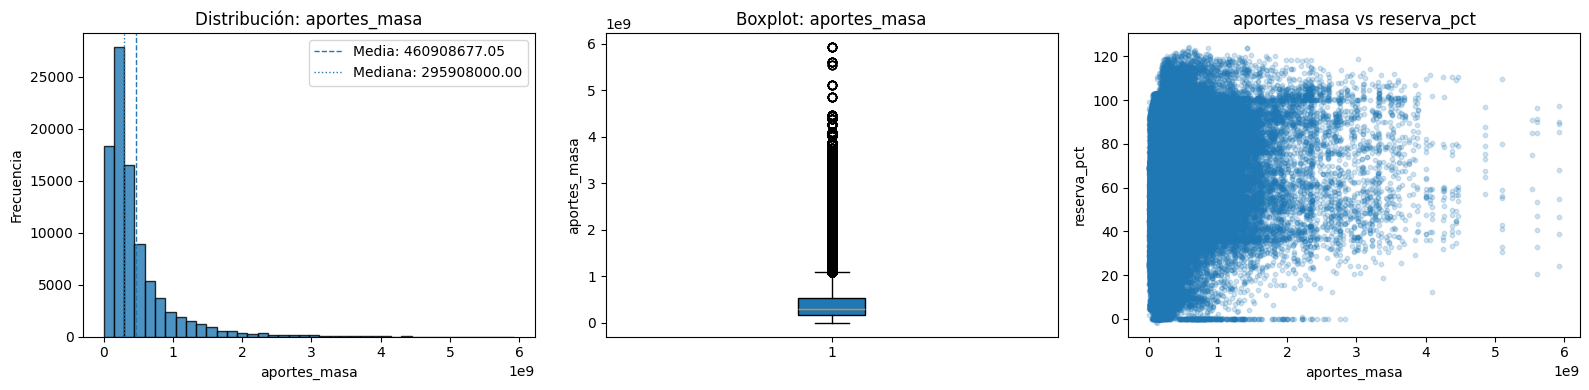

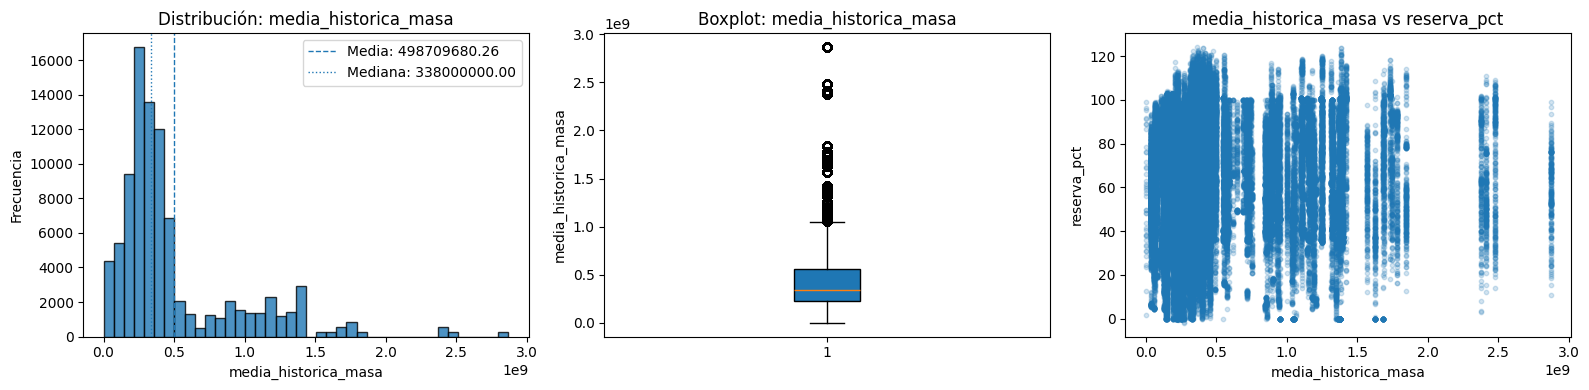

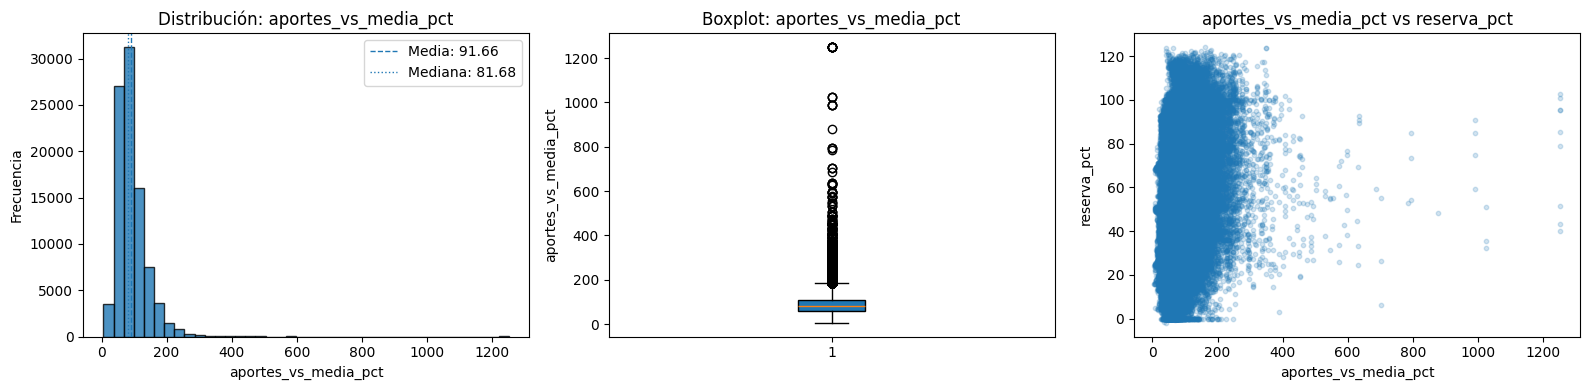

In [18]:
plot_numeric_audit(
    embalses,
    columns=[
        col for col in [
            "aportes_masa",
            "media_historica_masa",
            "aportes_vs_media_pct"
        ] if col in embalses.columns
    ],
    target="reserva_pct",
)


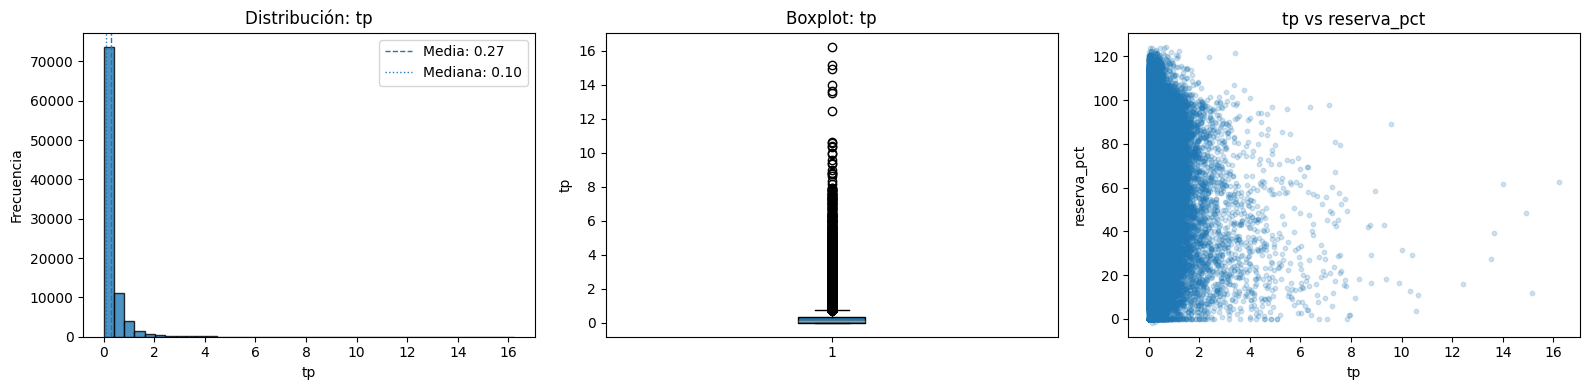

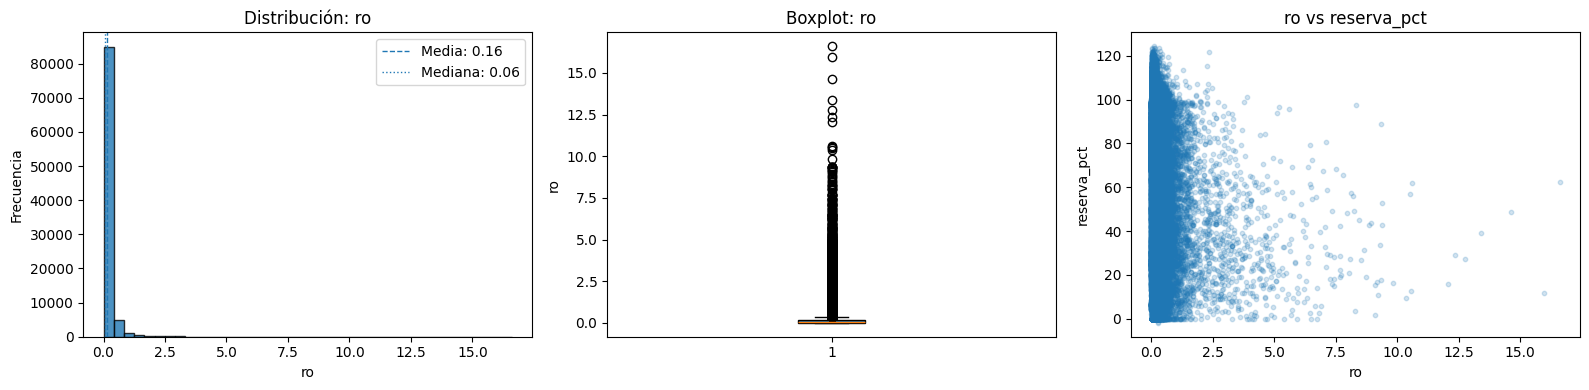

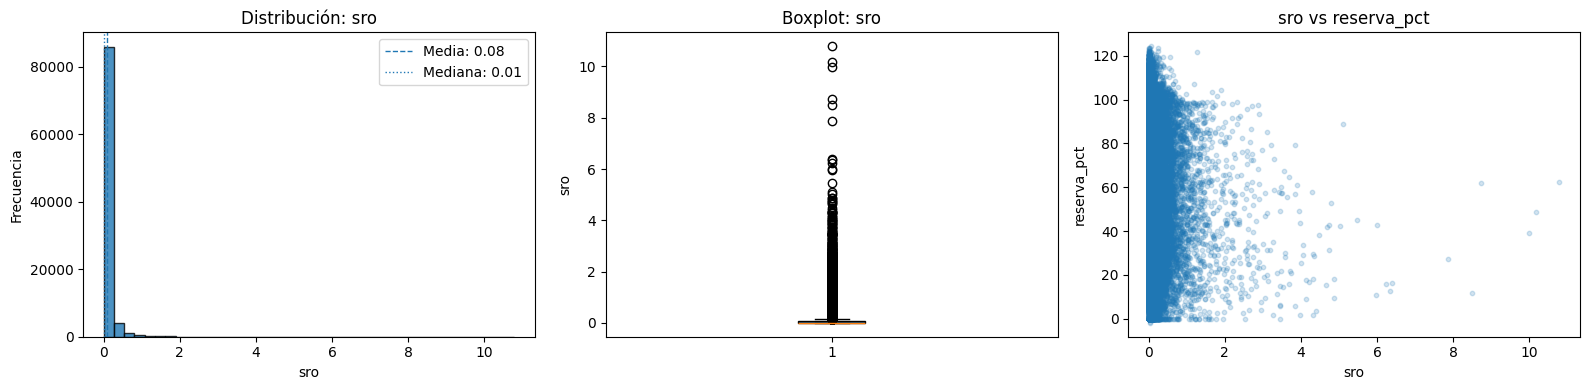

In [19]:
plot_numeric_audit(
    embalses,
    columns=[
        col for col in [
            "tp",
            "ro",
            "sro"
        ] if col in embalses.columns
    ],
    target="reserva_pct",
)


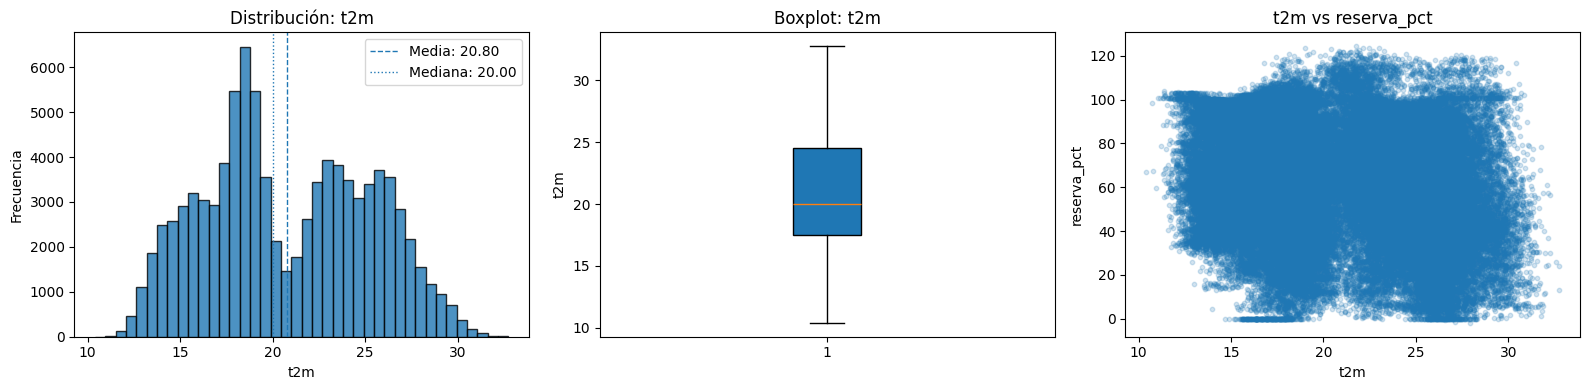

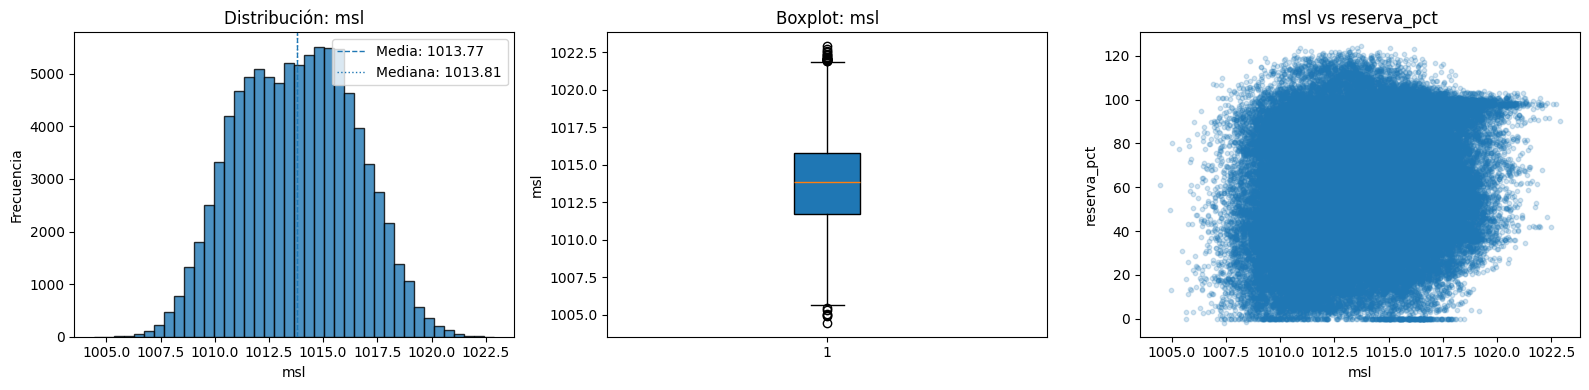

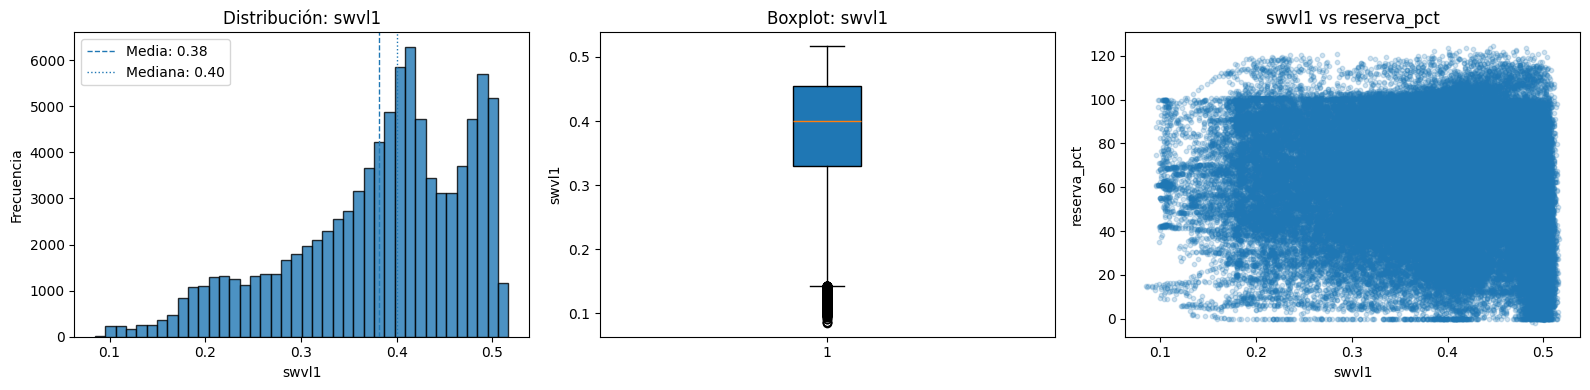

In [20]:
plot_numeric_audit(
    embalses,
    columns=[
        col for col in [
            "t2m",
            "msl",
            "swvl1"
        ] if col in embalses.columns
    ],
    target="reserva_pct",
)


In [21]:
plot_numeric_audit(
    embalses,
    columns=[
        col for col in [
            "sst_nino"
        ] if col in embalses.columns
    ],
    target="reserva_pct",
)


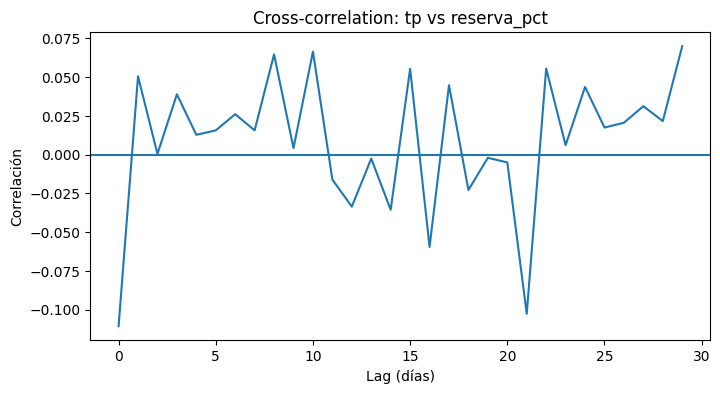

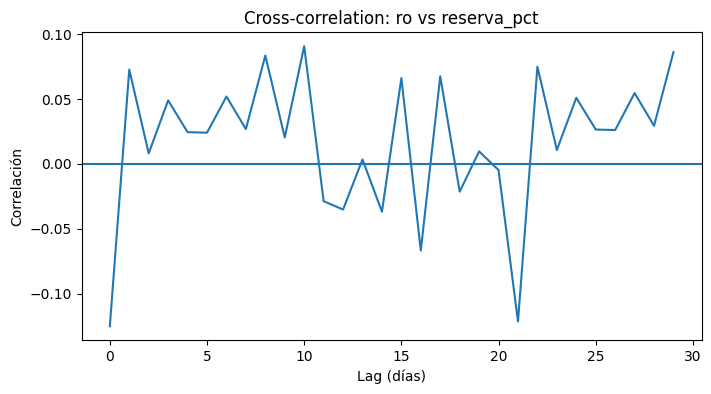

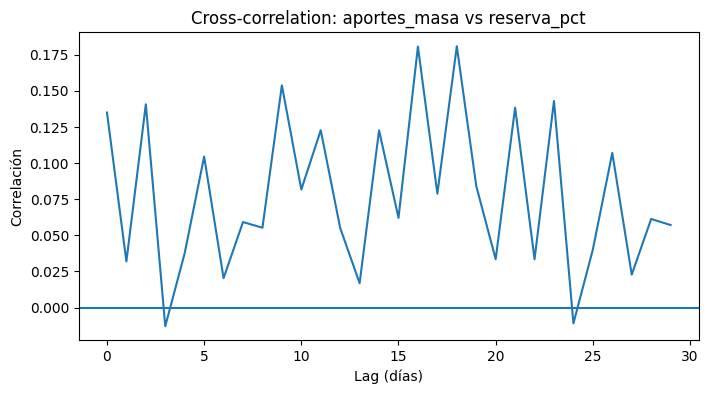

In [22]:
plot_cross_corr(embalses, "tp", "reserva_pct")
plot_cross_corr(embalses, "ro", "reserva_pct")
plot_cross_corr(embalses, "aportes_masa", "reserva_pct")


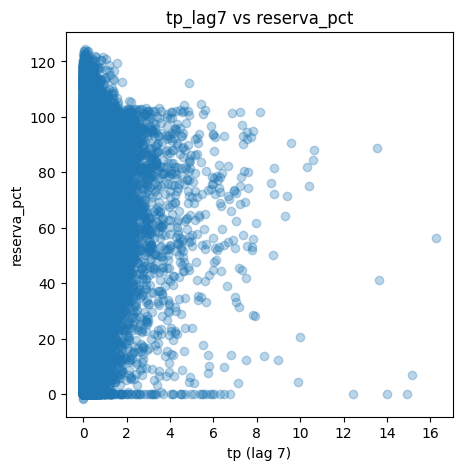

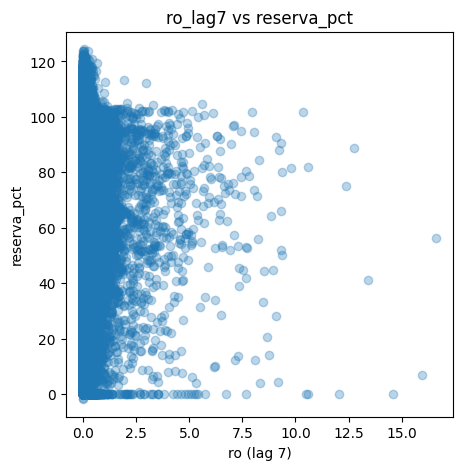

In [23]:
plot_lag_scatter(embalses, "tp", "reserva_pct", lag=7)
plot_lag_scatter(embalses, "ro", "reserva_pct", lag=7)


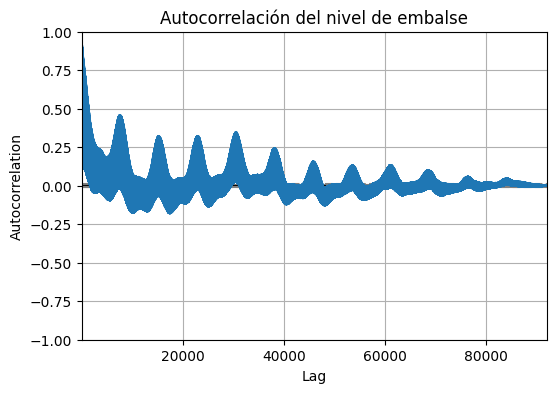

In [24]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(6,4))
autocorrelation_plot(embalses["reserva_pct"])
plt.title("Autocorrelación del nivel de embalse")
plt.show()


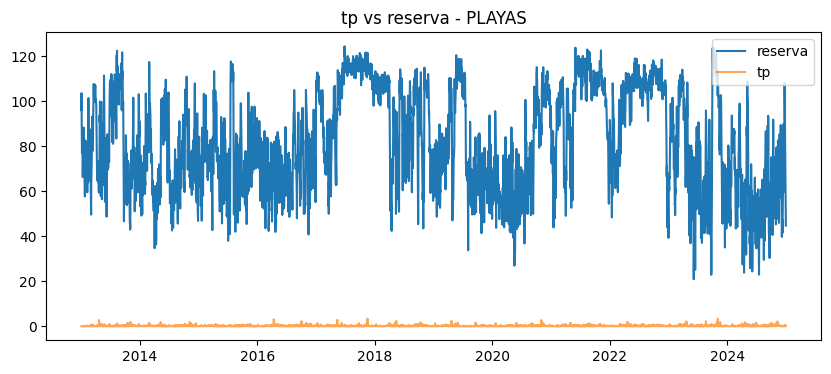

In [25]:
plot_time_series(embalses, "tp", "PLAYAS")


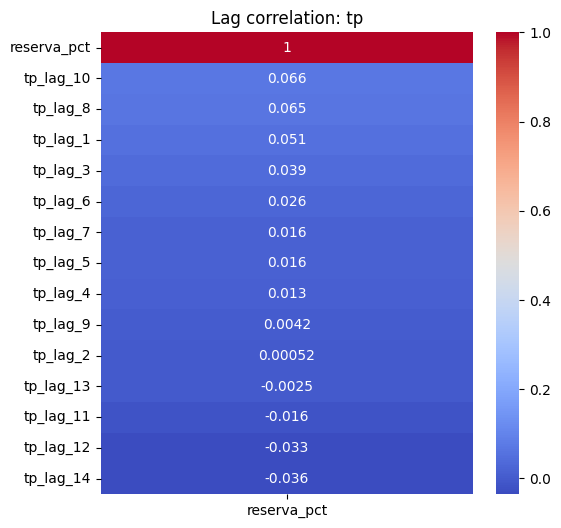

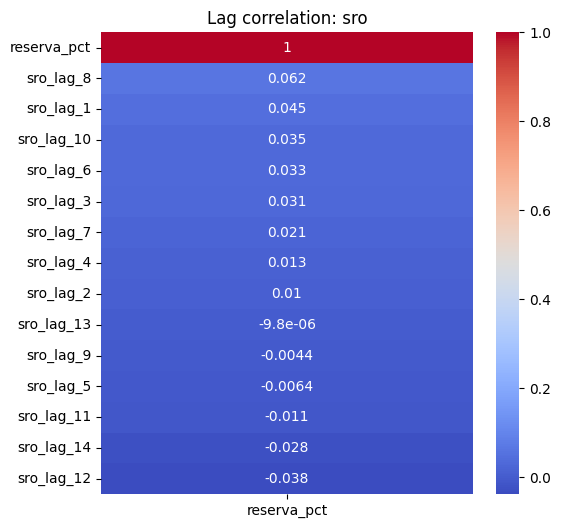

In [26]:
lag_corr_matrix(embalses, "tp", "reserva_pct")
lag_corr_matrix(embalses, "sro", "reserva_pct")


In [27]:
quick_interpretation(embalses, target=TARGET, numeric_cols=numeric_cols)



                                 LECTURA RÁPIDA DEL EDA                                 
- Filas: 92,043
- Columnas: 18
- Target: reserva_pct
- Variables numéricas: 14
- Variables categóricas: 3
- Valores faltantes totales: 42
- Filas duplicadas exactas: 0


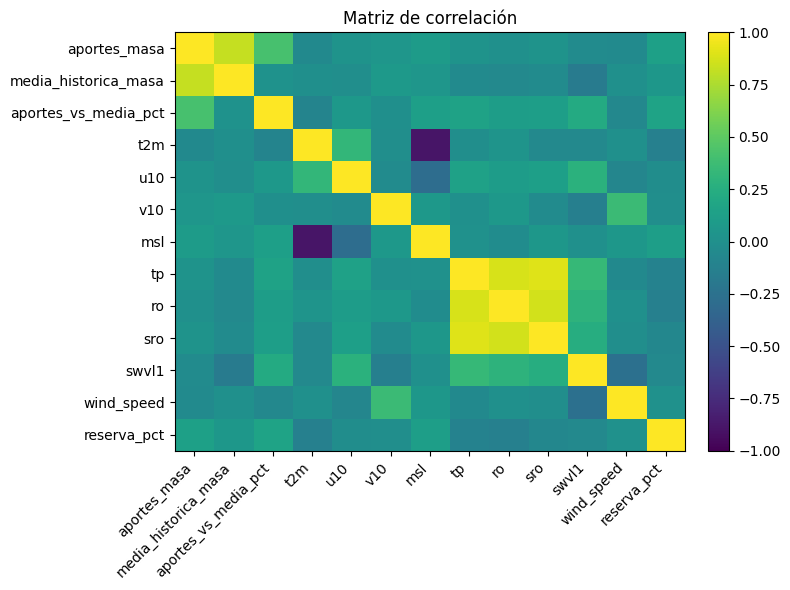

In [28]:
# Variables numéricas a analizar
selected_numeric_for_audit = [
    "aportes_masa",
    "media_historica_masa",
    "aportes_vs_media_pct",
    "t2m",
    "u10",
    "v10",
    "msl",
    "sst_nino",
    "tp",
    "ro",
    "sro",
    "swvl1",
    "wind_speed",
    "reserva_pct"
]
 
# Filtrar solo columnas existentes
selected_numeric_for_audit = [
    col for col in selected_numeric_for_audit
    if col in embalses.columns
]
 
# Invocar función
plot_correlation_heatmap(
    embalses,
    selected_numeric_for_audit
)


In [29]:
target_corr = (
    embalses[selected_numeric_for_audit]
    .corr(numeric_only=True)[TARGET]
    .sort_values(ascending=False)
    .drop(TARGET)
    .to_frame(name="corr_with_target")
)

print_section("CORRELACIÓN CON EL TARGET")
display(target_corr)



                               CORRELACIÓN CON EL TARGET                                


,corr_with_target
aportes_vs_media_pct,0.162550
aportes_masa,0.134950
msl,0.120296
media_historica_masa,0.061888
wind_speed,0.013968
v10,-0.014424
u10,-0.020599
swvl1,-0.059871
sro,-0.077481
tp,-0.110561


## Outliers


In [30]:
# =========================================================
# FILTRADO DE OUTLIERS FÍSICAMENTE IMPOSIBLES
# =========================================================

print("=" * 60)
print("ANTES DEL FILTRADO")
print("=" * 60)

print(f"Cantidad de registros: {len(embalses):,}")

# =========================================================
# CONDICIONES FÍSICAS VÁLIDAS
# =========================================================

valid_mask = (
    # precipitación no negativa
    (embalses["tp"] >= 0)

    # humedad del suelo no negativa
    & (embalses["swvl1"] >= 0)

    # presión atmosférica razonable
    & (embalses["msl"] >= 850)
    & (embalses["msl"] <= 1100)

    # velocidad del viento no negativa
    & (embalses["wind_speed"] >= 0)

    # porcentaje de reserva razonable
    & (embalses["reserva_pct"] >= 0)
    & (embalses["reserva_pct"] <= 120)
)

# =========================================================
# FILTRAR DATASET
# =========================================================

df_filtered = embalses[valid_mask].copy()

# =========================================================
# RESULTADOS
# =========================================================

print("\n" + "=" * 60)
print("DESPUÉS DEL FILTRADO")
print("=" * 60)

print(f"Cantidad de registros: {len(df_filtered):,}")

removed = len(embalses) - len(df_filtered)

print(f"\nRegistros eliminados: {removed:,}")


ANTES DEL FILTRADO
Cantidad de registros: 92,043

DESPUÉS DEL FILTRADO
Cantidad de registros: 91,992

Registros eliminados: 51


## Split


In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    make_scorer,
)


In [32]:
SEED = 72


In [33]:
#embalses = embalses.drop(columns=["aportes_vs_media_pct"])

In [207]:
embalses = embalses.sort_values("Fecha")
base_feature_cols = [col for col in embalses.columns if col != TARGET]

X_full = embalses[base_feature_cols].copy()
y_full = embalses[TARGET].copy()

#split_idx = int(len(X_full) * 0.8)

#X_train_raw = X_full.iloc[:split_idx]
#X_test_raw  = X_full.iloc[split_idx:]

#y_train = y_full.iloc[:split_idx]
#y_test  = y_full.iloc[split_idx:]

embalses = embalses.sort_values("Fecha")

fecha_max   = embalses["Fecha"].max()
fecha_corte = fecha_max - pd.DateOffset(months=5)

train_df = embalses[embalses["Fecha"] <= fecha_corte].copy()
test_df  = embalses[embalses["Fecha"] >  fecha_corte].copy()

base_feature_cols = [col for col in embalses.columns if col != TARGET]

X_train_raw = train_df[base_feature_cols]
X_test_raw  = test_df[base_feature_cols]
y_train     = train_df[TARGET]
y_test      = test_df[TARGET]

print(f"Corte:  {fecha_corte.date()}")
print(f"Train:  {train_df['Fecha'].min().date()} → {train_df['Fecha'].max().date()}")
print(f"Test:   {test_df['Fecha'].min().date()}  → {test_df['Fecha'].max().date()}")
print(f"Train shape: {X_train_raw.shape}")
print(f"Test shape:  {X_test_raw.shape}")


print_section("PARTICIÓN DE DATOS")
print(f"Train shape: {X_train_raw.shape}")
print(f"Test shape:  {X_test_raw.shape}")
print(f"Target mean (train): {y_train.mean():,.3f}")
print(f"Target mean (test):  {y_test.mean():,.3f}")

Corte:  2024-07-31
Train:  2013-01-01 → 2024-07-31
Test:   2024-08-01  → 2024-12-31
Train shape: (88830, 17)
Test shape:  (3213, 17)

                                   PARTICIÓN DE DATOS                                   
Train shape: (88830, 17)
Test shape:  (3213, 17)
Target mean (train): 62.523
Target mean (test):  57.050


## Feature engineering


In [208]:


# =========================================================
# ORDEN TEMPORAL
# =========================================================

X_train_raw = X_train_raw.sort_values(
    ["CodigoEmbalse", "Fecha"]
).copy()

X_test_raw = X_test_raw.sort_values(
    ["CodigoEmbalse", "Fecha"]
).copy()

# =========================================================
# HELPERS
# =========================================================

def rolling_mean(series, window):
    return (
        series
        .shift(1)
        .rolling(window, min_periods=1)
        .mean()
    )

def rolling_std(series, window):
    return (
        series
        .shift(1)
        .rolling(window, min_periods=2)
        .std()
    )

# =========================================================
# FEATURE ENGINEERING
# =========================================================

def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # =========================================================
    # 1. FEATURES TEMPORALES Y CÍCLICAS
    # =========================================================
    out["month"]     = out["Fecha"].dt.month
    out["dayofyear"] = out["Fecha"].dt.dayofyear
    out["week"]      = out["Fecha"].dt.isocalendar().week.astype(int)

    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    out["day_sin"]   = np.sin(2 * np.pi * out["dayofyear"] / 365)
    out["day_cos"]   = np.cos(2 * np.pi * out["dayofyear"] / 365)

    # Estaciones hidrológicas Colombia (dos ciclos al año)
    out["temporada_lluvia"] = out["month"].isin([3, 4, 5, 9, 10, 11]).astype(int)
    out["temporada_seca"]   = out["month"].isin([12, 1, 2, 6, 7, 8]).astype(int)

    # =========================================================
    # 2. LAGS DE VARIABLES METEOROLÓGICAS E HIDROLÓGICAS
    #    Extendidos a 30 días — la lluvia tarda semanas en
    #    llegar al embalse vía escorrentía subterránea
    # =========================================================
    lag_cols = ["aportes_masa", "tp", "ro", "swvl1", "oni_anom"]

    for col in lag_cols:
        for lag in [1, 2, 3, 7, 14, 30]:
            out[f"{col}_lag{lag}"] = (
                out.groupby("CodigoEmbalse")[col]
                .shift(lag)
            )

    # =========================================================
    # 3. ROLLING MEANS — ventanas largas para hidrología
    # =========================================================
    rolling_cols = ["tp", "ro", "swvl1", "aportes_masa"]

    for col in rolling_cols:
        for window in [7, 14, 30, 60, 90]:
            out[f"{col}_ma{window}"] = (
                out.groupby("CodigoEmbalse")[col]
                .transform(
                    lambda x: x.shift(1).rolling(window, min_periods=1).mean()
                )
            )

    # =========================================================
    # 4. ROLLING STD — variabilidad reciente
    # =========================================================
    for col in ["tp", "ro", "aportes_masa"]:
        for window in [7, 30]:
            out[f"{col}_std{window}"] = (
                out.groupby("CodigoEmbalse")[col]
                .transform(
                    lambda x: x.shift(1).rolling(window, min_periods=2).std()
                )
            )

    # =========================================================
    # 5. ACUMULADOS DE LLUVIA
    #    60 y 90 días para embalses grandes de respuesta lenta
    # =========================================================
    for window in [7, 14, 30, 60, 90]:
        out[f"tp_acc_{window}"] = (
            out.groupby("CodigoEmbalse")["tp"]
            .transform(
                lambda x: x.shift(1).rolling(window, min_periods=1).sum()
            )
        )

    # =========================================================
    # 6. ANOMALÍAS METEOROLÓGICAS
    #    Diferencia entre el valor reciente y la media histórica
    # =========================================================
    out["tp_anomaly"] = out["tp_lag1"] - out["tp_ma7"]
    out["ro_anomaly"] = out["ro_lag1"] - out["ro_ma7"]

    # =========================================================
    # 7. FEATURES HIDROLÓGICAS
    # =========================================================
    out["deficit_aportes"]   = out["media_historica_masa"] - out["aportes_masa"]
    out["deficit_pct"]       = (
        out["deficit_aportes"]
        / out["media_historica_masa"].replace(0, np.nan)
    ) * 100

    out["ro_subsuperficial"] = out["ro"] - out["sro"]
    out["fraccion_sro"]      = out["sro"] / (out["ro"] + 1e-6)

    # =========================================================
    # 8. INTERACCIONES CLAVE
    # =========================================================
    out["rain_x_soil"]    = out["tp"] * out["swvl1"]
    out["rain_x_deficit"] = out["tp_lag1"] * out["deficit_pct"]
    out["soil_x_ro"]      = out["swvl1"] * out["ro"]

    # =========================================================
    # 9. ENSO
    # =========================================================
    out["el_nino"]       = (out["oni_anom"] >  0.5).astype(int)
    out["la_nina"]       = (out["oni_anom"] < -0.5).astype(int)
    out["enso_intensity"] = out["oni_anom"].clip(-3, 3)

    # =========================================================
    # 10. VIENTO
    # =========================================================
    out["wind_dir"]   = np.arctan2(out["v10"], out["u10"]) * (180 / np.pi)
    out["wind_speed"] = np.sqrt(out["u10"]**2 + out["v10"]**2)

    # =========================================================
    # LIMPIEZA
    # =========================================================
    out = out.replace([np.inf, -np.inf], np.nan)

    return out

# =========================================================
# APLICAR FEATURE ENGINEERING
# =========================================================

#X_train = add_engineered_features(X_train_raw)
#X_test = add_engineered_features(X_test_raw)
embalses_fe = add_engineered_features(
    embalses[base_feature_cols + [TARGET]]  # necesita todas las cols
)
embalses_fe = embalses_fe.replace([np.inf, -np.inf], np.nan).dropna()

fecha_corte = embalses_fe["Fecha"].max() - pd.DateOffset(months=2)

train_fe = embalses_fe[embalses_fe["Fecha"] <= fecha_corte]
test_fe  = embalses_fe[embalses_fe["Fecha"] >  fecha_corte]

feature_cols = [col for col in embalses_fe.columns if col != TARGET]

X_train, y_train = train_fe[feature_cols], train_fe[TARGET]
X_test,  y_test  = test_fe[feature_cols],  test_fe[TARGET]


# =========================================================
# LIMPIAR NaNs
# =========================================================

train_mask = X_train.notnull().all(axis=1)

X_train = X_train[train_mask]
y_train = y_train.loc[X_train.index]

test_mask = X_test.notnull().all(axis=1)

X_test = X_test[test_mask]
y_test = y_test.loc[X_test.index]

# =========================================================
# INFO
# =========================================================

print("=" * 80)
print("FEATURE ENGINEERING REDUCIDO")
print("=" * 80)

print(
    f"Número de columnas finales: "
    f"{X_train.shape[1]}"
)

print("\nColumnas finales:")
print(list(X_train.columns))

print("\nShape train:")
print(X_train.shape)

print("\nShape test:")
print(X_test.shape)

print("\nNaNs restantes:")
print(X_train.isnull().sum().sum())

FEATURE ENGINEERING REDUCIDO
Número de columnas finales: 100

Columnas finales:
['Fecha', 'CodigoEmbalse', 'RegionHidrologica', 'aportes_masa', 'media_historica_masa', 'aportes_vs_media_pct', 't2m', 'u10', 'v10', 'msl', 'sst_nino12_proxy', 'oni_anom', 'tp', 'ro', 'sro', 'swvl1', 'wind_speed', 'month', 'dayofyear', 'week', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'temporada_lluvia', 'temporada_seca', 'aportes_masa_lag1', 'aportes_masa_lag2', 'aportes_masa_lag3', 'aportes_masa_lag7', 'aportes_masa_lag14', 'aportes_masa_lag30', 'tp_lag1', 'tp_lag2', 'tp_lag3', 'tp_lag7', 'tp_lag14', 'tp_lag30', 'ro_lag1', 'ro_lag2', 'ro_lag3', 'ro_lag7', 'ro_lag14', 'ro_lag30', 'swvl1_lag1', 'swvl1_lag2', 'swvl1_lag3', 'swvl1_lag7', 'swvl1_lag14', 'swvl1_lag30', 'oni_anom_lag1', 'oni_anom_lag2', 'oni_anom_lag3', 'oni_anom_lag7', 'oni_anom_lag14', 'oni_anom_lag30', 'tp_ma7', 'tp_ma14', 'tp_ma30', 'tp_ma60', 'tp_ma90', 'ro_ma7', 'ro_ma14', 'ro_ma30', 'ro_ma60', 'ro_ma90', 'swvl1_ma7', 'swvl1_ma14', '

In [209]:
print(y_train.describe())
print(y_test.describe())

count    90090.000000
mean        62.396853
std         25.241614
min         -1.850000
25%         43.990000
50%         63.470000
75%         82.700000
max        124.390000
Name: reserva_pct, dtype: float64
count    1281.000000
mean       61.237861
std        27.172487
min         0.000000
25%        40.390000
50%        64.710000
75%        85.230000
max       112.080000
Name: reserva_pct, dtype: float64


In [210]:
print(y_train.mean())
print(y_test.mean())

62.39685325785326
61.237861046057766


In [211]:
print(y_train.std())
print(y_test.std())

print(X_train_raw.shape)
print(X_test_raw.shape)

print(X_train_raw.isna().sum().sort_values(ascending=False).head(20))

25.241614298923356
27.172487385843088
(88830, 17)
(3213, 17)
aportes_vs_media_pct    42
Fecha                    0
CodigoEmbalse            0
aportes_masa             0
RegionHidrologica        0
media_historica_masa     0
t2m                      0
u10                      0
v10                      0
msl                      0
sst_nino12_proxy         0
oni_anom                 0
tp                       0
ro                       0
sro                      0
swvl1                    0
wind_speed               0
dtype: int64


In [212]:
temporal_cols = ["Fecha"]
binary_cols = ["CodigoEmbalse"]
onehot_cols = ["RegionHidrologica"]
numeric_cols_chunk2 = X_train.select_dtypes(include=[np.number]).columns.tolist()

print_section("MAPA SEMÁNTICO DE VARIABLES")
print(f"Numéricas ({len(numeric_cols_chunk2)}): {numeric_cols_chunk2}")
print(f"Binarias ({len(binary_cols)}): {binary_cols}")
print(f"OneHot ({len(onehot_cols)}): {onehot_cols}")
print(f"Temporales ({len(temporal_cols)}): {temporal_cols}")



                              MAPA SEMÁNTICO DE VARIABLES                               
Numéricas (97): ['aportes_masa', 'media_historica_masa', 'aportes_vs_media_pct', 't2m', 'u10', 'v10', 'msl', 'sst_nino12_proxy', 'oni_anom', 'tp', 'ro', 'sro', 'swvl1', 'wind_speed', 'month', 'dayofyear', 'week', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'temporada_lluvia', 'temporada_seca', 'aportes_masa_lag1', 'aportes_masa_lag2', 'aportes_masa_lag3', 'aportes_masa_lag7', 'aportes_masa_lag14', 'aportes_masa_lag30', 'tp_lag1', 'tp_lag2', 'tp_lag3', 'tp_lag7', 'tp_lag14', 'tp_lag30', 'ro_lag1', 'ro_lag2', 'ro_lag3', 'ro_lag7', 'ro_lag14', 'ro_lag30', 'swvl1_lag1', 'swvl1_lag2', 'swvl1_lag3', 'swvl1_lag7', 'swvl1_lag14', 'swvl1_lag30', 'oni_anom_lag1', 'oni_anom_lag2', 'oni_anom_lag3', 'oni_anom_lag7', 'oni_anom_lag14', 'oni_anom_lag30', 'tp_ma7', 'tp_ma14', 'tp_ma30', 'tp_ma60', 'tp_ma90', 'ro_ma7', 'ro_ma14', 'ro_ma30', 'ro_ma60', 'ro_ma90', 'swvl1_ma7', 'swvl1_ma14', 'swvl1_ma30', 'swvl1_m

In [213]:
from category_encoders import BinaryEncoder

class BinaryEncoderWrapper(BinaryEncoder):
    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_in_)


In [214]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd

class TemporalEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        X = np.asarray(X)
        result = []

        for col in range(X.shape[1]):
            dates = pd.to_datetime(X[:, col])

            mes = dates.month
            dia_año = dates.dayofyear

            features = np.column_stack([
                np.sin(2 * np.pi * mes / 12),
                np.cos(2 * np.pi * mes / 12),
                np.sin(2 * np.pi * dia_año / 365),
                np.cos(2 * np.pi * dia_año / 365)
            ])

            result.append(features)

        return np.hstack(result)

    def get_feature_names_out(self, input_features):
        names = []
        for col in input_features:
            names.extend([
                f"{col}_mes_sin",
                f"{col}_mes_cos",
                f"{col}_dia_sin",
                f"{col}_dia_cos",
            ])
        return np.array(names)


In [215]:
def build_preprocessor(
    numeric_cols: list[str],
    binary_cols: list[str],
    onehot_cols: list[str],
    temporal_cols: list[str],
    numeric_imputer_strategy: str = "median",
    scale_numeric: bool = True,
) -> ColumnTransformer:
    """Build a safe mixed-type preprocessor."""
    num_steps = [
        ("imputer", SimpleImputer(strategy=numeric_imputer_strategy)),
    ]

    if scale_numeric:
        num_steps.append(("scaler", RobustScaler()))

    numeric_pipe = Pipeline(num_steps)

    transformers = [
        ("num", numeric_pipe, numeric_cols),
    ]

    if onehot_cols:
        onehot_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ])
        transformers.append(("nom", onehot_pipe, onehot_cols))

    if binary_cols:
        binary_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", BinaryEncoder()),
        ])
        transformers.append(("binary", binary_pipe, binary_cols))

    if temporal_cols:
        temporal_pipe = Pipeline([
            ("encoder", TemporalEncoder()),
        ])
        transformers.append(("temp", temporal_pipe, temporal_cols))

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
    )
    return preprocessor


In [216]:
preview_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols_chunk2,
    binary_cols=binary_cols,
    onehot_cols=onehot_cols,
    temporal_cols=temporal_cols,
    numeric_imputer_strategy="median",
    scale_numeric=True,
)

X_train_t = preview_preprocessor.fit_transform(X_train)
X_test_t = preview_preprocessor.transform(X_test)

print_section("PREVIEW DEL PREPROCESSOR")
print(f"Shape train transformado: {X_train_t.shape}")
print(f"Shape test transformado:  {X_test_t.shape}")

feature_names = preview_preprocessor.get_feature_names_out()
preview_df = pd.DataFrame(X_train_t[:5], columns=feature_names)
display(preview_df)



                                PREVIEW DEL PREPROCESSOR                                
Shape train transformado: (90090, 112)
Shape test transformado:  (1281, 112)


,num__aportes_masa,num__media_historica_masa,num__aportes_vs_media_pct,num__t2m,num__u10,num__v10,num__msl,num__sst_nino12_proxy,num__oni_anom,num__tp,...,nom__RegionHidrologica_Valle,binary__0_0,binary__0_1,binary__0_2,binary__0_3,binary__0_4,temp__Fecha_mes_sin,temp__Fecha_mes_cos,temp__Fecha_dia_sin,temp__Fecha_dia_cos
0,-0.461518,-0.001433,-0.882603,-0.654788,0.215885,-0.261983,0.412080,0.595039,-0.26087,-0.169924,...,0.0,0.0,0.0,0.0,0.0,1.0,0.5,0.866025,0.508671,0.860961
1,-0.484070,-0.264915,-0.682929,0.865246,-0.230852,1.095853,-1.174887,0.595039,-0.26087,0.936578,...,1.0,0.0,0.0,0.0,1.0,0.0,0.5,0.866025,0.508671,0.860961
2,-0.461518,-0.001433,-0.882603,0.544275,1.342887,1.935099,-0.846742,0.595039,-0.26087,-0.326685,...,0.0,0.0,0.0,0.0,1.0,1.0,0.5,0.866025,0.508671,0.860961
3,-0.484070,-0.264915,-0.682929,-0.108452,1.653915,-1.219990,-0.171003,0.595039,-0.26087,2.048265,...,1.0,0.0,0.0,1.0,0.0,0.0,0.5,0.866025,0.508671,0.860961
4,-0.764541,-0.917020,-0.601155,-0.672969,-1.293444,1.347231,0.352412,0.595039,-0.26087,-0.300359,...,0.0,0.0,0.0,1.0,0.0,1.0,0.5,0.866025,0.508671,0.860961


In [217]:
def regression_report(y_true: pd.Series, y_pred: np.ndarray) -> dict:
    """Return a compact regression metrics dictionary."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
    }


def evaluate_pipeline(
    estimator,
    X_train_data: pd.DataFrame,
    X_test_data: pd.DataFrame,
    y_train_data: pd.Series,
    y_test_data: pd.Series,
    tag: str,
) -> dict:
    """Fit estimator and return metrics."""
    estimator.fit(X_train_data, y_train_data)
    preds = estimator.predict(X_test_data)
    report = regression_report(y_test_data, preds)
    report["experiment"] = tag
    return report


### Validación Cruzada

In [218]:
# =========================================================
# VALIDACIÓN CRUZADA TEMPORAL
# =========================================================

tscv = TimeSeriesSplit(n_splits=5)

# =========================================================
# MÉTRICAS
# =========================================================

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}

# =========================================================
# EVALUACIÓN CON VALIDACIÓN CRUZADA
# =========================================================

def evaluate_cv(estimator, X_data, y_data, tag="Model"):
    
    cv_results = cross_validate(
        estimator=estimator,
        X=X_data,
        y=y_data,
        cv=tscv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    metrics = {
        "experiment": tag,
        "cv_rmse_mean": -cv_results["test_rmse"].mean(),
        "cv_rmse_std": cv_results["test_rmse"].std(),
        "cv_mae_mean": -cv_results["test_mae"].mean(),
        "cv_r2_mean": cv_results["test_r2"].mean(),
    }

    return metrics

### Entrenamiento de modelos

Comparación entre un baseline simple y un modelo XGBoost para predecir `reserva_pct`.


In [219]:
results = []

from sklearn.tree import DecisionTreeRegressor

baseline_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols_chunk2,
    binary_cols=binary_cols,
    onehot_cols=onehot_cols,
    temporal_cols=temporal_cols,
    numeric_imputer_strategy="median",
    scale_numeric=True,
)

baseline_model = Pipeline([
    ("preprocess", baseline_preprocessor),
    ("regressor", DecisionTreeRegressor(max_depth=8, random_state=SEED)),
])

baseline_result = evaluate_pipeline(
    estimator=baseline_model,
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test,
    tag="Baseline Decision Tree",
)
results.append(baseline_result)

model_results_df = pd.DataFrame(results).sort_values("rmse")
print_section("RESULTADOS — BASELINE")
display(model_results_df)



                                 RESULTADOS — BASELINE                                  


,rmse,mae,r2,experiment
0,25.19029,19.122656,0.139904,Baseline Decision Tree


### Entrenamiento con XGBoost

Modelo principal de boosting para predecir `reserva_pct` usando las variables climáticas, hídricas, temporales y categóricas ya preparadas.


In [220]:
try:
    from xgboost import XGBRegressor
except ImportError as exc:
    raise ImportError(
        "XGBoost no está instalado en este entorno. Instálalo con: pip install xgboost"
    ) from exc

# XGBoost no requiere escalar variables numéricas; se conserva imputación y encoding categórico/temporal.
xgb_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols_chunk2,
    binary_cols=binary_cols,
    onehot_cols=onehot_cols,
    temporal_cols=temporal_cols,
    numeric_imputer_strategy="median",
    scale_numeric=False,
)

xgb_model = Pipeline([
    ("preprocess", xgb_preprocessor),
    (
        "regressor",
        XGBRegressor(
            objective="reg:squarederror",
            eval_metric="rmse",
            n_estimators=700,
            learning_rate=0.03,
            max_depth=5,
            min_child_weight=3,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.05,
            reg_lambda=1.0,
            tree_method="hist",
            max_bin=256,
            n_jobs=2,
            random_state=SEED,
        ),
    ),
])

try:
    results
except NameError:
    results = []

xgb_cv_result = evaluate_cv(
    estimator=xgb_model,
    X_data=X_train,
    y_data=y_train,
    tag="XGBoost CV",
)

pd.DataFrame([xgb_cv_result])

# Evita duplicar el resultado si la celda se reejecuta.
results = [row for row in results if row.get("experiment") != "XGBoost"]

xgb_result = evaluate_pipeline(
    estimator=xgb_model,
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test,
    tag="XGBoost",
)
results.append(xgb_result)

model_results_df = pd.DataFrame(results).sort_values("rmse")
print_section("RESULTADOS — MODELOS")
display(model_results_df)



                                  RESULTADOS — MODELOS                                  


,rmse,mae,r2,experiment
1,21.970641,16.204263,0.345717,XGBoost
0,25.190290,19.122656,0.139904,Baseline Decision Tree


In [221]:
xgb_pred = xgb_model.predict(X_test)

predicciones_xgb = X_test[["Fecha", "CodigoEmbalse", "RegionHidrologica"]].copy()
predicciones_xgb["reserva_pct_real"] = y_test.values
predicciones_xgb["reserva_pct_pred"] = xgb_pred
predicciones_xgb["error_abs"] = (
    predicciones_xgb["reserva_pct_real"] - predicciones_xgb["reserva_pct_pred"]
).abs()

print_section("PREDICCIONES XGBOOST — MUESTRA")
display(predicciones_xgb.sort_values("Fecha").head(20))

feature_names = xgb_model.named_steps["preprocess"].get_feature_names_out()
importances = xgb_model.named_steps["regressor"].feature_importances_

importancia_xgb = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(25)
)

print_section("IMPORTANCIA DE VARIABLES — XGBOOST")
display(importancia_xgb)



                             PREDICCIONES XGBOOST — MUESTRA                             


,Fecha,CodigoEmbalse,RegionHidrologica,reserva_pct_real,reserva_pct_pred,error_abs
98374,2024-11-01,AGREGADO_BOGOTA,Centro,51.62,47.300858,4.319142
98392,2024-11-01,RIOGRAN2,Antioquia,74.16,61.669994,12.490006
98396,2024-11-01,TRONERAS,Antioquia,30.52,46.648315,16.128315
98394,2024-11-01,SANLOREN,Antioquia,89.35,74.692596,14.657404
98393,2024-11-01,SALVAJIN,Valle,14.73,15.926268,1.196268
98386,2024-11-01,PENOL,Antioquia,58.21,59.381599,1.171599
98390,2024-11-01,PRADO,Centro,10.15,33.989594,23.839594
98389,2024-11-01,PORCE3,Antioquia,75.51,51.416058,24.093942
98388,2024-11-01,PORCE2,Antioquia,63.77,56.040310,7.729690
98387,2024-11-01,PLAYAS,Antioquia,67.83,64.949867,2.880133



                           IMPORTANCIA DE VARIABLES — XGBOOST                           


,feature,importance
101,nom__RegionHidrologica_Oriente,0.056260
102,nom__RegionHidrologica_Valle,0.048376
18,num__month_cos,0.038985
110,temp__Fecha_dia_sin,0.037955
86,num__deficit_aportes,0.035108
19,num__day_sin,0.034791
99,nom__RegionHidrologica_Caribe,0.030036
72,num__aportes_masa_ma90,0.027628
106,binary__0_3,0.026550
98,nom__RegionHidrologica_Caldas,0.026179


### Entrenamiento con Random Forest

Modelo ensemble adicional para comparar contra XGBoost usando la misma partición temporal y el mismo preprocesamiento.


In [222]:
# Random Forest tampoco requiere escalado; se conserva imputación y encoding categórico/temporal.
rf_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols_chunk2,
    binary_cols=binary_cols,
    onehot_cols=onehot_cols,
    temporal_cols=temporal_cols,
    numeric_imputer_strategy="median",
    scale_numeric=False,
)

rf_model = Pipeline([
    ("preprocess", rf_preprocessor),
    (
        "regressor",
        RandomForestRegressor(
            n_estimators=300,
            max_depth=18,
            min_samples_split=10,
            min_samples_leaf=4,
            max_features="sqrt",
            bootstrap=True,
            n_jobs=2,
            random_state=SEED,
        ),
    ),
])

try:
    results
except NameError:
    results = []

rf_cv_result = evaluate_cv(
    estimator=rf_model,
    X_data=X_train,
    y_data=y_train,
    tag="Random Forest CV",
)

pd.DataFrame([rf_cv_result])

# Evita duplicar el resultado si la celda se reejecuta.
results = [row for row in results if row.get("experiment") != "Random Forest"]

rf_result = evaluate_pipeline(
    estimator=rf_model,
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test,
    tag="Random Forest",
)
results.append(rf_result)

model_results_df = pd.DataFrame(results).sort_values("rmse")
print_section("RESULTADOS — MODELOS")
display(model_results_df)



                                  RESULTADOS — MODELOS                                  


,rmse,mae,r2,experiment
1,21.970641,16.204263,0.345717,XGBoost
2,22.089761,17.281777,0.338603,Random Forest
0,25.190290,19.122656,0.139904,Baseline Decision Tree


In [223]:
rf_pred = rf_model.predict(X_test)

predicciones_rf = X_test[["Fecha", "CodigoEmbalse", "RegionHidrologica"]].copy()
predicciones_rf["reserva_pct_real"] = y_test.values
predicciones_rf["reserva_pct_pred"] = rf_pred
predicciones_rf["error_abs"] = (
    predicciones_rf["reserva_pct_real"] - predicciones_rf["reserva_pct_pred"]
).abs()

print_section("PREDICCIONES RANDOM FOREST — MUESTRA")
display(predicciones_rf.sort_values("Fecha").head(20))

feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()
importances = rf_model.named_steps["regressor"].feature_importances_

importancia_rf = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(25)
)

print_section("IMPORTANCIA DE VARIABLES — RANDOM FOREST")
display(importancia_rf)



                          PREDICCIONES RANDOM FOREST — MUESTRA                          


,Fecha,CodigoEmbalse,RegionHidrologica,reserva_pct_real,reserva_pct_pred,error_abs
98374,2024-11-01,AGREGADO_BOGOTA,Centro,51.62,56.655724,5.035724
98392,2024-11-01,RIOGRAN2,Antioquia,74.16,60.865680,13.294320
98396,2024-11-01,TRONERAS,Antioquia,30.52,51.327806,20.807806
98394,2024-11-01,SANLOREN,Antioquia,89.35,76.707232,12.642768
98393,2024-11-01,SALVAJIN,Valle,14.73,26.055822,11.325822
98386,2024-11-01,PENOL,Antioquia,58.21,60.173088,1.963088
98390,2024-11-01,PRADO,Centro,10.15,34.293827,24.143827
98389,2024-11-01,PORCE3,Antioquia,75.51,62.836302,12.673698
98388,2024-11-01,PORCE2,Antioquia,63.77,62.543878,1.226122
98387,2024-11-01,PLAYAS,Antioquia,67.83,59.903832,7.926168



                        IMPORTANCIA DE VARIABLES — RANDOM FOREST                        


,feature,importance
72,num__aportes_masa_ma90,0.043359
71,num__aportes_masa_ma60,0.035009
19,num__day_sin,0.028534
67,num__swvl1_ma90,0.027072
62,num__ro_ma90,0.025356
3,num__t2m,0.024862
1,num__media_historica_masa,0.024141
110,temp__Fecha_dia_sin,0.020982
70,num__aportes_masa_ma30,0.020929
66,num__swvl1_ma60,0.020094


### Entrenamiento con Extra Trees

Modelo ensemble basado en árboles extremadamente aleatorizados para comparar contra XGBoost, Random Forest y CatBoost.


In [224]:
from sklearn.ensemble import ExtraTreesRegressor

# Extra Trees no requiere escalado; se conserva imputación y encoding categórico/temporal.
extra_trees_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols_chunk2,
    binary_cols=binary_cols,
    onehot_cols=onehot_cols,
    temporal_cols=temporal_cols,
    numeric_imputer_strategy="median",
    scale_numeric=False,
)

extra_trees_model = Pipeline([
    ("preprocess", extra_trees_preprocessor),
    (
        "regressor",
        ExtraTreesRegressor(
            n_estimators=500,
            max_depth=24,
            min_samples_split=6,
            min_samples_leaf=2,
            max_features="sqrt",
            bootstrap=False,
            n_jobs=2,
            random_state=SEED,
        ),
    ),
])

try:
    results
except NameError:
    results = []

extra_cv_result = evaluate_cv(
    estimator=extra_trees_model,
    X_data=X_train,
    y_data=y_train,
    tag="Extra Trees CV",
)

pd.DataFrame([extra_cv_result])

# Evita duplicar el resultado si la celda se reejecuta.
results = [row for row in results if row.get("experiment") != "Extra Trees"]

extra_trees_result = evaluate_pipeline(
    estimator=extra_trees_model,
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test,
    tag="Extra Trees",
)
results.append(extra_trees_result)

model_results_df = pd.DataFrame(results).sort_values("rmse")
print_section("RESULTADOS — MODELOS")
display(model_results_df)



                                  RESULTADOS — MODELOS                                  


,rmse,mae,r2,experiment
1,21.970641,16.204263,0.345717,XGBoost
2,22.089761,17.281777,0.338603,Random Forest
3,22.328346,15.897042,0.324238,Extra Trees
0,25.190290,19.122656,0.139904,Baseline Decision Tree


In [225]:
extra_trees_pred = extra_trees_model.predict(X_test)

predicciones_extra_trees = X_test[["Fecha", "CodigoEmbalse", "RegionHidrologica"]].copy()
predicciones_extra_trees["reserva_pct_real"] = y_test.values
predicciones_extra_trees["reserva_pct_pred"] = extra_trees_pred
predicciones_extra_trees["error_abs"] = (
    predicciones_extra_trees["reserva_pct_real"]
    - predicciones_extra_trees["reserva_pct_pred"]
).abs()

print_section("PREDICCIONES EXTRA TREES — MUESTRA")
display(predicciones_extra_trees.sort_values("Fecha").head(20))

feature_names = extra_trees_model.named_steps["preprocess"].get_feature_names_out()
importances = extra_trees_model.named_steps["regressor"].feature_importances_

importancia_extra_trees = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(25)
)

print_section("IMPORTANCIA DE VARIABLES — EXTRA TREES")
display(importancia_extra_trees)



                           PREDICCIONES EXTRA TREES — MUESTRA                           


,Fecha,CodigoEmbalse,RegionHidrologica,reserva_pct_real,reserva_pct_pred,error_abs
98374,2024-11-01,AGREGADO_BOGOTA,Centro,51.62,54.377676,2.757676
98392,2024-11-01,RIOGRAN2,Antioquia,74.16,68.676074,5.483926
98396,2024-11-01,TRONERAS,Antioquia,30.52,48.348410,17.828410
98394,2024-11-01,SANLOREN,Antioquia,89.35,82.699463,6.650537
98393,2024-11-01,SALVAJIN,Valle,14.73,21.761026,7.031026
98386,2024-11-01,PENOL,Antioquia,58.21,60.546339,2.336339
98390,2024-11-01,PRADO,Centro,10.15,30.864000,20.714000
98389,2024-11-01,PORCE3,Antioquia,75.51,60.649022,14.860978
98388,2024-11-01,PORCE2,Antioquia,63.77,63.346835,0.423165
98387,2024-11-01,PLAYAS,Antioquia,67.83,60.799088,7.030912



                         IMPORTANCIA DE VARIABLES — EXTRA TREES                         


,feature,importance
106,binary__0_3,0.030867
107,binary__0_4,0.024018
104,binary__0_1,0.022226
72,num__aportes_masa_ma90,0.022207
110,temp__Fecha_dia_sin,0.021174
105,binary__0_2,0.020439
19,num__day_sin,0.020261
71,num__aportes_masa_ma60,0.019377
62,num__ro_ma90,0.019054
67,num__swvl1_ma90,0.018677


### LightGBM

In [226]:
from lightgbm import LGBMRegressor


# =========================================================
# LIGHTGBM — misma estructura que Random Forest
# LightGBM no requiere escalado
# =========================================================
lgbm_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols_chunk2,
    binary_cols=binary_cols,
    onehot_cols=onehot_cols,
    temporal_cols=temporal_cols,
    numeric_imputer_strategy="median",
    scale_numeric=False,
)

lgbm_model = Pipeline([
    ("preprocess", lgbm_preprocessor),
    (
        "regressor",
        LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=64,
            min_child_samples=20,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=SEED,
            n_jobs=-1,
            verbose=-1,       
        ),
    ),
])

# =========================================================
# CROSS VALIDATION
# =========================================================
lgbm_cv_result = evaluate_cv(
    estimator=lgbm_model,
    X_data=X_train,
    y_data=y_train,
    tag="LightGBM CV",
)

pd.DataFrame([lgbm_cv_result])

# =========================================================
# EVALUACIÓN EN TEST
# =========================================================
results = [row for row in results if row.get("experiment") != "LightGBM"]

lgbm_result = evaluate_pipeline(
    estimator=lgbm_model,
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test,
    tag="LightGBM",
)
results.append(lgbm_result)

model_results_df = pd.DataFrame(results).sort_values("rmse")
print_section("RESULTADOS — MODELOS")
display(model_results_df)


                                  RESULTADOS — MODELOS                                  


,rmse,mae,r2,experiment
4,20.511274,15.574815,0.429750,LightGBM
1,21.970641,16.204263,0.345717,XGBoost
2,22.089761,17.281777,0.338603,Random Forest
3,22.328346,15.897042,0.324238,Extra Trees
0,25.190290,19.122656,0.139904,Baseline Decision Tree


### Validación y división de datos

Con el objetivo de preservar la estructura cronológica de la serie temporal y evitar **leakage**, se implementó una estrategia de **validación tipo TimeSeriesSplit**. Inicialmente, el conjunto de datos fue ordenado cronológicamente según las variables **CodigoEmbalse** y **Fecha**, garantizando que las observaciones mantuvieran la secuencia temporal real del fenómeno hidrológico analizado.

Posteriormente, el dataset fue dividido utilizando una proporción de **80% para entrenamiento** y **20% para prueba**. A diferencia de una partición aleatoria tradicional, la división se realizó respetando el orden temporal de las observaciones, de manera que el modelo únicamente tuviera acceso a información pasada durante el entrenamiento y fuera evaluado sobre datos futuros no observados.

La partición resultante generó un **conjunto de entrenamiento** compuesto por **73,634 registros** y un **conjunto de prueba** de **18,409 registros**. Adicionalmente, se verificó la **estabilidad estadística** básica de la variable objetivo entre ambos subconjuntos, observándose **medias similares** de **62.488** para entrenamiento y **61.708** para prueba.

Durante el proceso de feature engineering, todas las variables derivadas basadas en **lags**, **rolling means**, **desviaciones estándar móviles** y **acumulados temporales** fueron calculadas utilizando exclusivamente **información histórica** mediante operaciones **shift(1)**. Esta decisión metodológica permitió asegurar que ninguna característica incorporara información futura respecto al instante temporal que se buscaba predecir.

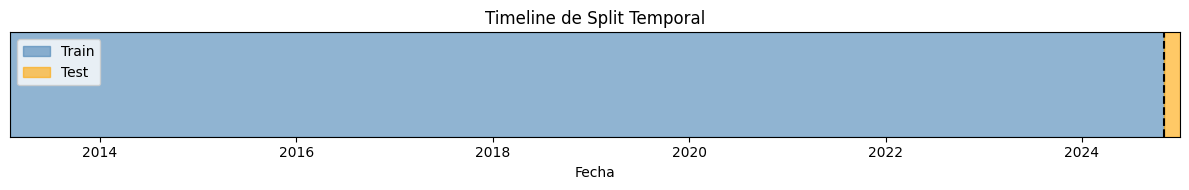

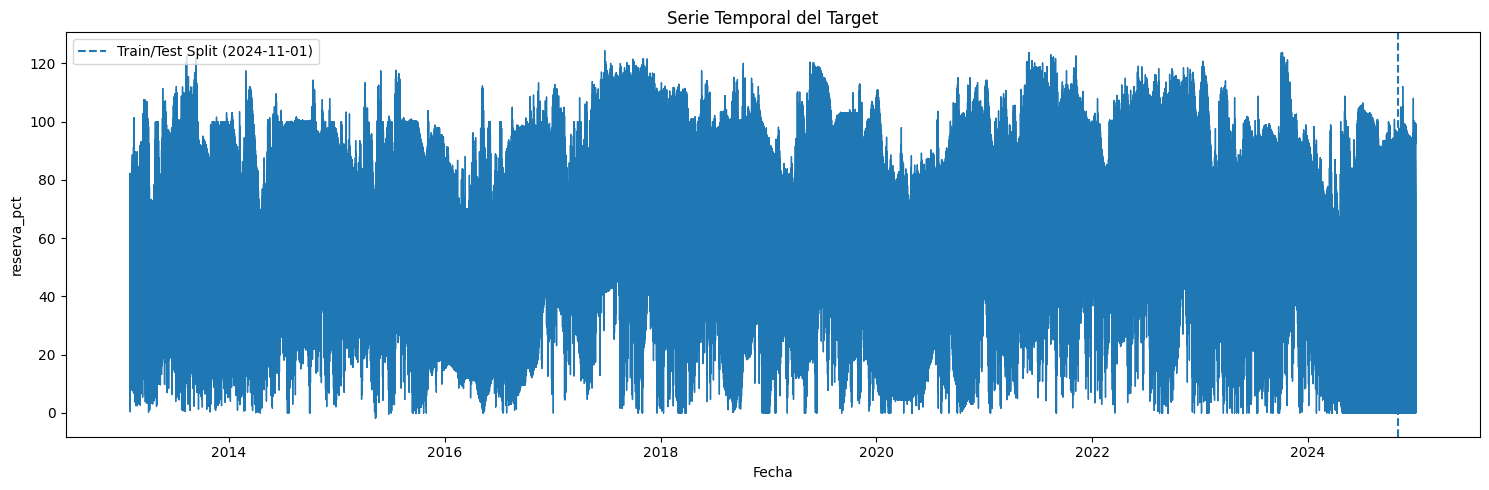

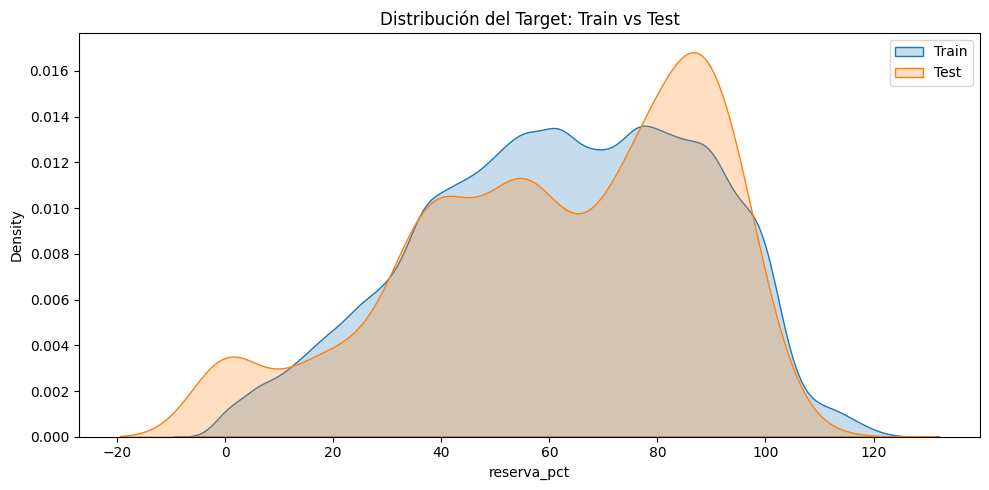

In [227]:
# =========================================================
# CONFIG GENERAL
# =========================================================
plt.style.use("default")

# Fechas del split para usar en las gráficas
fecha_corte = test_fe["Fecha"].min()  # primer día del test

# =========================================================
# 1. TIMELINE DEL SPLIT TEMPORAL
# =========================================================
fig, ax = plt.subplots(figsize=(12, 2))

fecha_min = embalses_fe["Fecha"].min()
fecha_max = embalses_fe["Fecha"].max()

ax.axvspan(fecha_min, fecha_corte, alpha=0.6, label="Train", color="steelblue")
ax.axvspan(fecha_corte, fecha_max, alpha=0.6, label="Test", color="orange")
ax.axvline(fecha_corte, linestyle="--", color="black")
ax.set_xlim(fecha_min, fecha_max)
ax.set_yticks([])
ax.set_title("Timeline de Split Temporal")
ax.set_xlabel("Fecha")
ax.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 2. SERIE TEMPORAL DEL TARGET + SPLIT
# =========================================================
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(
    embalses_fe["Fecha"],
    embalses_fe[TARGET],
    linewidth=1
)

ax.axvline(
    fecha_corte,
    linestyle="--",
    label=f"Train/Test Split ({fecha_corte.date()})"
)

ax.set_title("Serie Temporal del Target")
ax.set_xlabel("Fecha")
ax.set_ylabel(TARGET)
ax.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 3. DISTRIBUCIÓN TRAIN VS TEST
# =========================================================
fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(y_train, label="Train", fill=True, ax=ax)
sns.kdeplot(y_test,  label="Test",  fill=True, ax=ax)

ax.set_title("Distribución del Target: Train vs Test")
ax.set_xlabel(TARGET)
ax.legend()
plt.tight_layout()
plt.show()

#### Comparación Validación Cruzada

In [228]:
cv_results_df = pd.DataFrame([
    xgb_cv_result,
    rf_cv_result,
    extra_cv_result,
    lgbm_cv_result
]).sort_values("cv_rmse_mean")

cv_results_df

,experiment,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_r2_mean
3,LightGBM CV,20.401535,2.142656,15.929059,0.277957
1,Random Forest CV,20.684623,2.292254,16.534908,0.255791
0,XGBoost CV,20.776636,2.346787,16.253746,0.250210
2,Extra Trees CV,21.016471,2.468929,16.686258,0.230576


### Análisis Comparación de Métricas


                                  RESULTADOS — MODELOS                                  


,rmse,mae,r2,experiment,MASE
5,6.186789,3.313675,0.948122,Naive Baseline,1.000000
0,20.511274,15.574815,0.429750,LightGBM,4.722948
1,21.970641,16.204263,0.345717,XGBoost,4.895409
2,22.089761,17.281777,0.338603,Random Forest,5.232523
3,22.328346,15.897042,0.324238,Extra Trees,4.819727
4,25.190290,19.122656,0.139904,Baseline Decision Tree,NaN


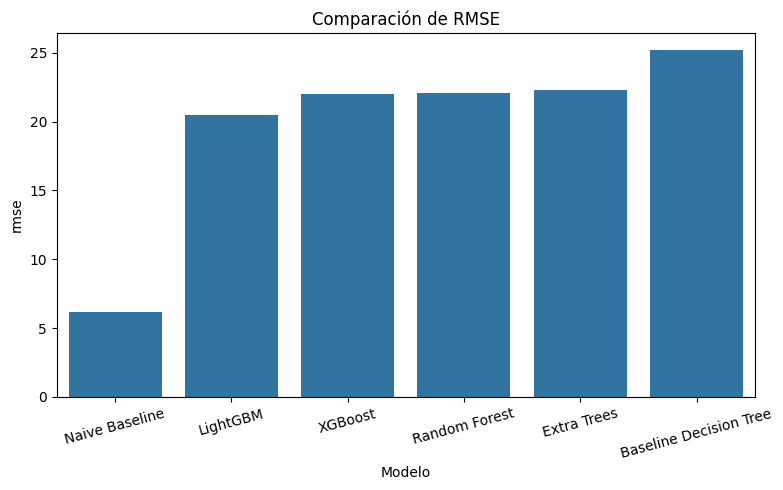

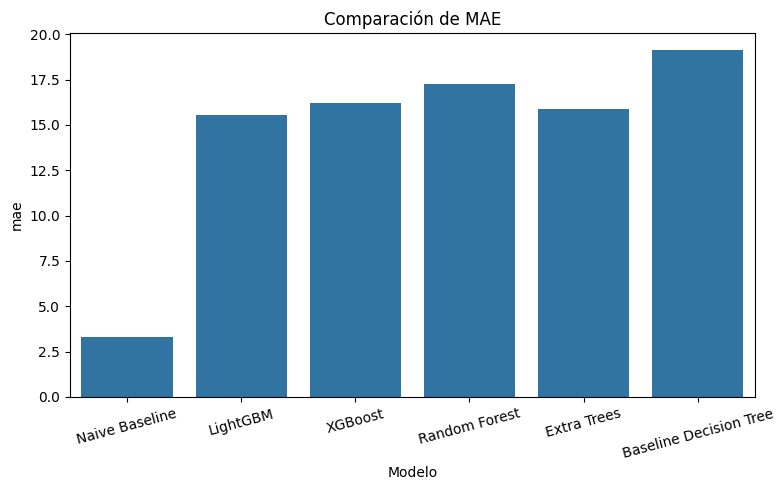

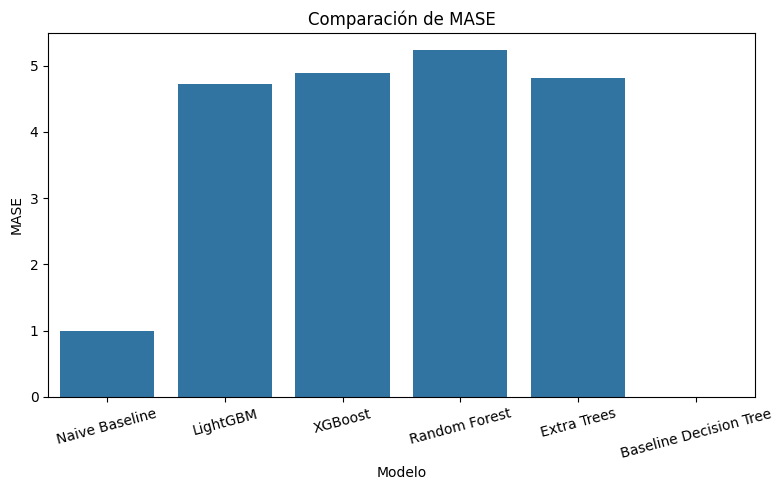

Embalses seleccionados:
['AGREGADO_BOGOTA', 'ALTOANCH', 'BETANIA', 'CALIMA1', 'CHUZA']
EMBALSE: AGREGADO_BOGOTA


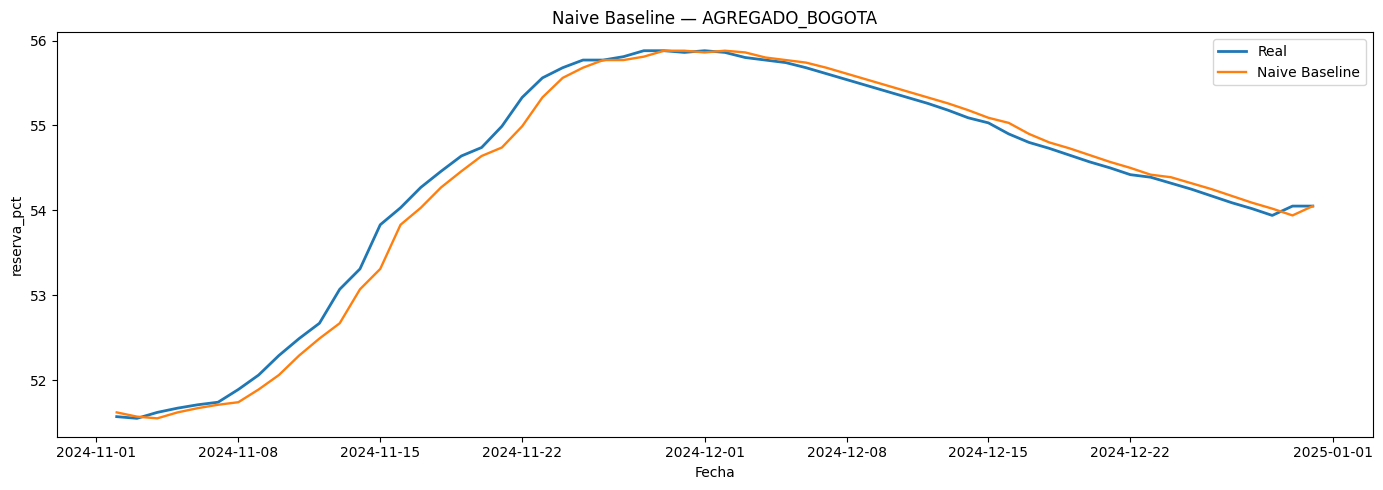

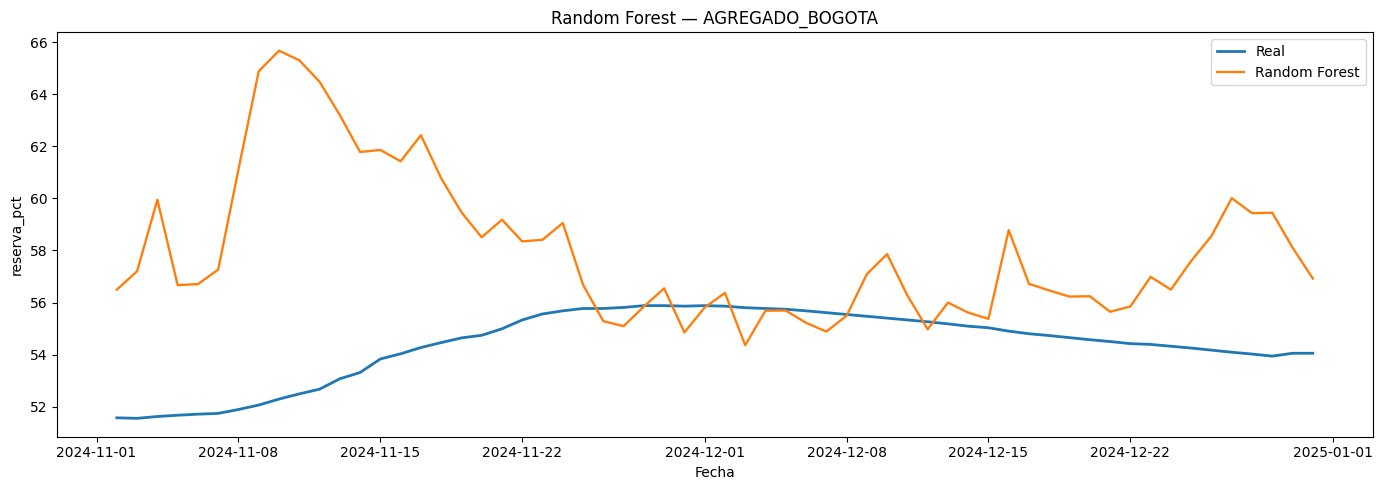

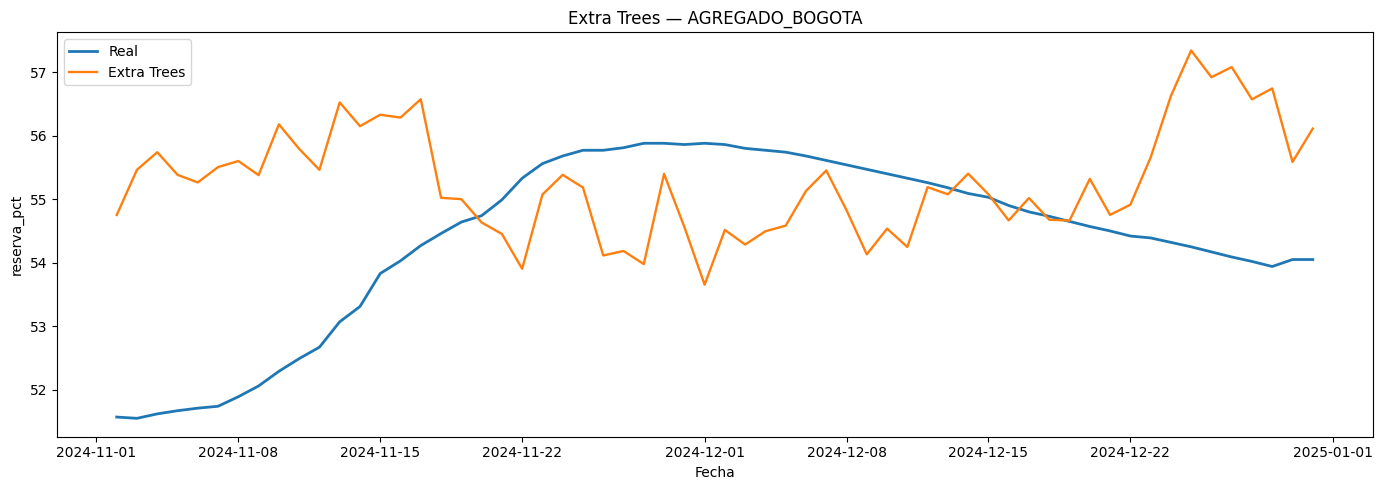

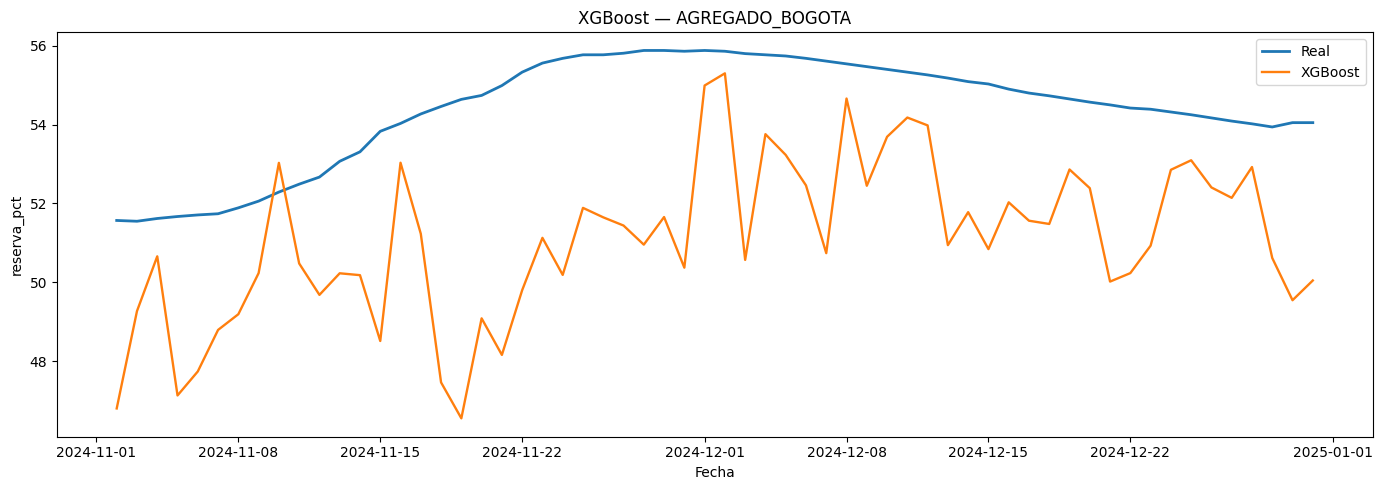

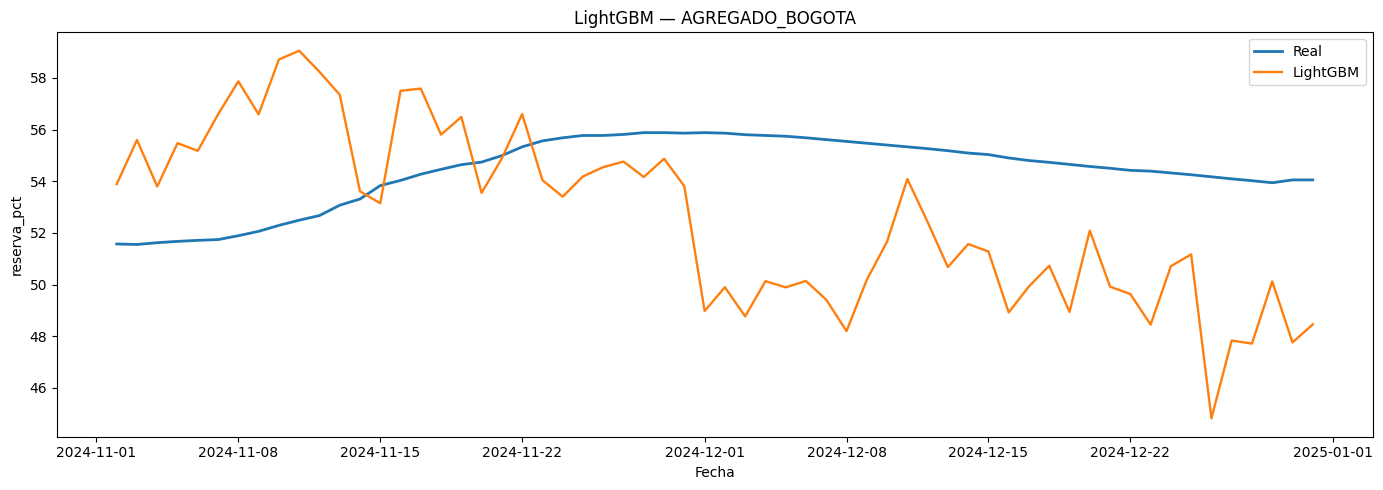

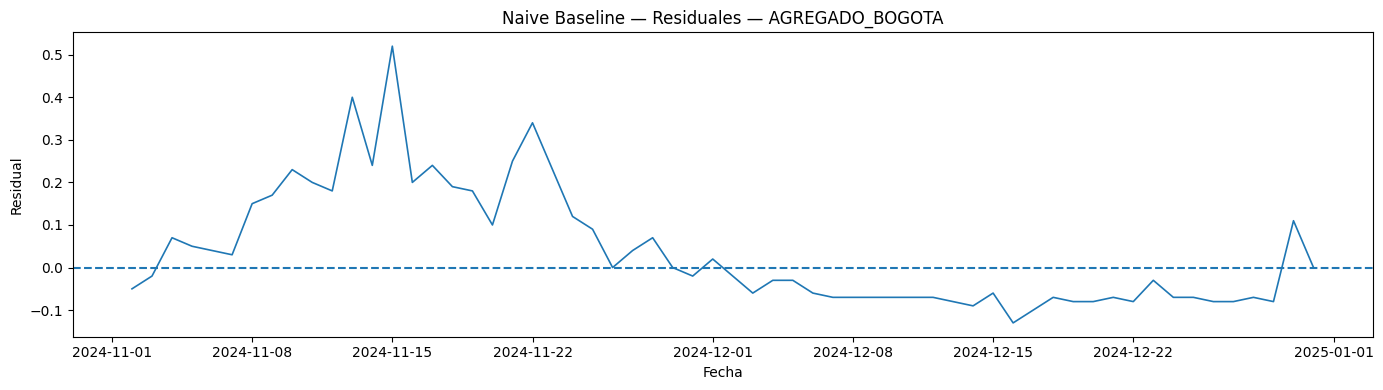

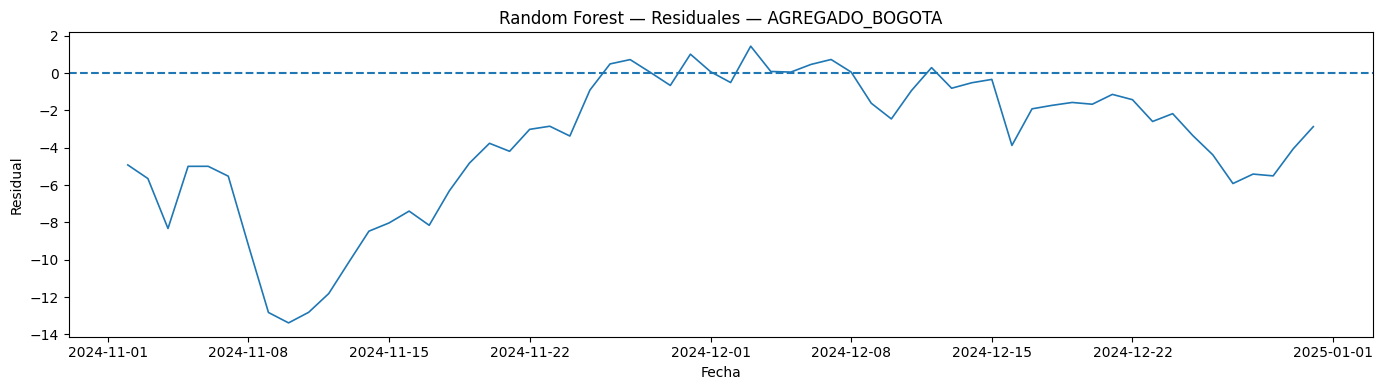

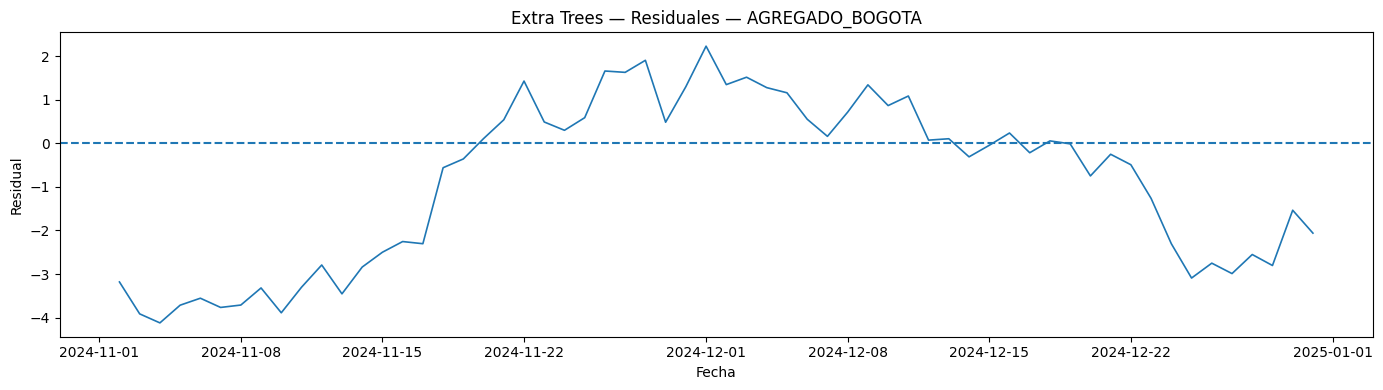

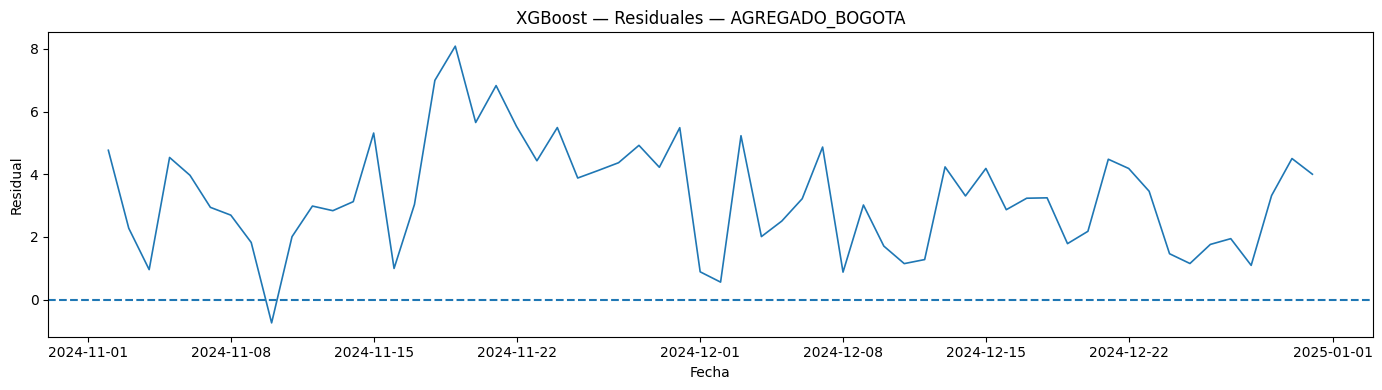

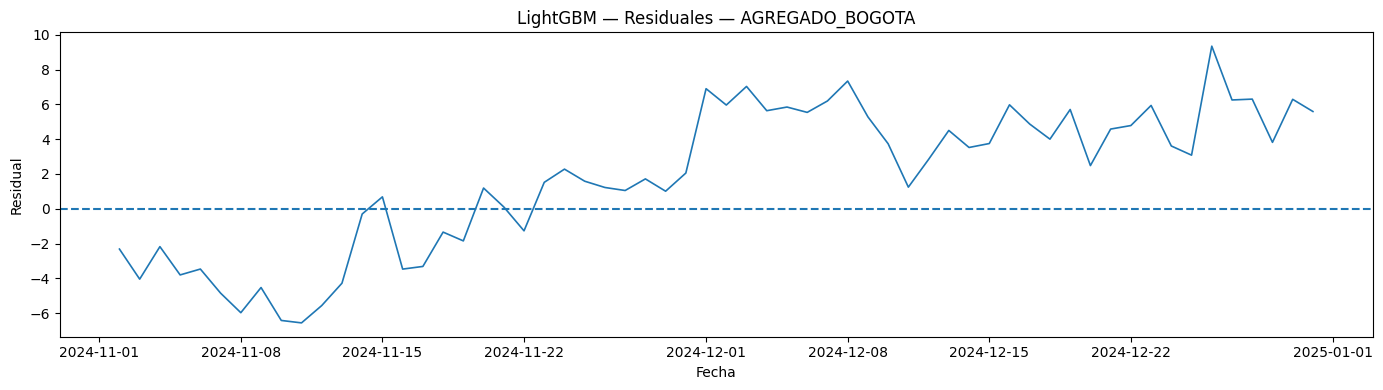

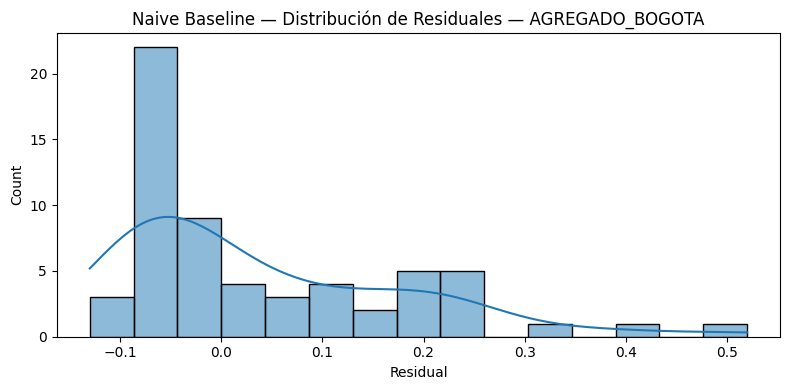

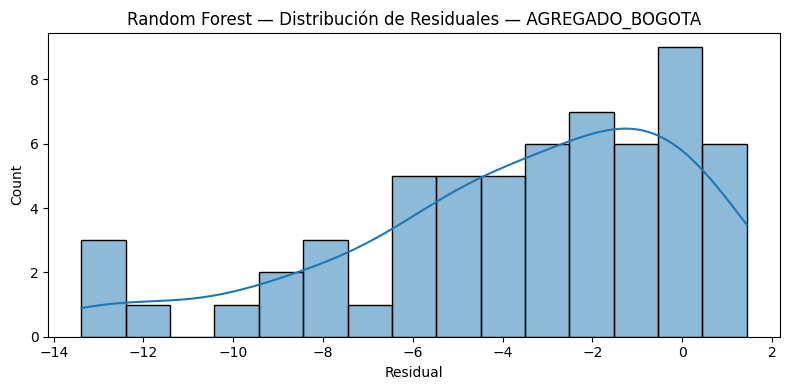

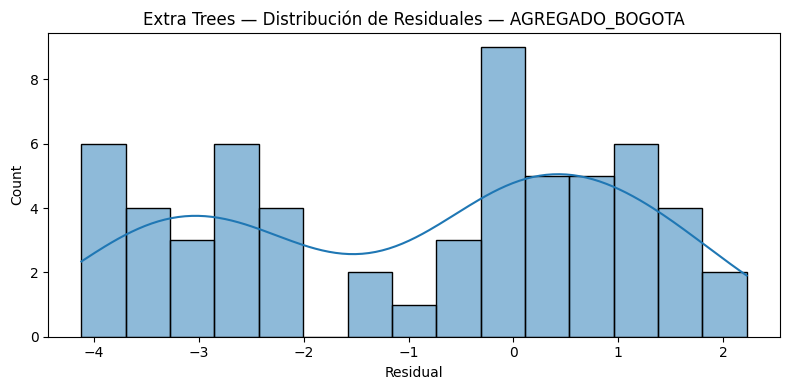

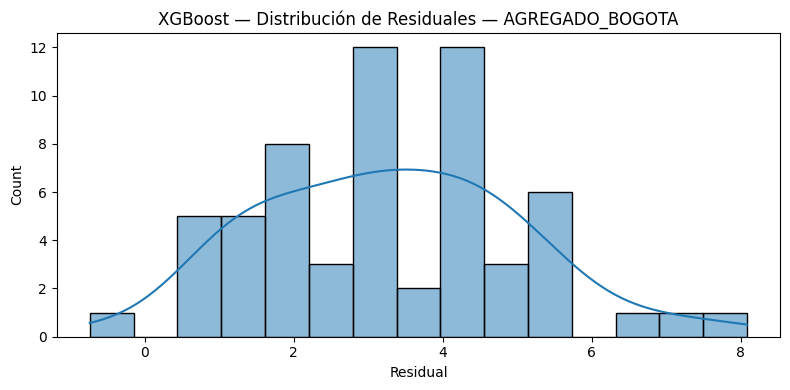

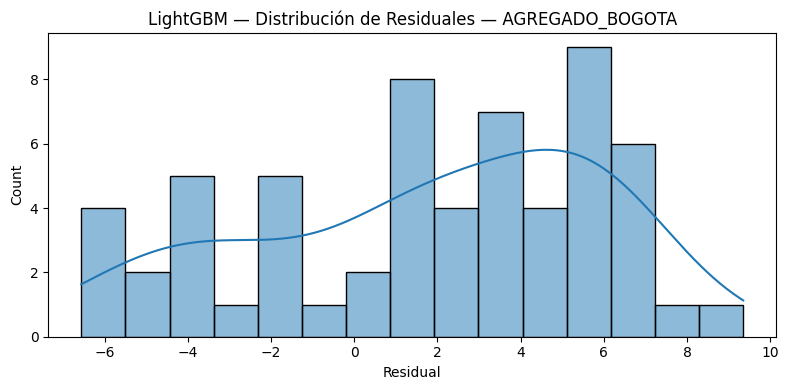

EMBALSE: ALTOANCH


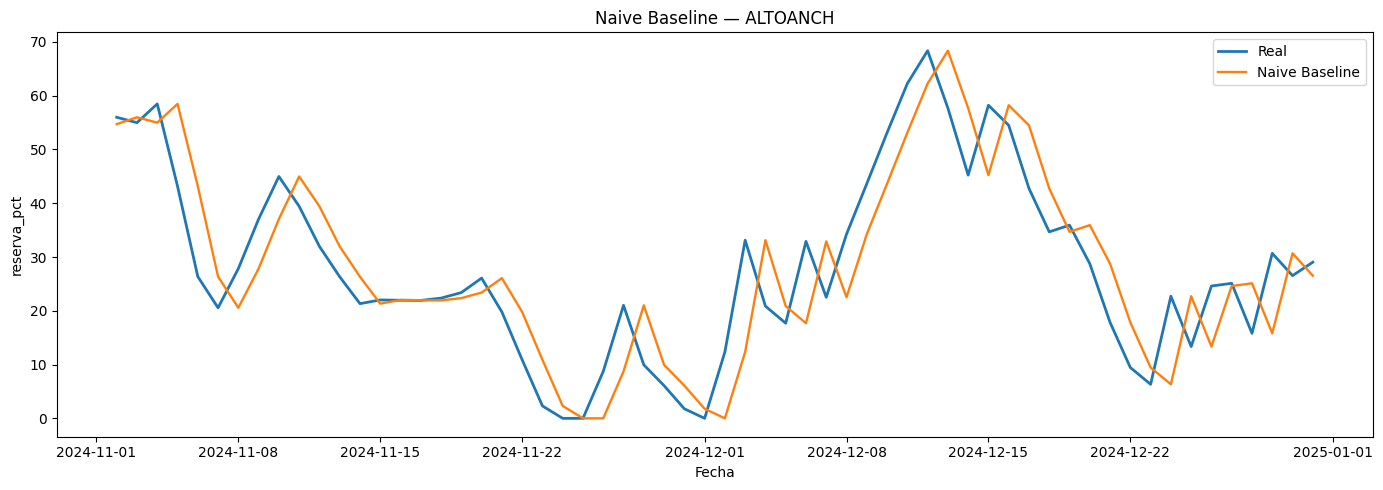

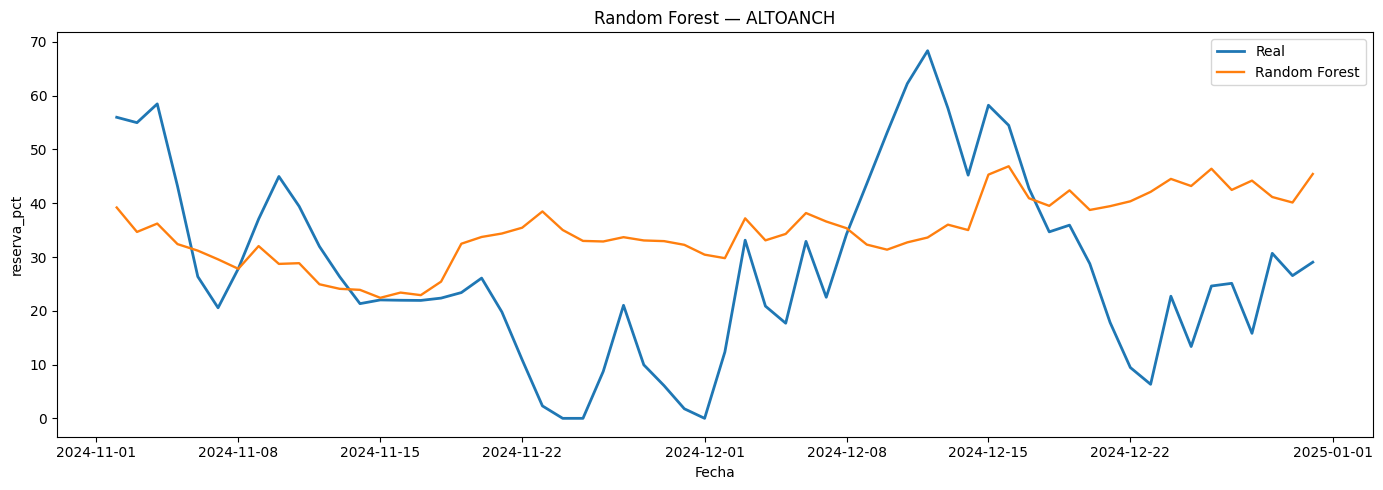

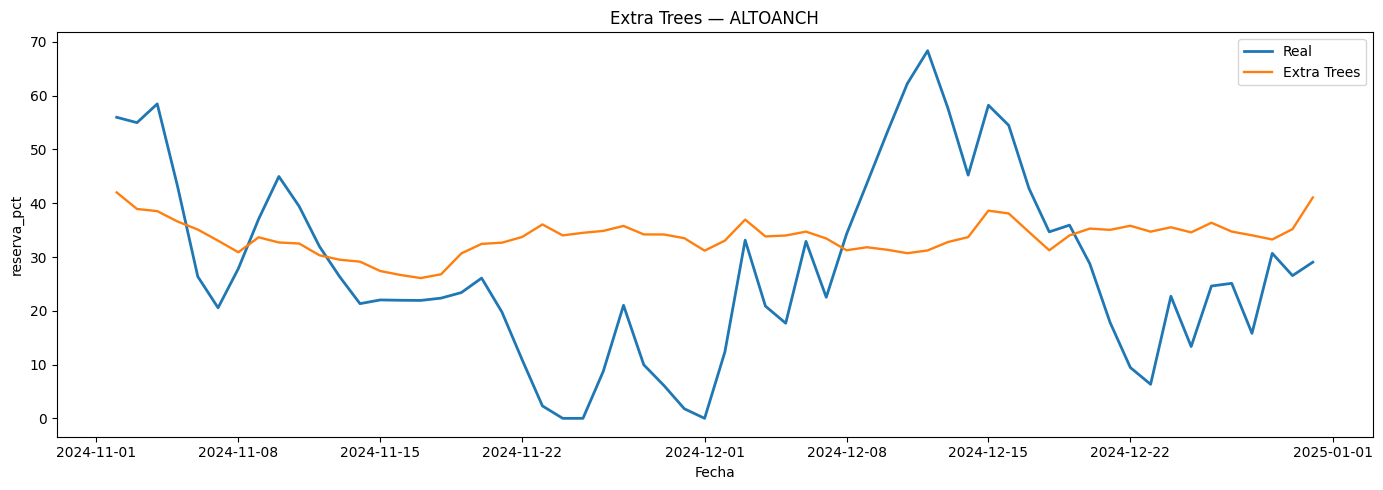

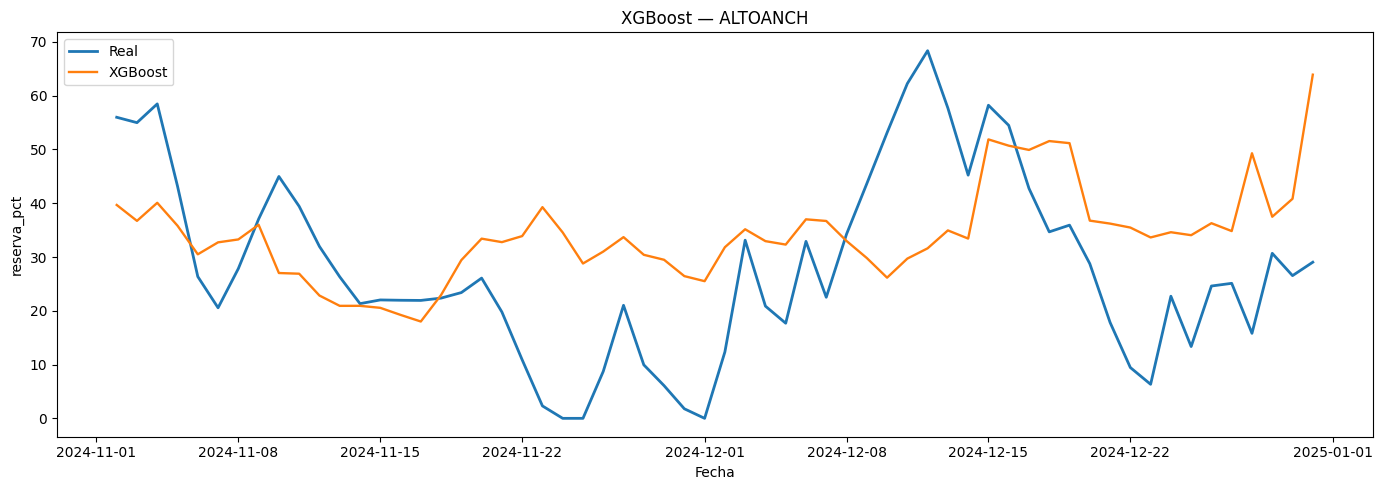

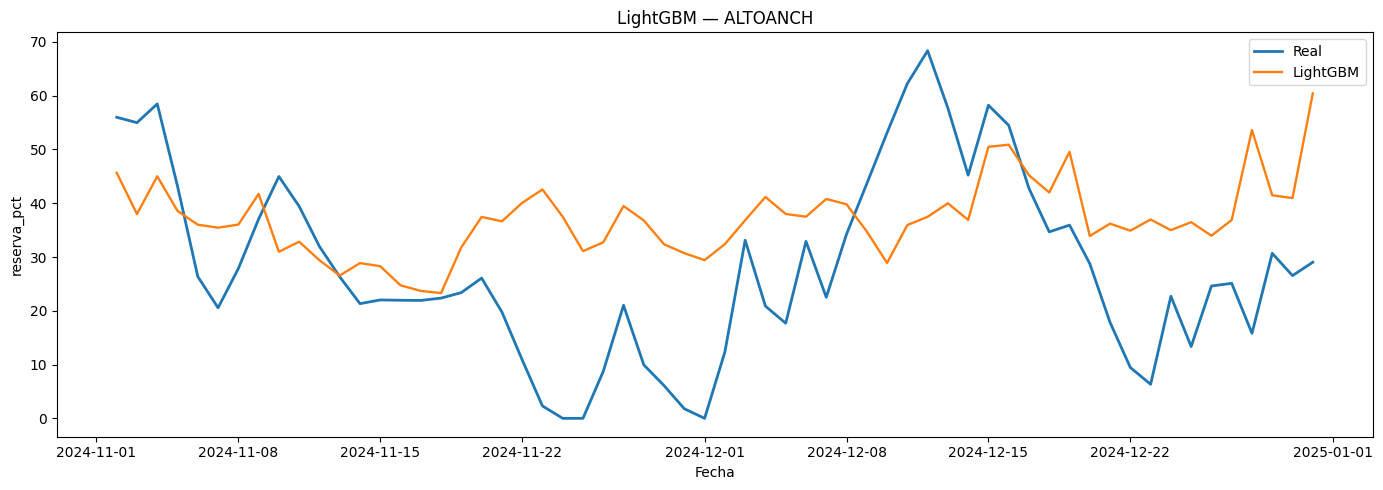

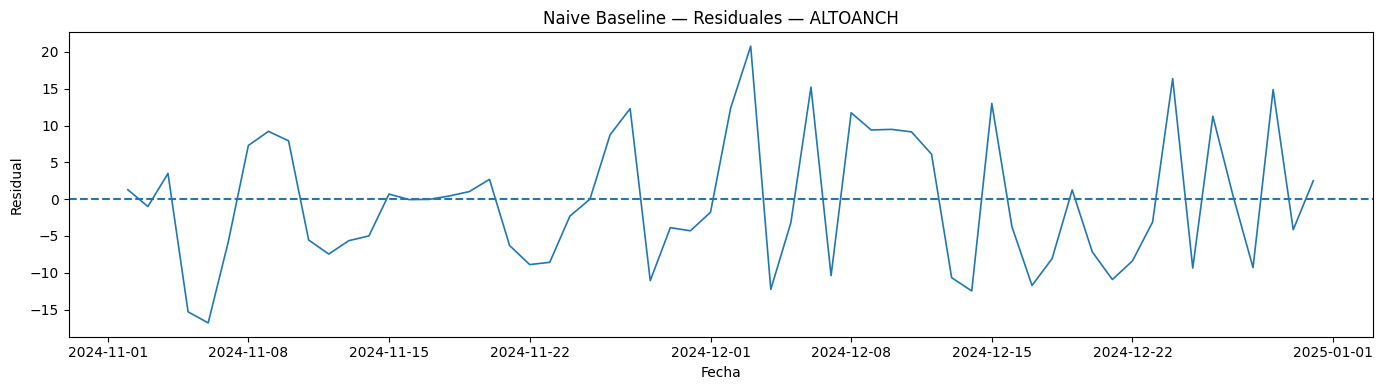

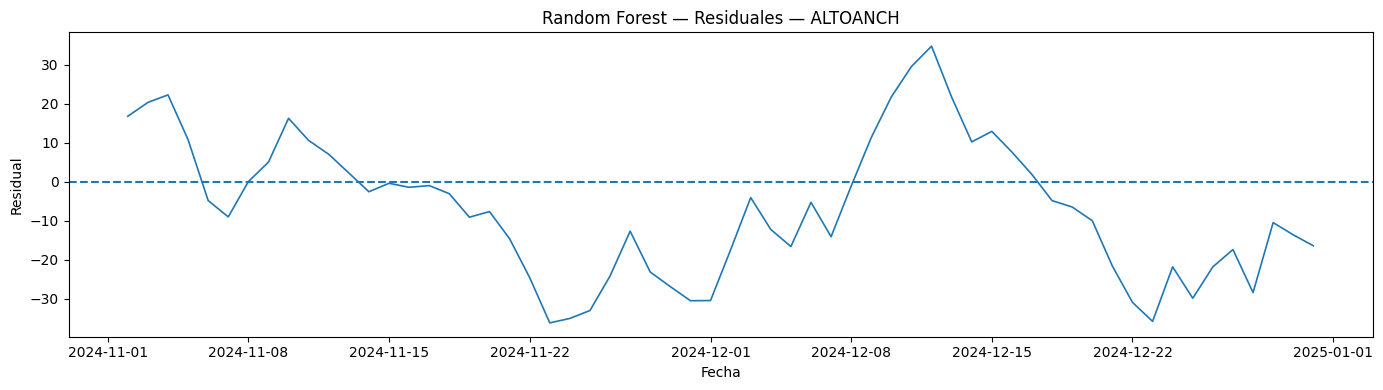

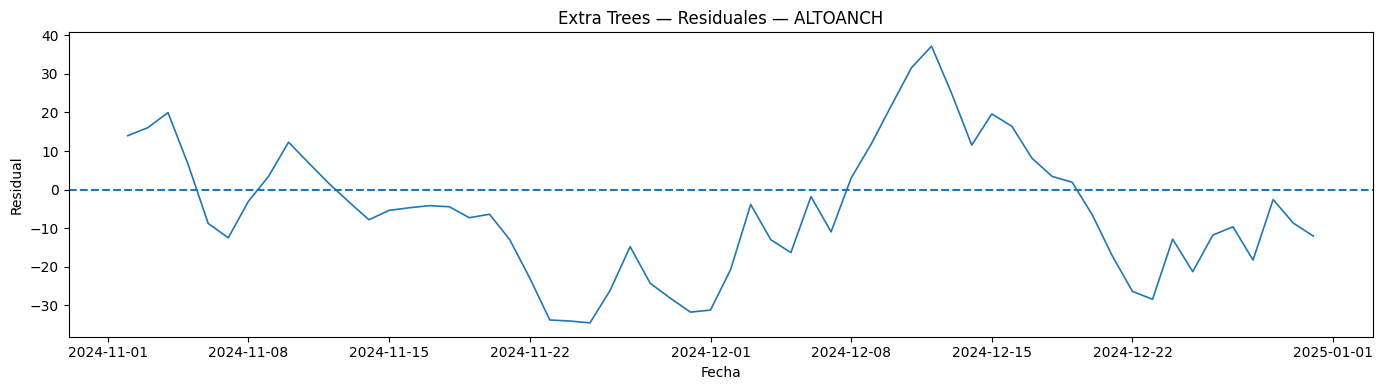

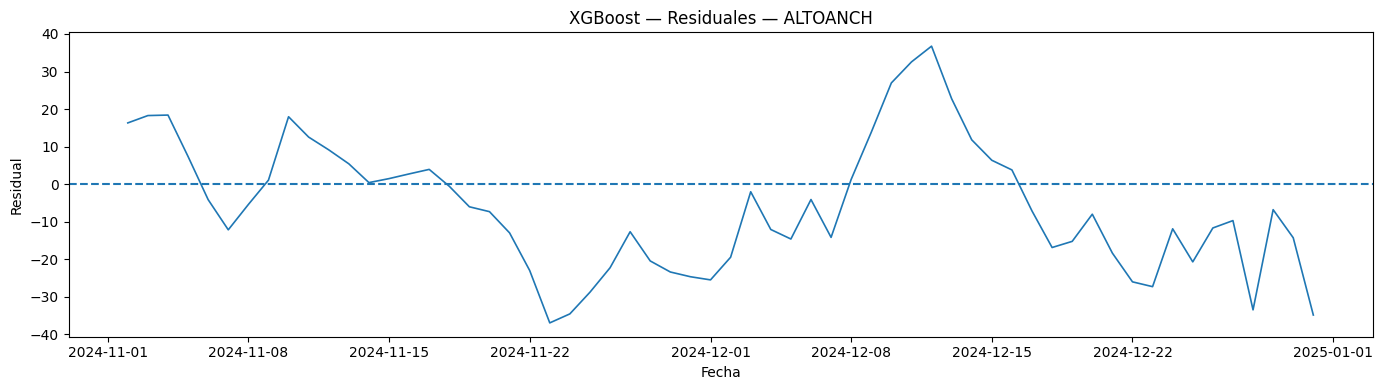

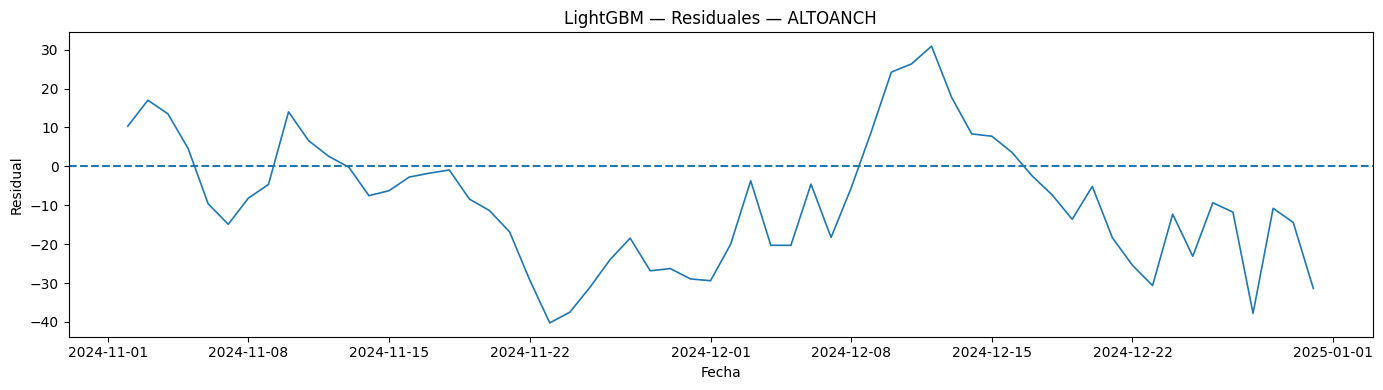

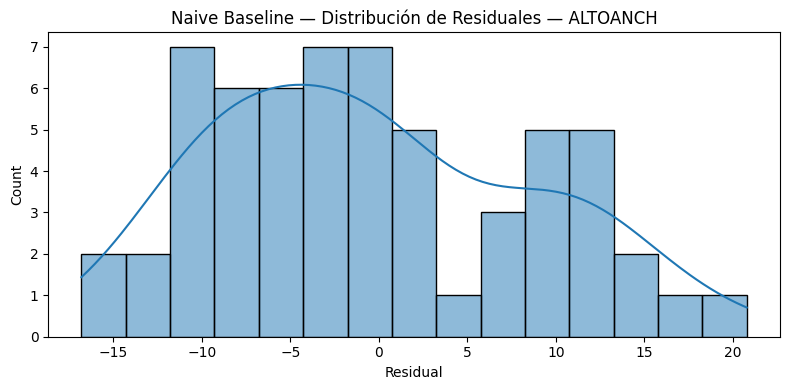

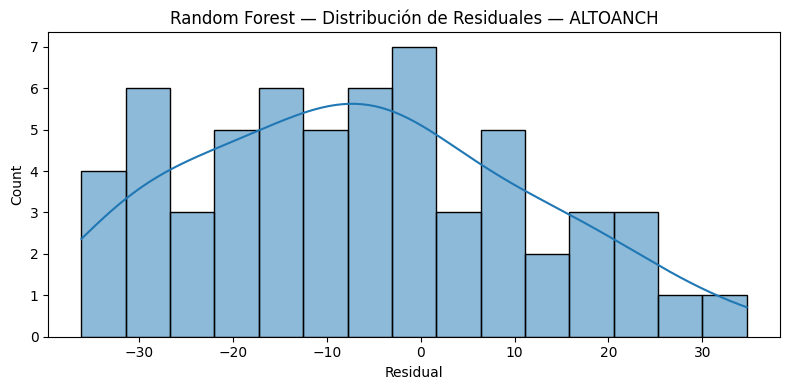

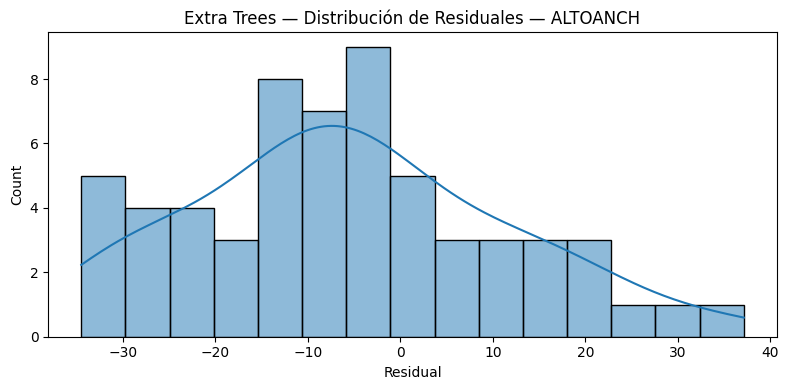

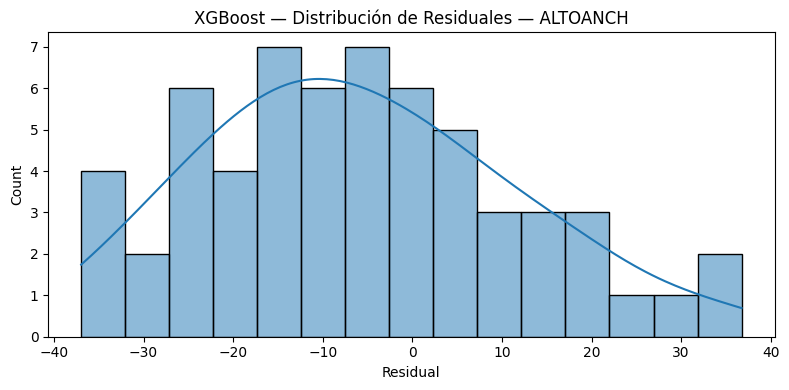

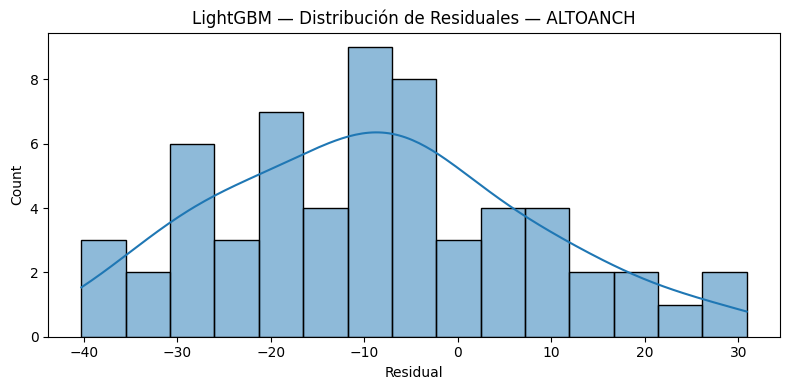

EMBALSE: BETANIA


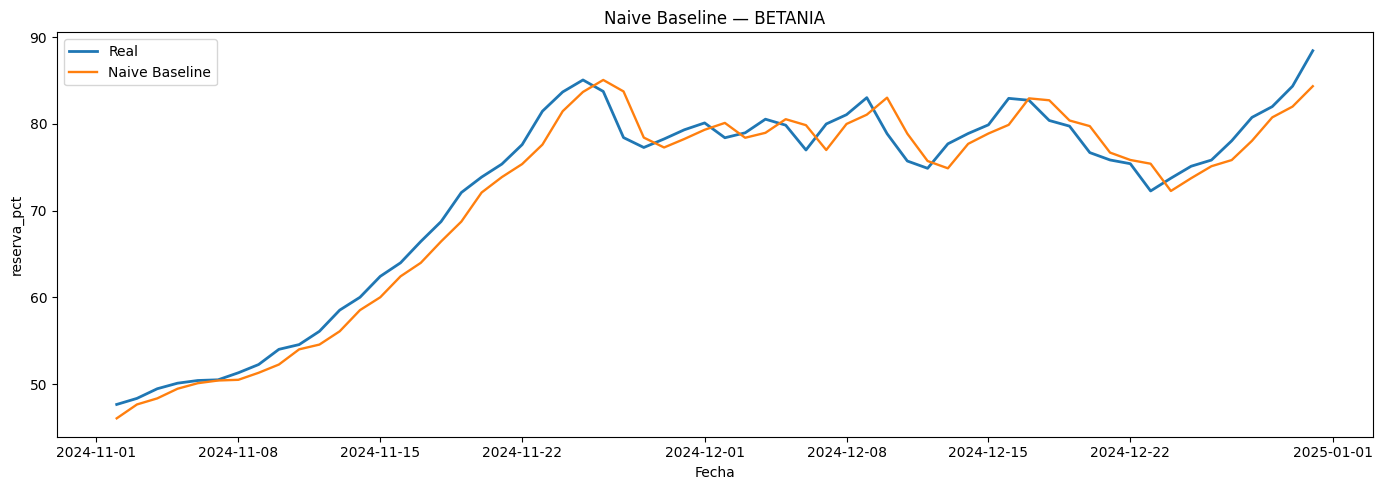

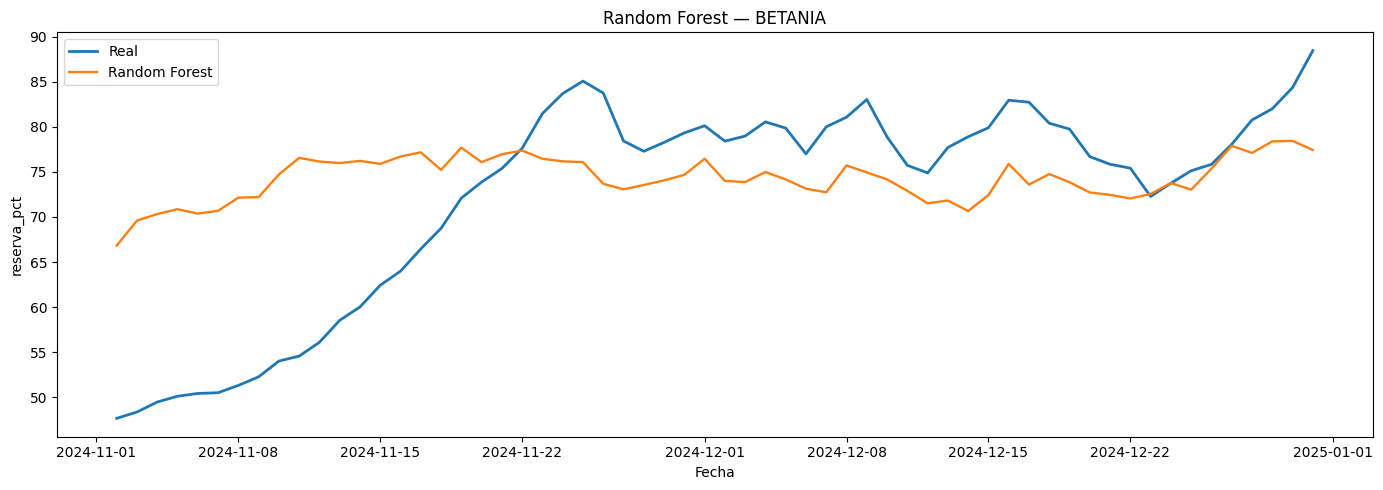

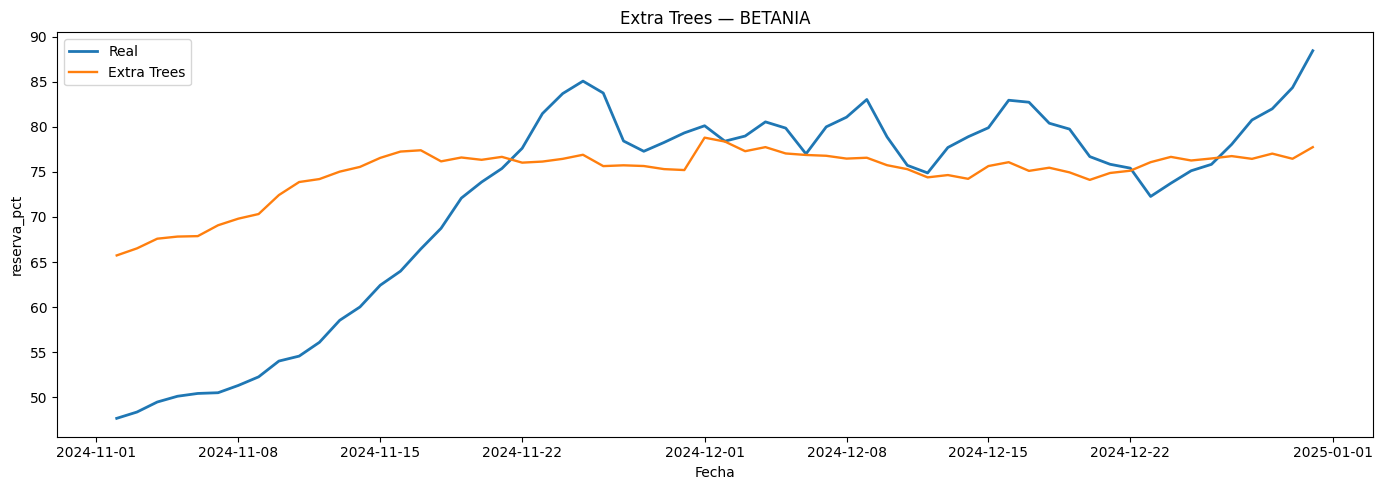

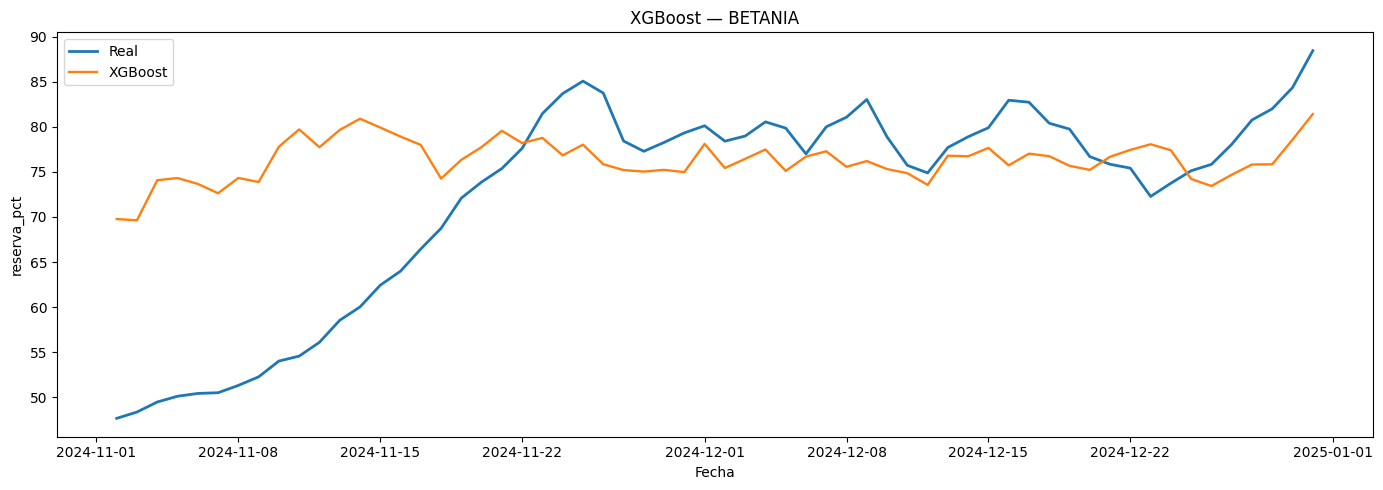

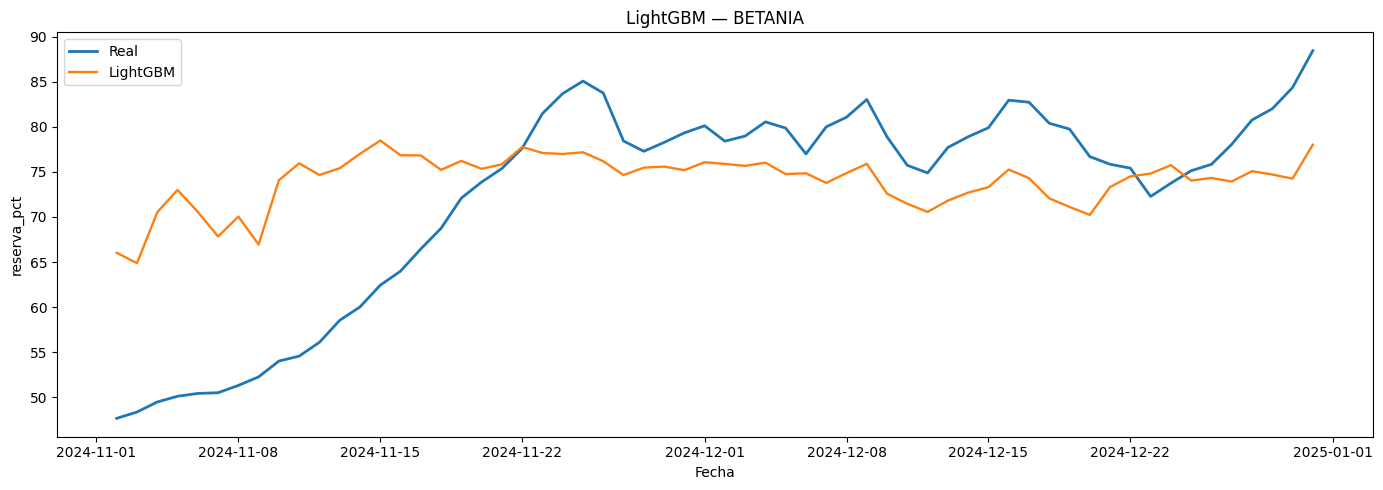

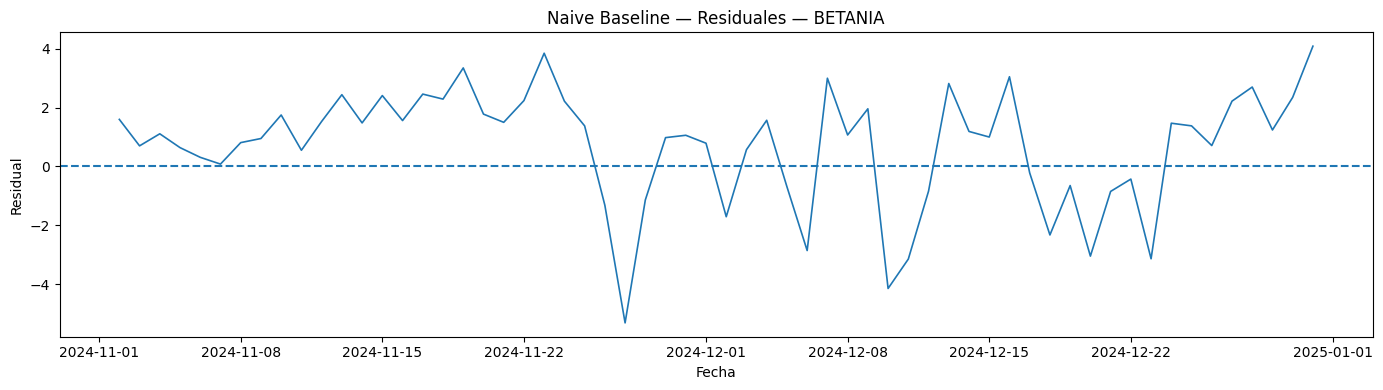

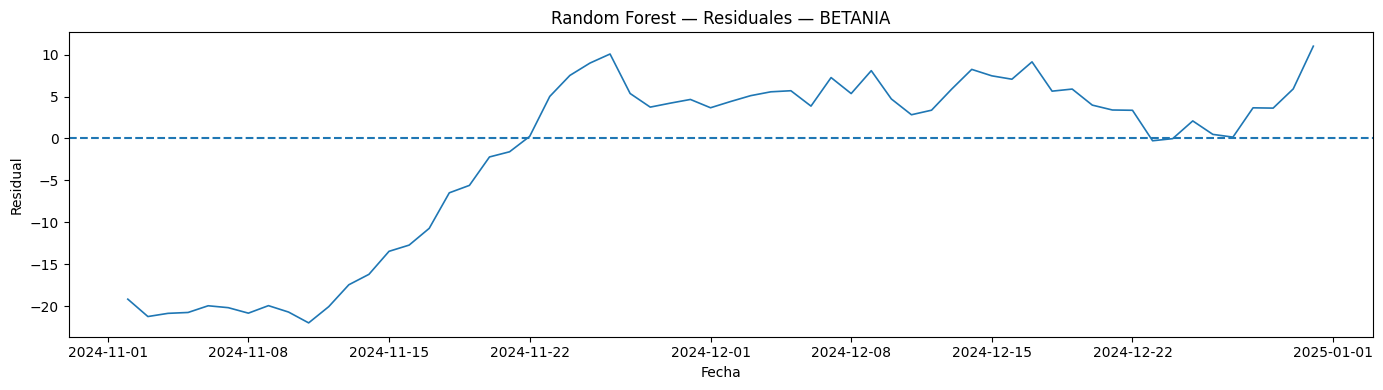

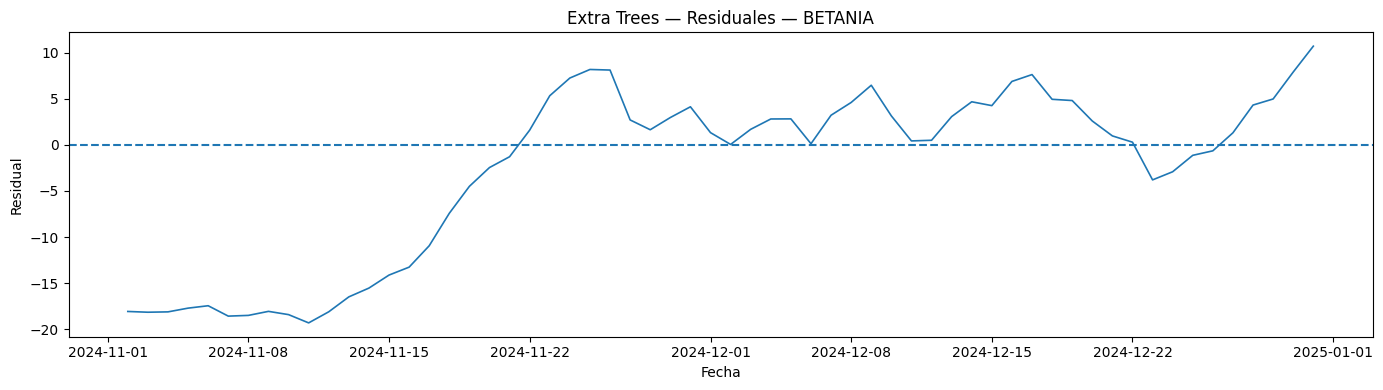

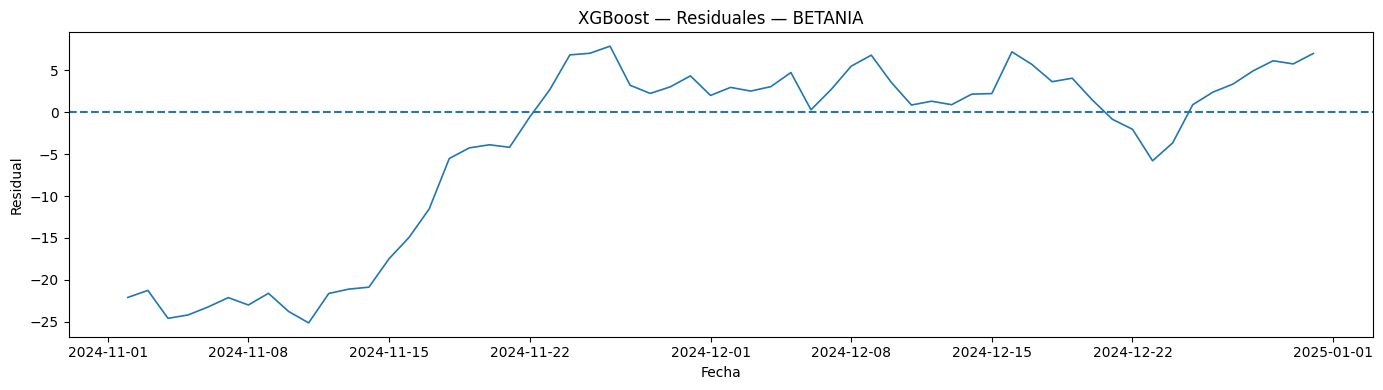

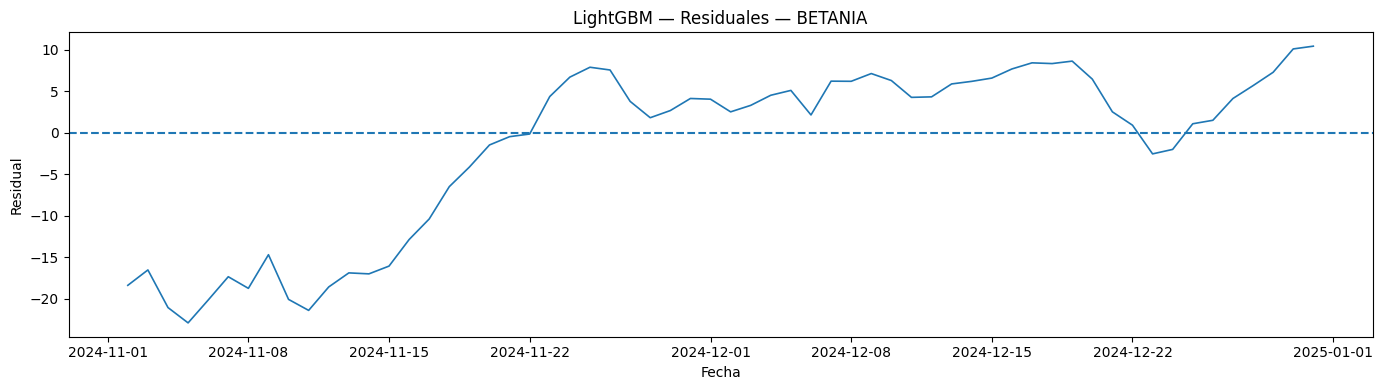

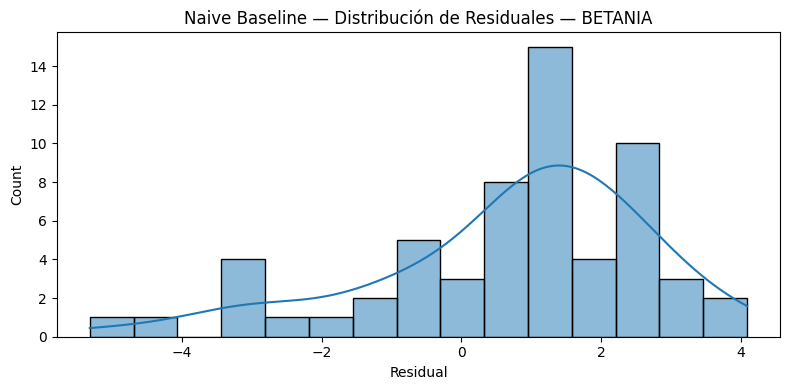

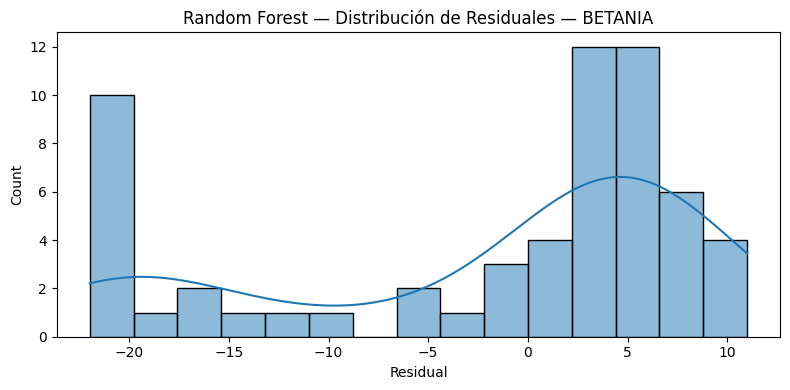

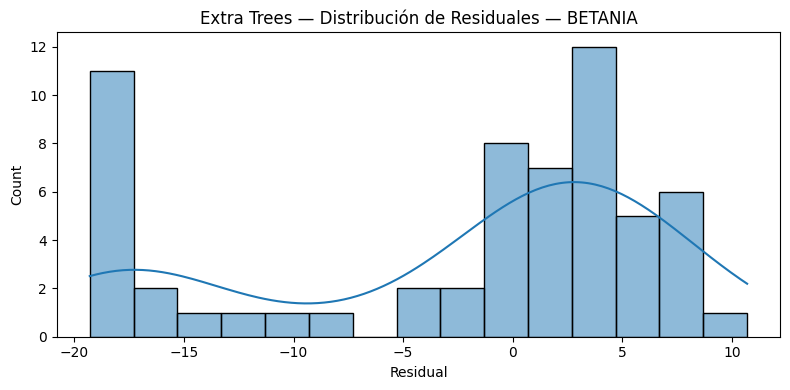

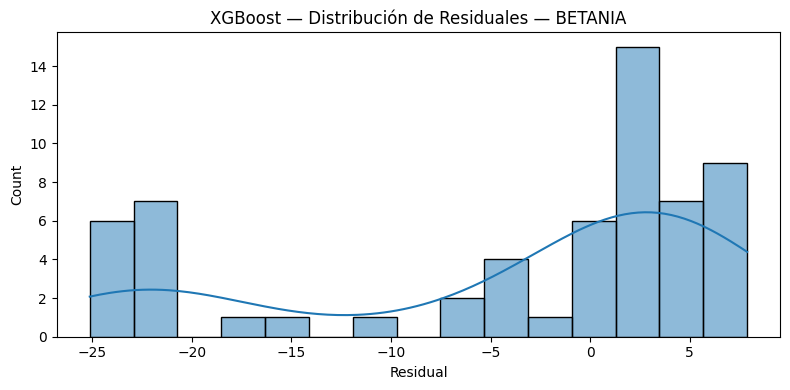

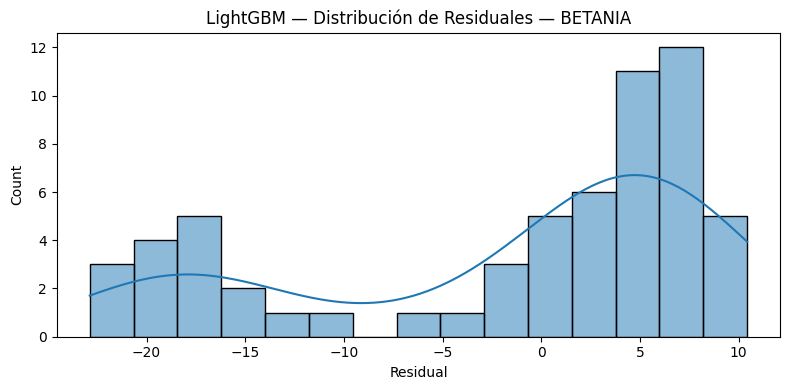

EMBALSE: CALIMA1


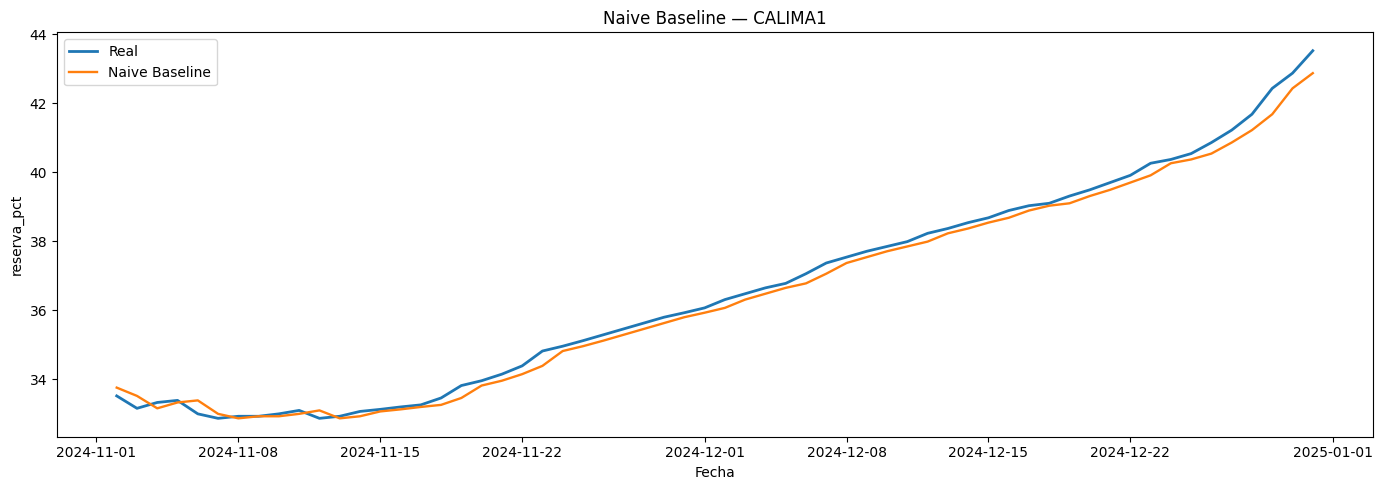

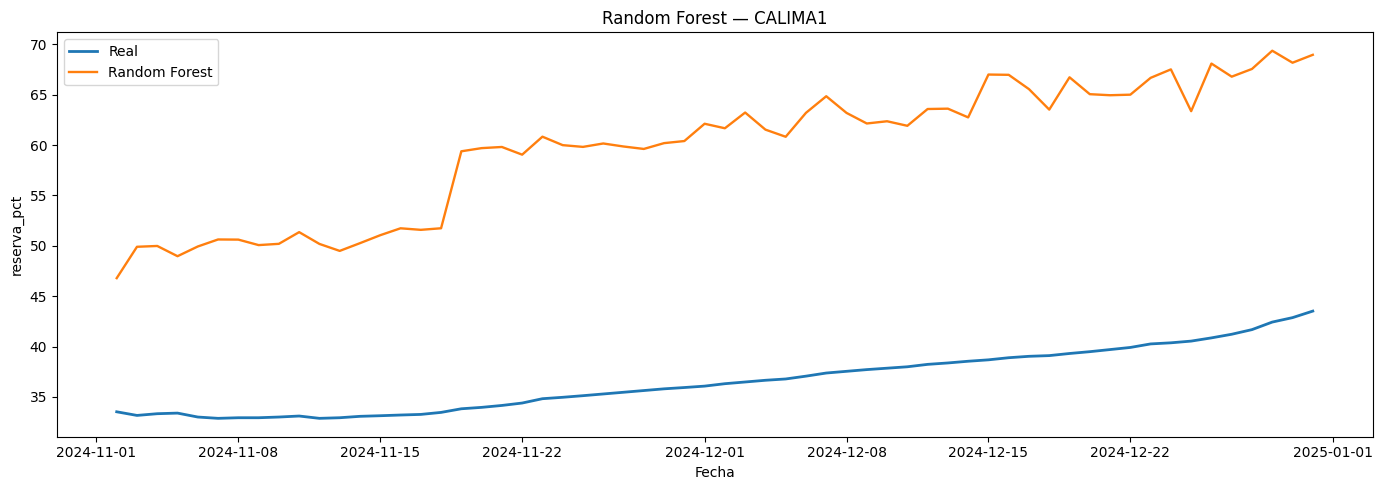

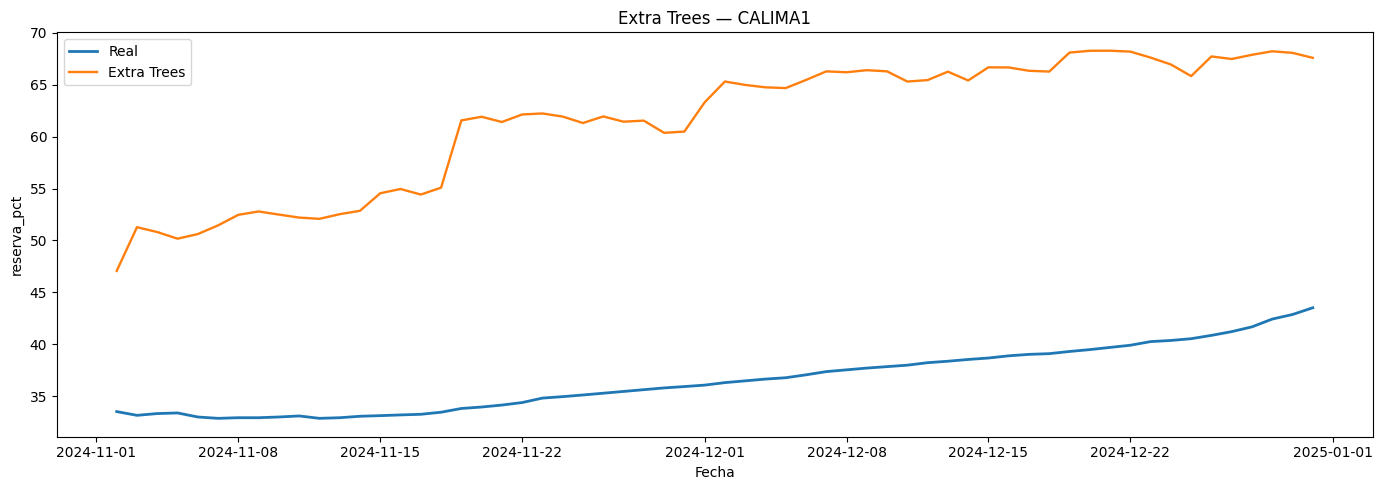

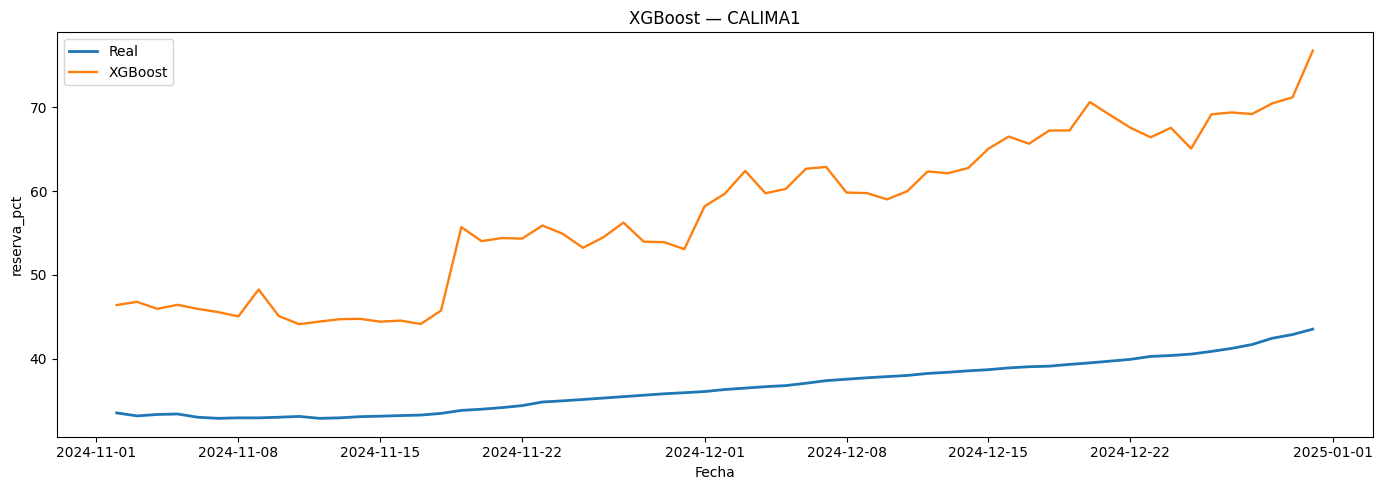

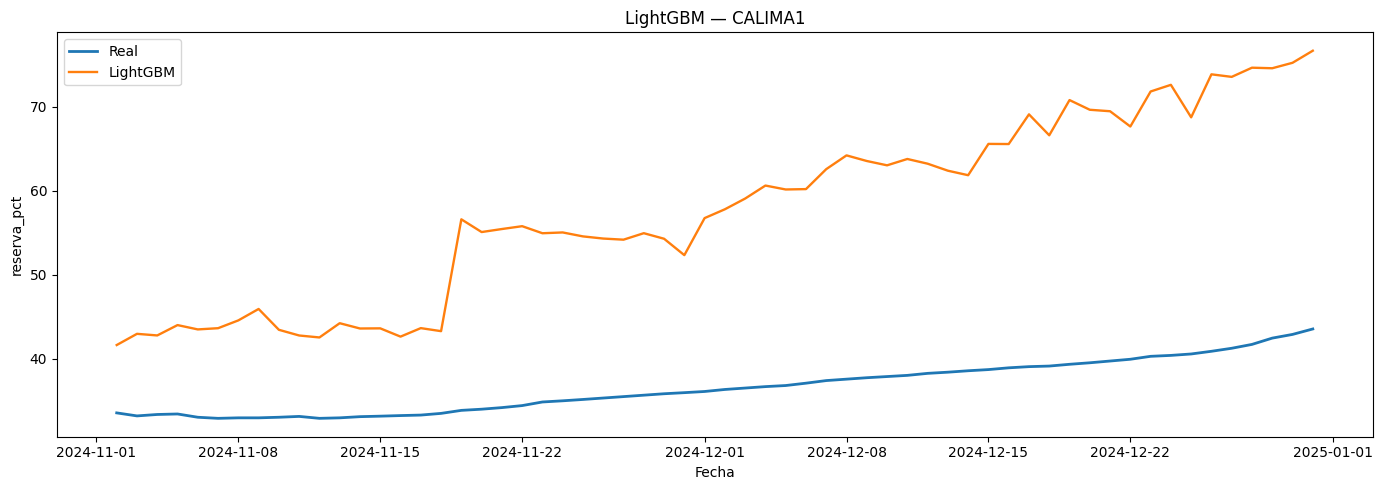

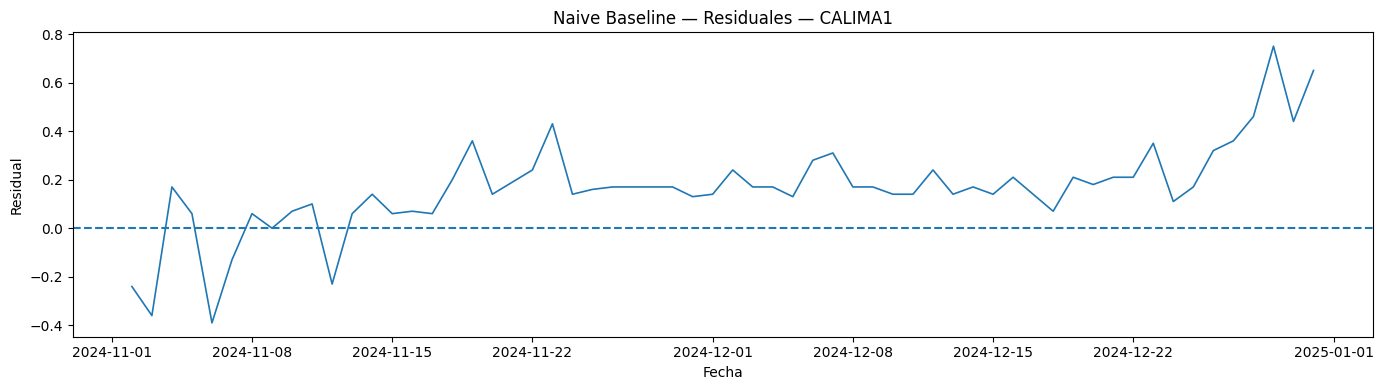

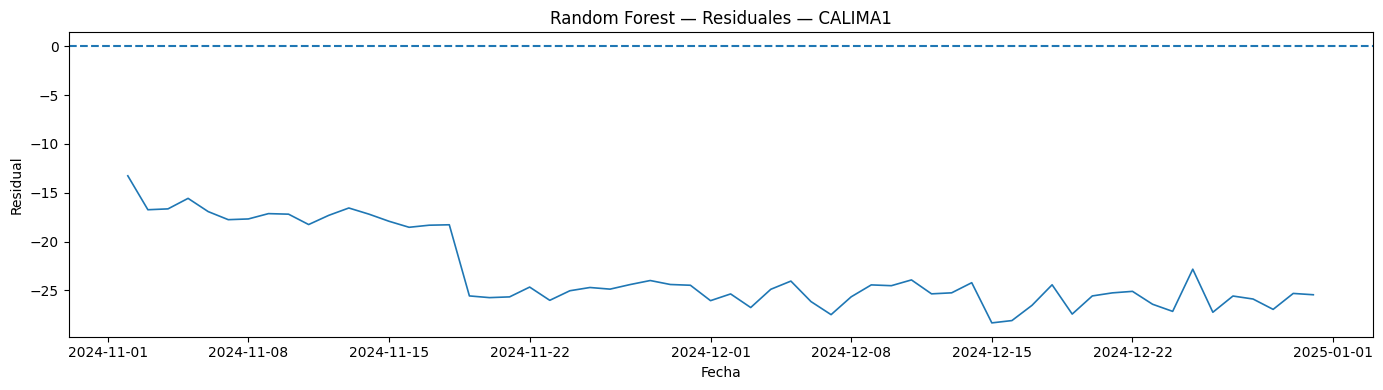

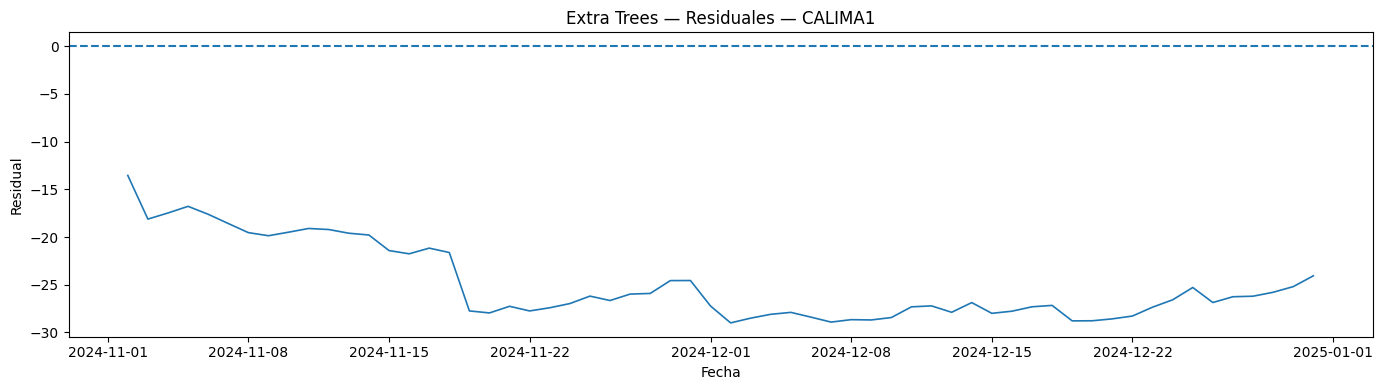

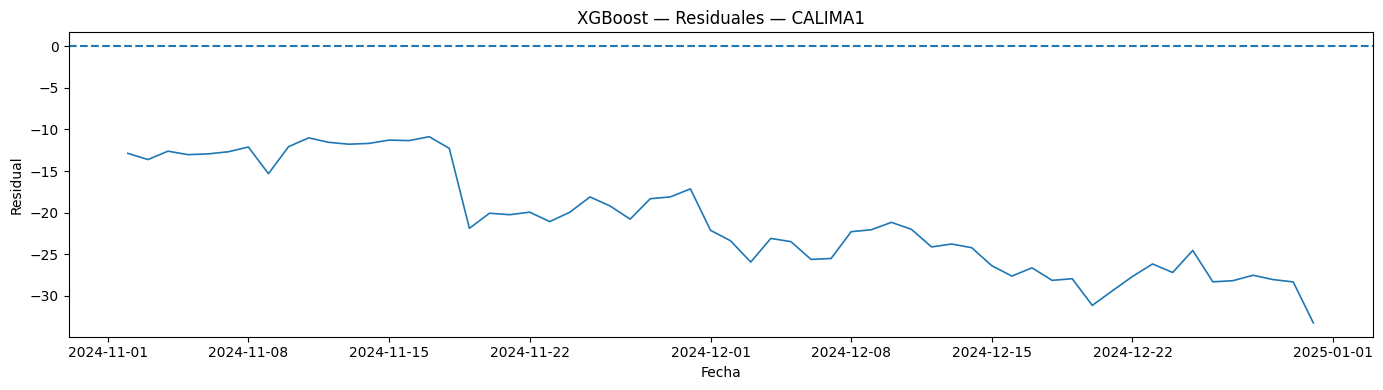

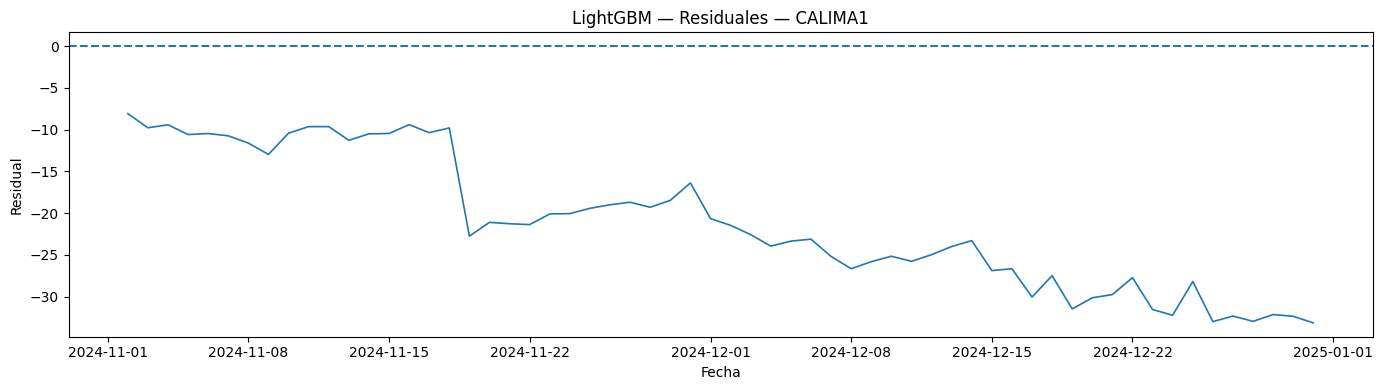

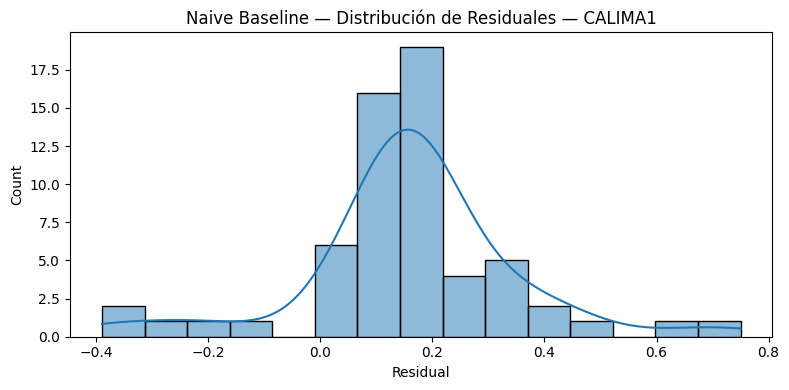

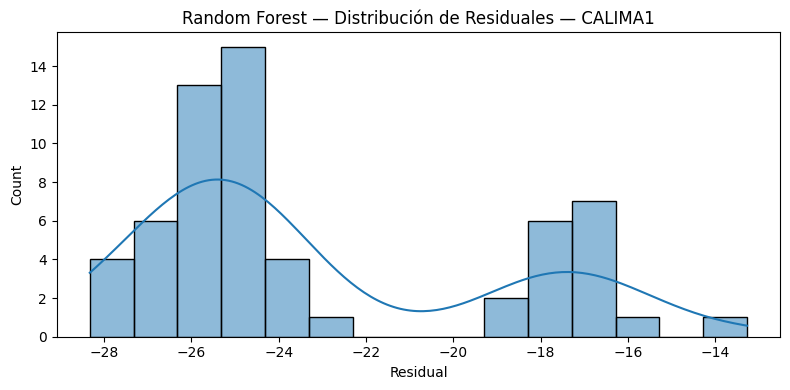

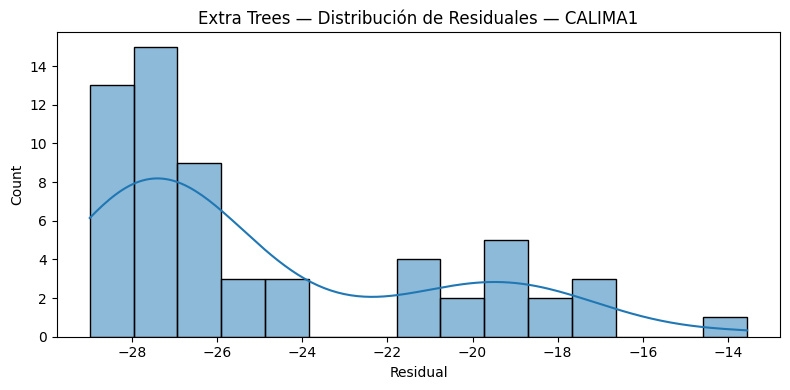

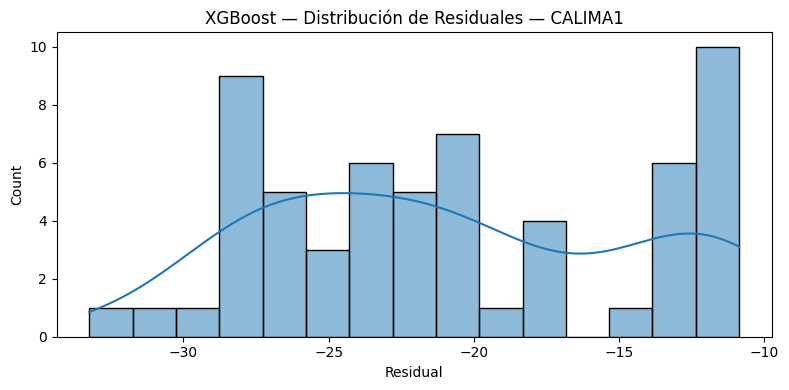

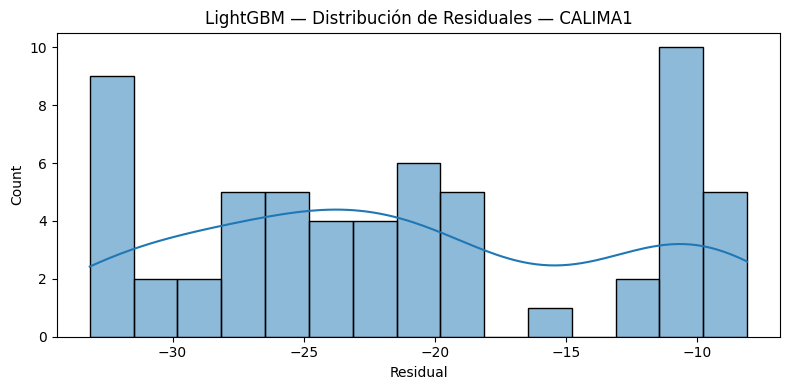

EMBALSE: CHUZA


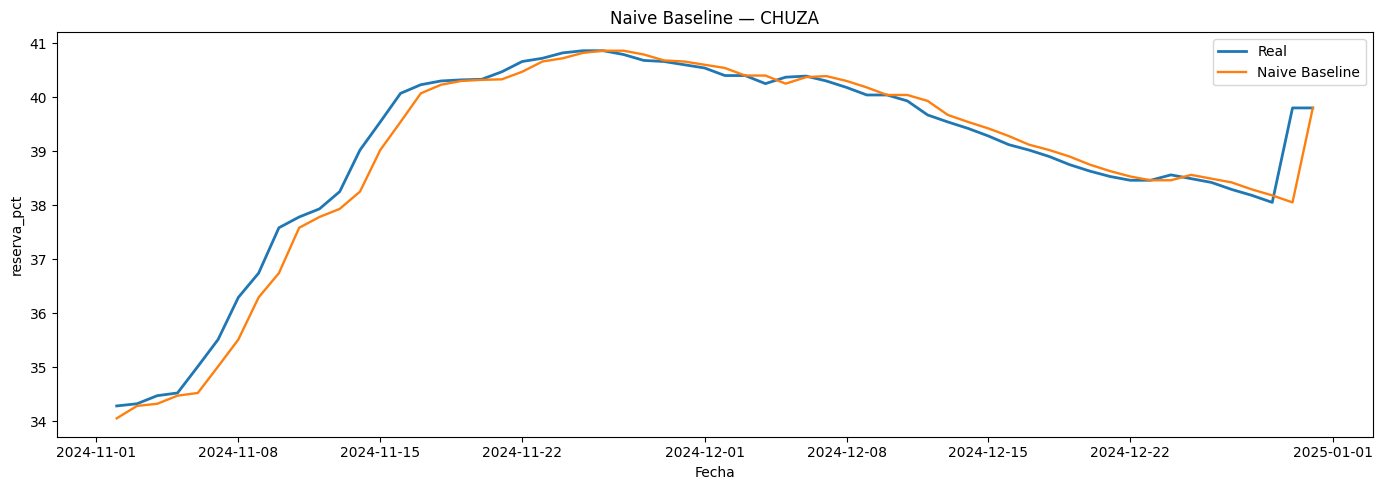

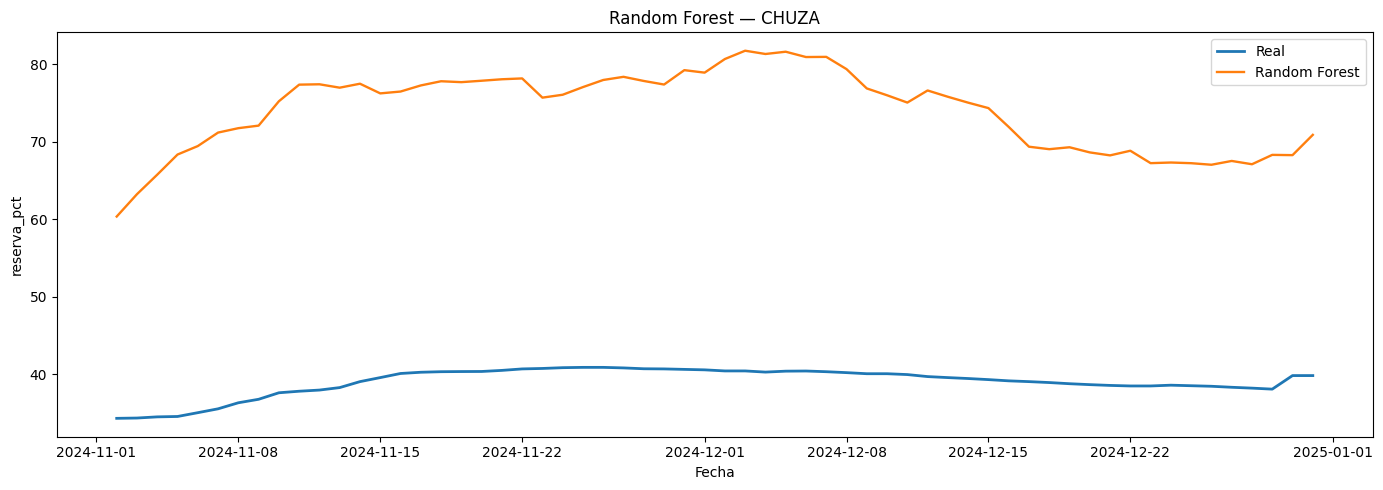

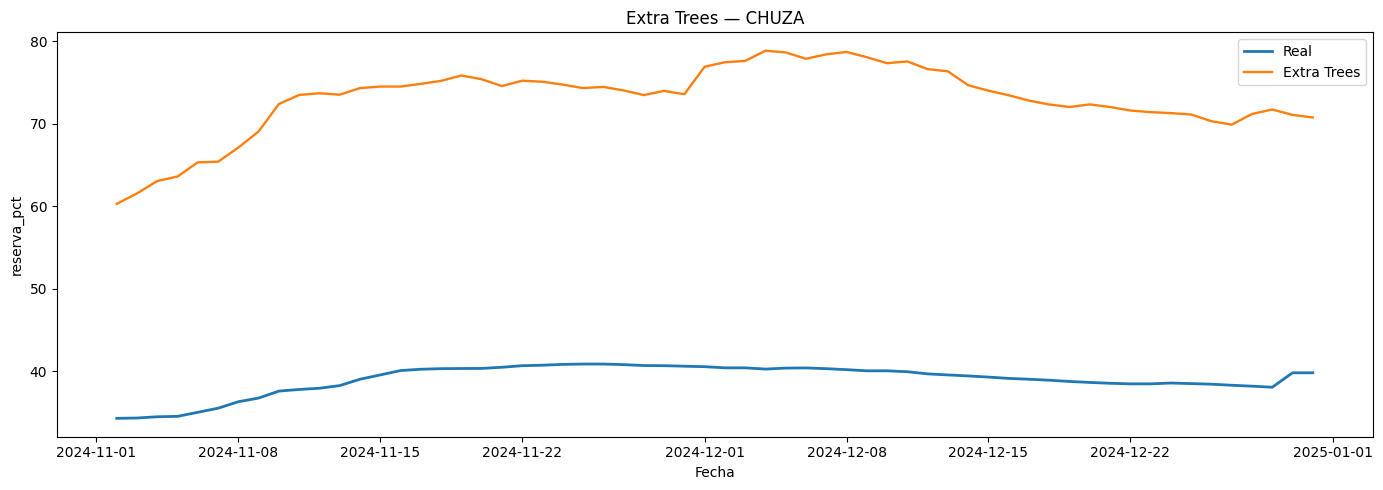

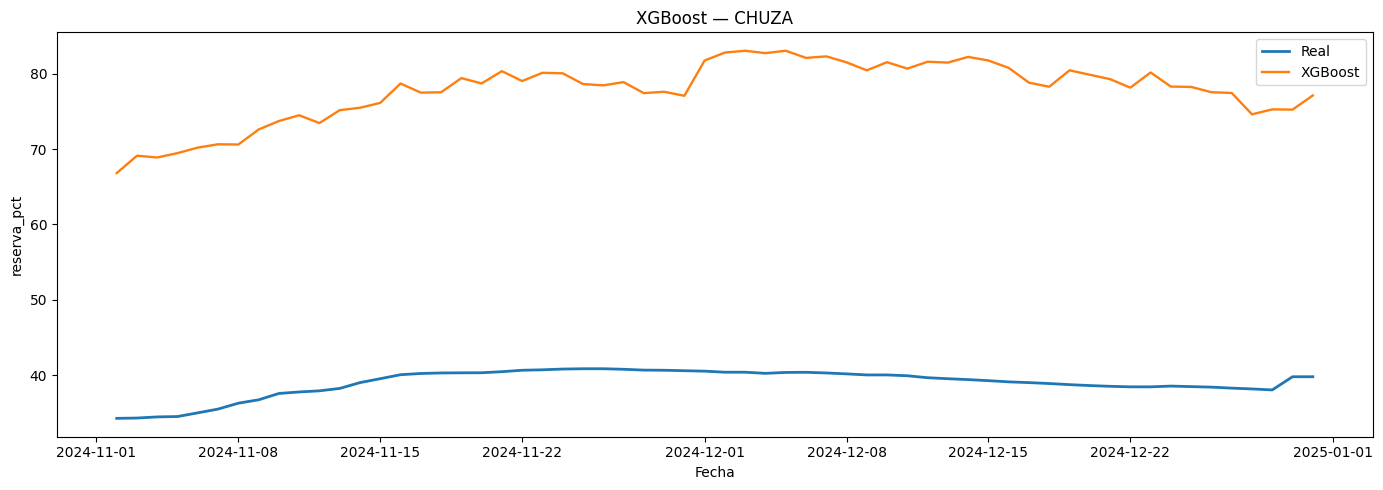

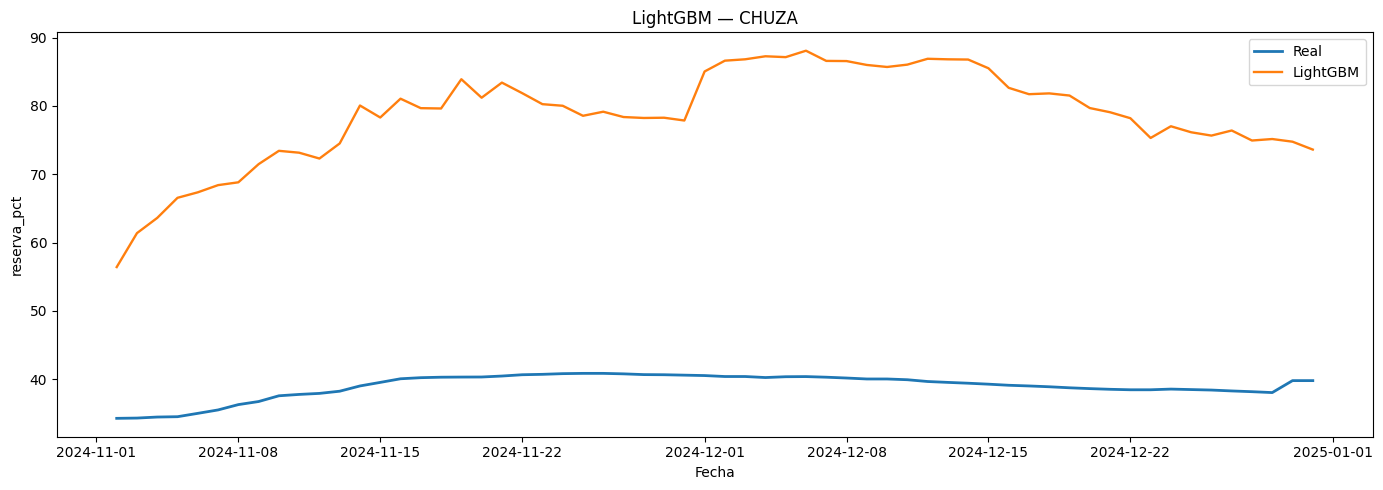

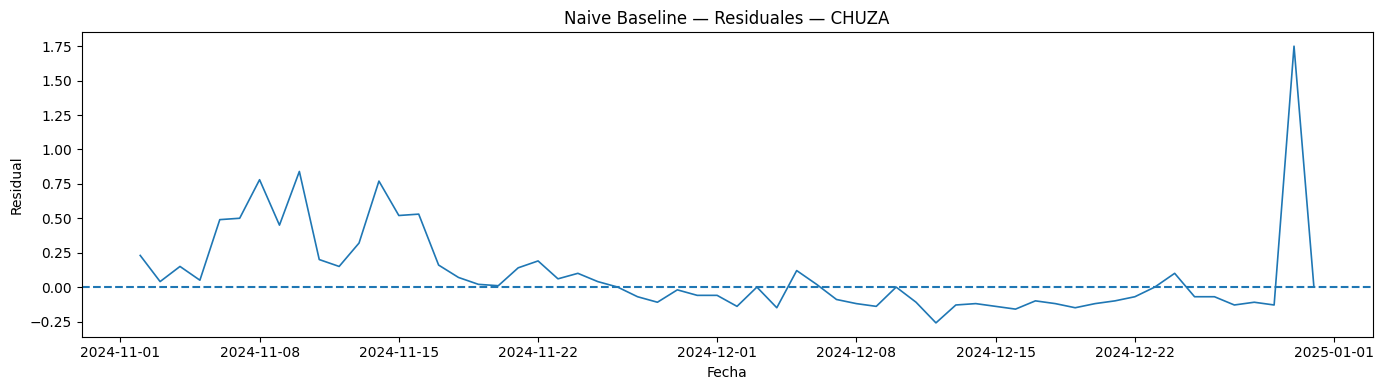

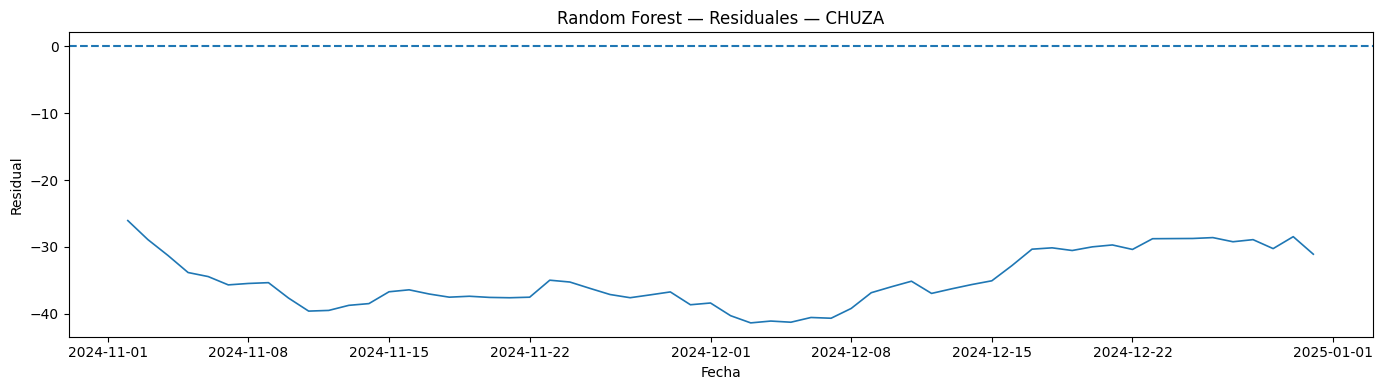

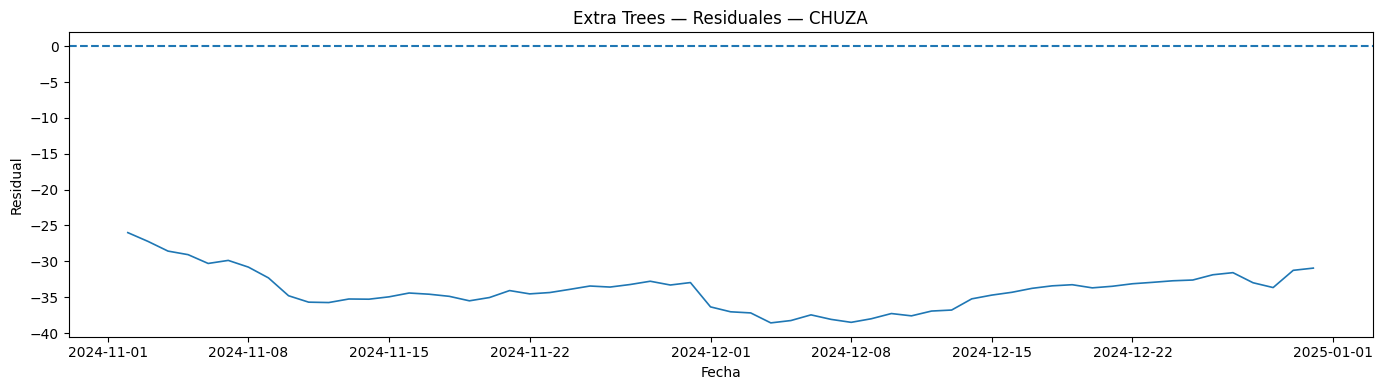

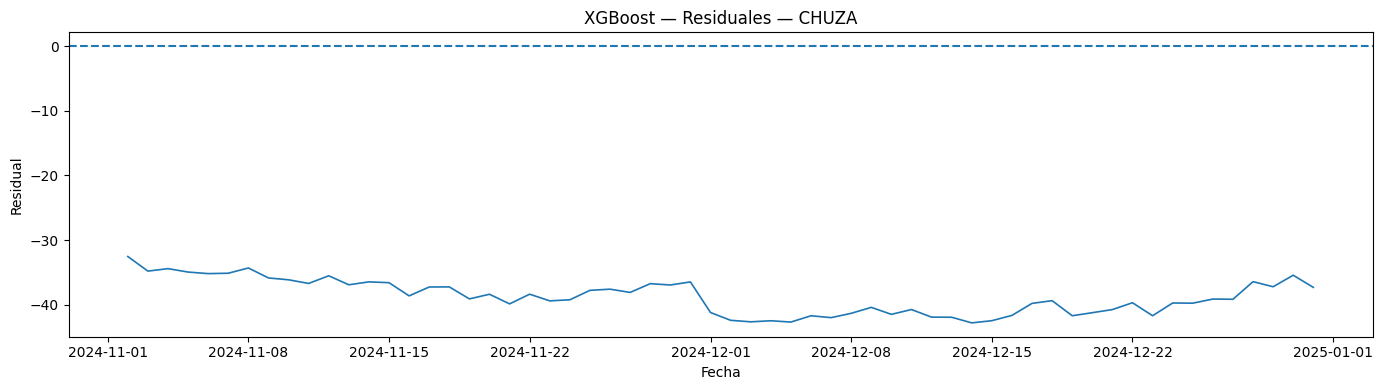

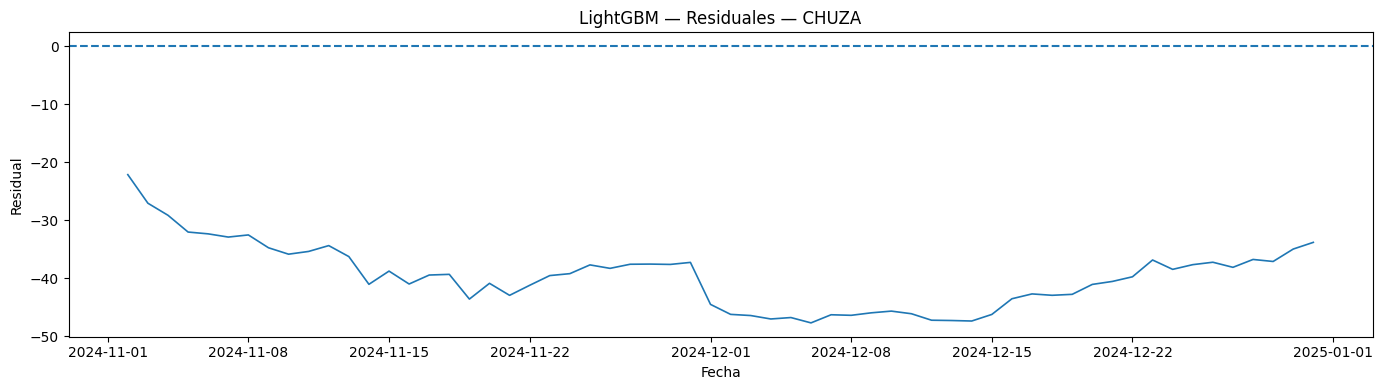

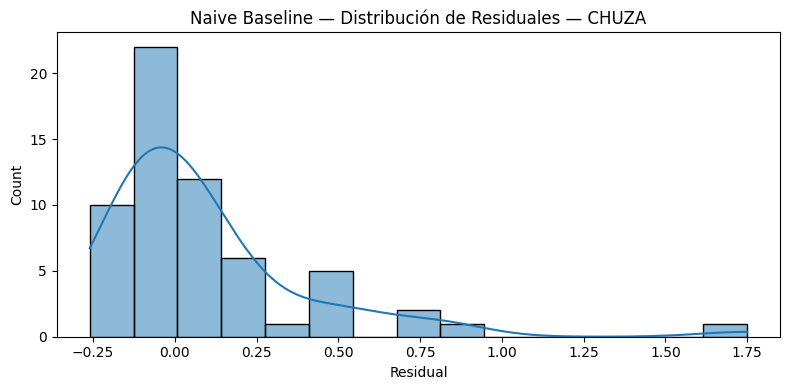

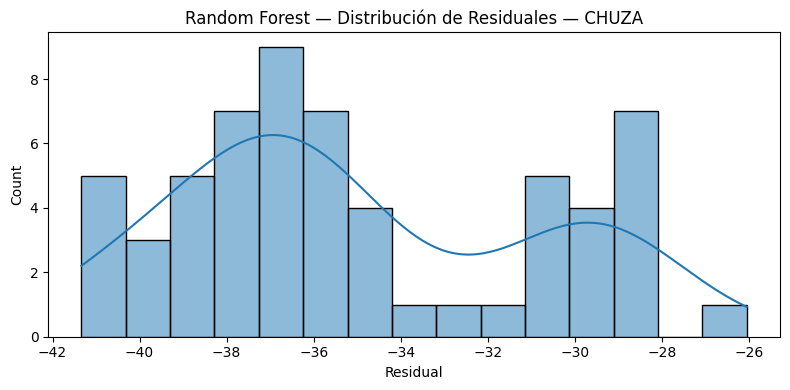

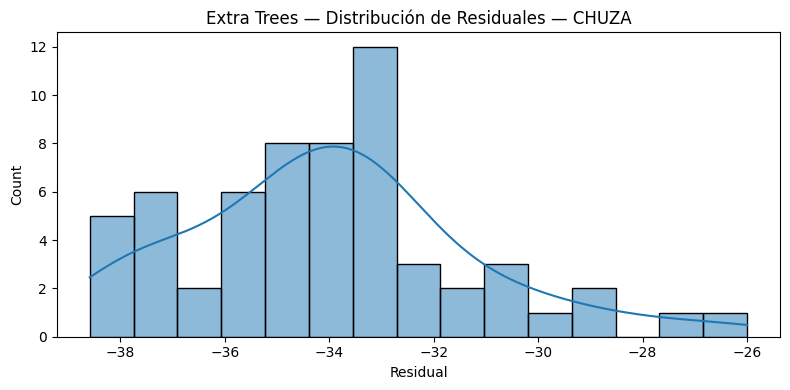

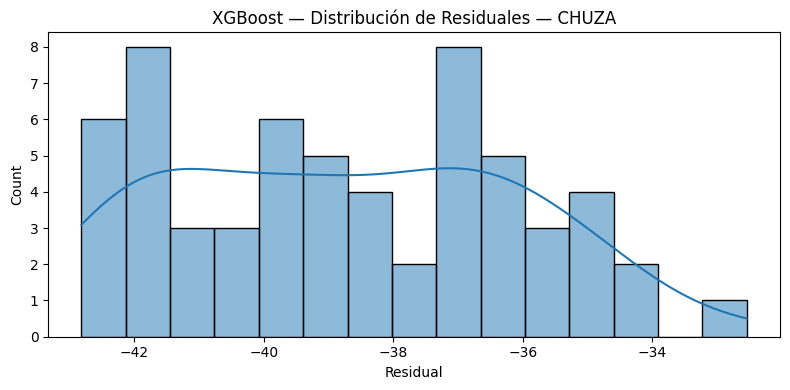

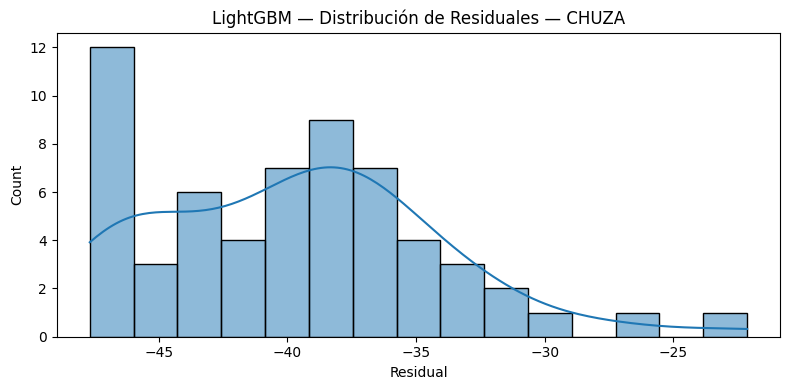

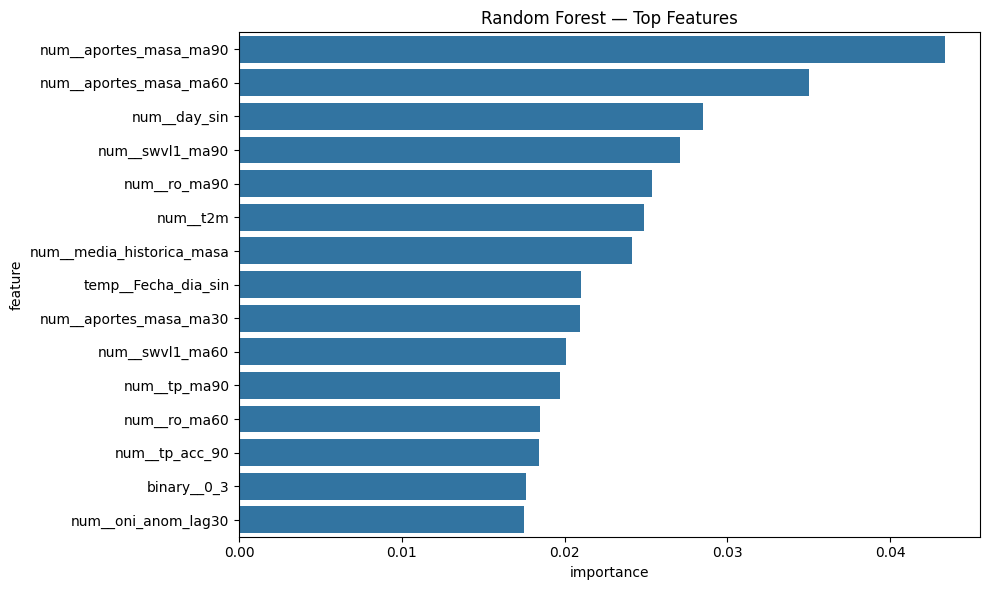

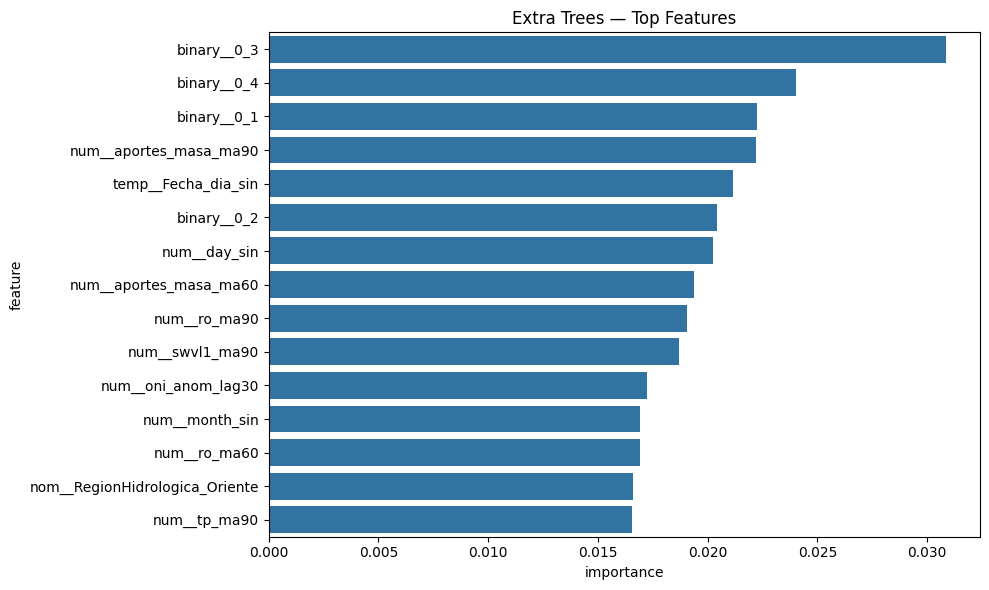

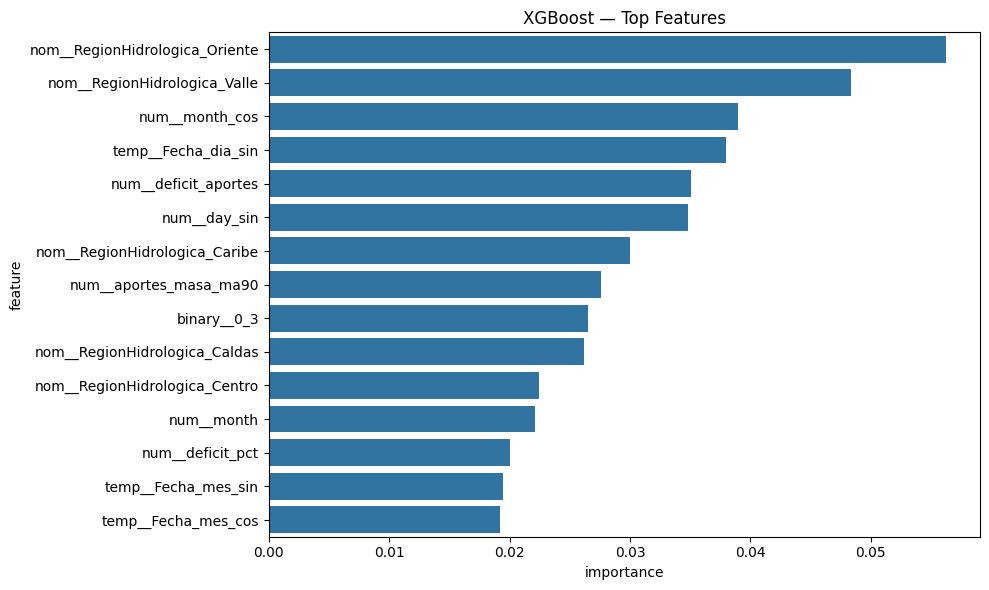

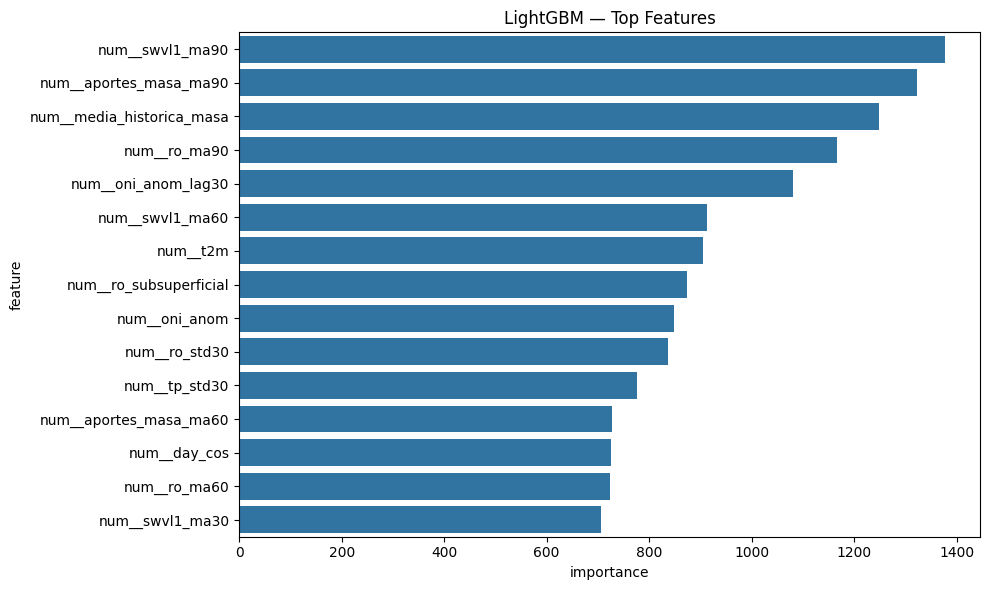

In [229]:
# =========================================================
# EVALUACIÓN AVANZADA — TODOS LOS MODELOS
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =========================================================
# PREDICCIONES
# =========================================================

rf_preds   = rf_model.predict(X_test)
et_preds   = extra_trees_model.predict(X_test)
xgb_preds  = xgb_model.predict(X_test)
lgbm_preds = lgbm_model.predict(X_test)          # ← NUEVO

# =========================================================
# BASELINE NAIVE — respeta embalse
# =========================================================

test_con_embalse = test_fe[["Fecha", "CodigoEmbalse"]].copy()
test_con_embalse.index = y_test.index
test_con_embalse["y_real"] = y_test

test_con_embalse["naive_preds"] = (
    test_con_embalse
    .groupby("CodigoEmbalse")["y_real"]
    .shift(1)
)

valid_mask = test_con_embalse["naive_preds"].notnull()

# =========================================================
# SERIES ALINEADAS
# =========================================================

y_eval     = test_con_embalse.loc[valid_mask, "y_real"]
naive_eval = test_con_embalse.loc[valid_mask, "naive_preds"]

rf_eval   = pd.Series(rf_preds,   index=y_test.index).loc[valid_mask]
et_eval   = pd.Series(et_preds,   index=y_test.index).loc[valid_mask]
xgb_eval  = pd.Series(xgb_preds,  index=y_test.index).loc[valid_mask]
lgbm_eval = pd.Series(lgbm_preds, index=y_test.index).loc[valid_mask]  # ← NUEVO

# =========================================================
# MASE
# =========================================================

naive_scale = (
    test_con_embalse
    .groupby("CodigoEmbalse")["y_real"]
    .apply(lambda s: np.mean(np.abs(s.diff().dropna())))
    .mean()
)

def mase(y_true, y_pred, scale):
    return mean_absolute_error(y_true, y_pred) / scale

# =========================================================
# MÉTRICAS EXTRA
# =========================================================

extra_metrics = {

    "Random Forest": {
        "MASE": mase(y_eval, rf_eval, naive_scale)
    },

    "Extra Trees": {
        "MASE": mase(y_eval, et_eval, naive_scale)
    },

    "XGBoost": {
        "MASE": mase(y_eval, xgb_eval, naive_scale)
    },

    "LightGBM": {                                              # ← NUEVO
        "MASE": mase(y_eval, lgbm_eval, naive_scale)
    },

    "Baseline Decision Tree": {
        "MASE": np.nan
    }
}

# =========================================================
# COPIA DE RESULTADOS BASE
# =========================================================

model_results_extended = model_results_df.copy()

# =========================================================
# AGREGAR MASE
# =========================================================

model_results_extended["MASE"] = (
    model_results_extended["experiment"]
    .apply(
        lambda x:
            extra_metrics[x]["MASE"]
            if x in extra_metrics
            else np.nan
    )
)

# =========================================================
# AGREGAR BASELINE NAIVE
# =========================================================

naive_row = pd.DataFrame([{

    "experiment": "Naive Baseline",

    "rmse": np.sqrt(
        mean_squared_error(y_eval, naive_eval)
    ),

    "mae": mean_absolute_error(y_eval, naive_eval),

    "r2": r2_score(y_eval, naive_eval),

    "MASE": mase(y_eval, naive_eval, naive_scale),
}])

# =========================================================
# CONCATENAR
# =========================================================

model_results_extended = pd.concat(
    [model_results_extended, naive_row],
    ignore_index=True
)

# =========================================================
# ORDENAR
# =========================================================

model_results_extended = model_results_extended.sort_values("rmse")

# =========================================================
# RESULTADOS
# =========================================================

print_section("RESULTADOS — MODELOS")
display(model_results_extended)

# =========================================================
# COMPARACIÓN DE MÉTRICAS
# =========================================================

metricas_plot = ["rmse", "mae", "MASE"]

for metric in metricas_plot:

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.barplot(
        data=model_results_extended,
        x="experiment",
        y=metric,
        ax=ax
    )

    ax.set_title(f"Comparación de {metric.upper()}")
    ax.set_xlabel("Modelo")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

# =========================================================
# SELECCIONAR 5 EMBALSES
# =========================================================

embalses_plot = (
    X_test_raw.loc[y_eval.index, "CodigoEmbalse"]
    .drop_duplicates()
    .head(5)
    .tolist()
)

print("Embalses seleccionados:")
print(embalses_plot)

# =========================================================
# RANGO TEMPORAL
# =========================================================

plot_start = "2024-10-01"
plot_end   = "2024-10-15"

# =========================================================
# FECHAS Y EMBALSES ALINEADOS
# =========================================================

test_dates    = X_test_raw.loc[y_eval.index, "Fecha"]
test_embalses = X_test_raw.loc[y_eval.index, "CodigoEmbalse"]

# =========================================================
# PREDICCIONES
# =========================================================

predictions_dict = {
    "Naive Baseline": naive_eval,
    "Random Forest":  rf_eval,
    "Extra Trees":    et_eval,
    "XGBoost":        xgb_eval,
    "LightGBM":       lgbm_eval,   # ← NUEVO
}

# =========================================================
# LOOP POR EMBALSE
# =========================================================

for embalse in embalses_plot:

    print("=" * 80)
    print(f"EMBALSE: {embalse}")
    print("=" * 80)

    embalse_mask = test_embalses == embalse
    plot_dates   = test_dates.loc[embalse_mask]
    plot_real    = y_eval.loc[embalse_mask]

    # =====================================================
    # REAL VS PREDICCIÓN
    # =====================================================

    for model_name, preds_all in predictions_dict.items():

        preds = preds_all.loc[plot_real.index]

        fig, ax = plt.subplots(figsize=(14, 5))

        ax.plot(plot_dates, plot_real, label="Real", linewidth=2)
        ax.plot(plot_dates, preds,     label=model_name, linewidth=1.7)

        ax.set_title(f"{model_name} — {embalse}")
        ax.set_xlabel("Fecha")
        ax.set_ylabel(TARGET)
        ax.legend()
        plt.tight_layout()
        plt.show()

    # =====================================================
    # RESIDUALES
    # =====================================================

    for model_name, preds_all in predictions_dict.items():

        preds     = preds_all.loc[plot_real.index]
        residuals = plot_real - preds

        fig, ax = plt.subplots(figsize=(14, 4))

        ax.plot(plot_dates, residuals, linewidth=1.2)
        ax.axhline(0, linestyle="--")

        ax.set_title(f"{model_name} — Residuales — {embalse}")
        ax.set_xlabel("Fecha")
        ax.set_ylabel("Residual")
        plt.tight_layout()
        plt.show()

    # =====================================================
    # DISTRIBUCIÓN DE ERRORES
    # =====================================================

    for model_name, preds_all in predictions_dict.items():

        preds     = preds_all.loc[plot_real.index]
        residuals = plot_real - preds

        fig, ax = plt.subplots(figsize=(8, 4))

        sns.histplot(residuals, bins=15, kde=True, ax=ax)

        ax.set_title(
            f"{model_name} — Distribución de Residuales — {embalse}"
        )
        ax.set_xlabel("Residual")
        plt.tight_layout()
        plt.show()

# =========================================================
# IMPORTANCIA DE VARIABLES
# =========================================================

models_dict = {
    "Random Forest":  rf_model,
    "Extra Trees":    extra_trees_model,
    "XGBoost":        xgb_model,
    "LightGBM":       lgbm_model,      # ← NUEVO
}

for model_name, pipeline in models_dict.items():

    regressor     = pipeline.named_steps["regressor"]
    feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()

    importances = pd.DataFrame({
        "feature":    feature_names,
        "importance": regressor.feature_importances_
    })

    importances = (
        importances
        .sort_values("importance", ascending=False)
        .head(15)
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    sns.barplot(
        data=importances,
        x="importance",
        y="feature",
        ax=ax
    )

    ax.set_title(f"{model_name} — Top Features")
    plt.tight_layout()
    plt.show()

Embalses en test: ['AGREGADO_BOGOTA', 'ALTOANCH', 'BETANIA', 'CALIMA1', 'MUNA', 'ESMERALD', 'GUAVIO', 'MIEL1', 'MIRAFLOR', 'URRA1', 'CHUZA', 'PLAYAS', 'PORCE2', 'PORCE3', 'PRADO', 'PUNCHINA', 'PENOL', 'SALVAJIN', 'SANLOREN', 'TRONERAS', 'RIOGRAN2']
Embalse seleccionado: AGREGADO_BOGOTA
Embalse seleccionado: AGREGADO_BOGOTA


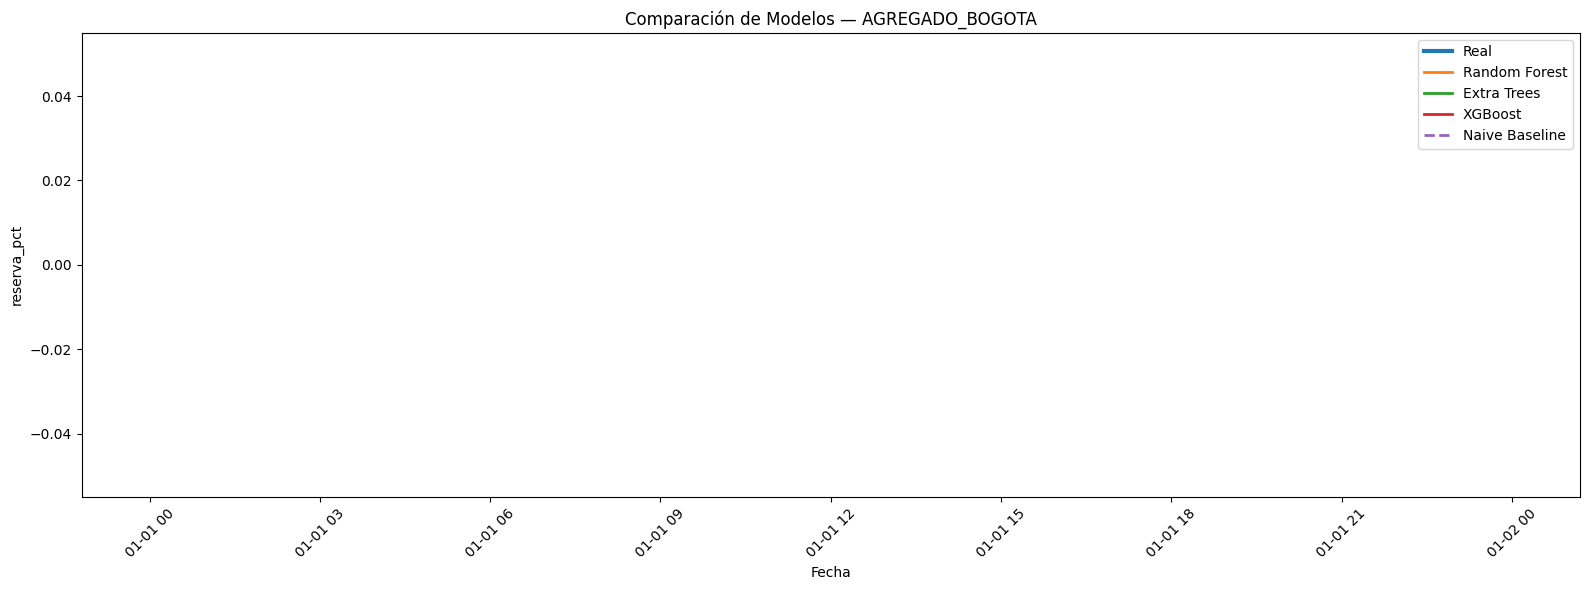

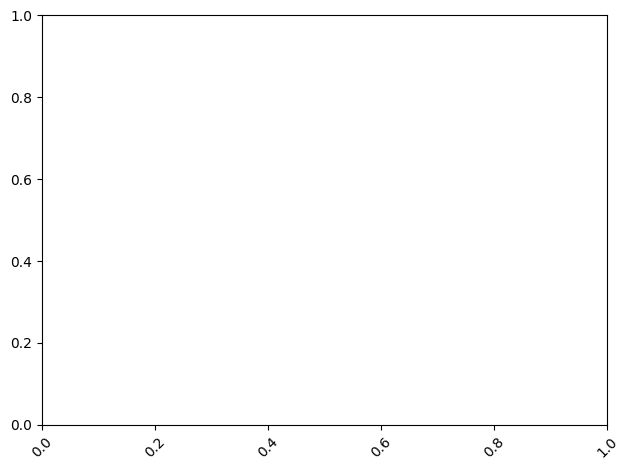

In [230]:
# =========================================================
# EMBALSES DISPONIBLES EN TEST
# =========================================================
embalses_plot = test_con_embalse["CodigoEmbalse"].unique().tolist()
print(f"Embalses en test: {embalses_plot}")

embalse_plot = embalses_plot[0]
print(f"Embalse seleccionado: {embalse_plot}")


# =========================================================
# EMBALSE A VISUALIZAR
# =========================================================
embalse_plot = embalses_plot[0]
print(f"Embalse seleccionado: {embalse_plot}")

# =========================================================
# RANGO TEMPORAL
# =========================================================
plot_start = "2024-10-01"
plot_end   = "2024-10-31"

# =========================================================
# FECHAS Y EMBALSES — ahora desde test_con_embalse
# =========================================================
test_dates    = test_con_embalse.loc[y_eval.index, "Fecha"]
test_embalses = test_con_embalse.loc[y_eval.index, "CodigoEmbalse"]

# =========================================================
# FILTRO
# =========================================================
plot_mask = (
    (test_dates >= plot_start)
    & (test_dates <= plot_end)
    & (test_embalses == embalse_plot)
)

plot_dates = test_dates.loc[plot_mask]
plot_real  = y_eval.loc[plot_mask]

# =========================================================
# PREDICCIONES — igual que antes
# =========================================================
plot_rf    = rf_eval.loc[plot_real.index]
plot_et    = et_eval.loc[plot_real.index]
plot_xgb   = xgb_eval.loc[plot_real.index]
plot_naive = naive_eval.loc[plot_real.index]

# =========================================================
# GRÁFICA — no cambia nada desde aquí
# =========================================================
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(plot_dates, plot_real,  label="Real",           linewidth=3)
ax.plot(plot_dates, plot_rf,    label="Random Forest",  linewidth=2)
ax.plot(plot_dates, plot_et,    label="Extra Trees",    linewidth=2)
ax.plot(plot_dates, plot_xgb,   label="XGBoost",        linewidth=2)
ax.plot(plot_dates, plot_naive, label="Naive Baseline", linewidth=2, linestyle="--")

ax.set_title(f"Comparación de Modelos — {embalse_plot}")
ax.set_xlabel("Fecha")
ax.set_ylabel(TARGET)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================================================
# ESTÉTICA
# =========================================================

ax.set_title(
    f"Comparación de Modelos — {embalse_plot}"
)

ax.set_xlabel("Fecha")

ax.set_ylabel(TARGET)

ax.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()